In [ ]:
using NPZ
using Glob
using Statistics
using Printf
using Dates

function average_data(L, T, dt, p, d, time_slice)

   # Root directory
    base_root = "/Users/dirac/Projects-Data/z3-data"

    # Input folder (fixed, existing)
    data_folder = joinpath(base_root, "z3-haar-data-26Dec2025")

    # Output folder (mean results)
    save_folder = joinpath(base_root, "z3-haar-data-26Dec2025-mean")
    mkpath(save_folder)

    # -----------------------
    # Correct file name pattern
    # Example:
    #   L8,T80.0,dt1.0,p0.0,dirQ,s6_hc.npy
    # -----------------------
    pattern = @sprintf("L%d,T%.1f,dt%.1f,p%.1f,dir%c,s*_hc.npy",
                       L, T, dt, p, d)

    # Find matching files inside the data folder
    shot_files = Glob.glob(pattern, data_folder)

    if isempty(shot_files)
        println("No matching files found in $data_folder")
        return
    end

    println("Found $(length(shot_files)) matching shots.")

    # Load every shot (each file is a vector)
    S_list = [npzread(f) for f in shot_files]

    # Convert list of vectors → matrix (shots × time)
    S_mat = reduce(vcat, [S' for S in S_list])

    # Compute mean and variance across shots
    S_mean = [mean(S_mat[:, i]) for i in 1:time_slice]
    S_var  = [var(S_mat[:, i])  for i in 1:time_slice]

    # Save results
    mean_file = @sprintf("Emean_L%d,T%.1f,dt%.1f,p%.1f_hc.npy", L, T, dt, p)
    var_file  = @sprintf("Evar_L%d,T%.1f,dt%.1f,p%.1f_hc.npy",  L, T, dt, p)

    npzwrite(joinpath(save_folder, mean_file), S_mean)
    npzwrite(joinpath(save_folder, var_file),  S_var)

    println("Saved results to $save_folder")
end

average_data (generic function with 1 method)

In [13]:
file = npzread("/Users/uditvarma/Project_Data/z3-haar_2025-12-08_mean/Emean_L8,T80.0,dt1.0,p0.0_hc.npy")

80-element Vector{Float64}:
 -1.9984014443253304e-17
  1.262292432127888
  2.407181934950096
  3.2236410820985895
  3.642412329274977
  3.8065093335918836
  3.86620404124176
  3.884763052507316
  3.891973391725892
  3.892946487813995
  ⋮
  3.89536136478127
  3.8954078350385375
  3.894357654065216
  3.894193894130835
  3.8946663210726724
  3.894337053850629
  3.894829721196814
  3.8949522118984867
  3.8946461484406023

In [14]:
using Plots

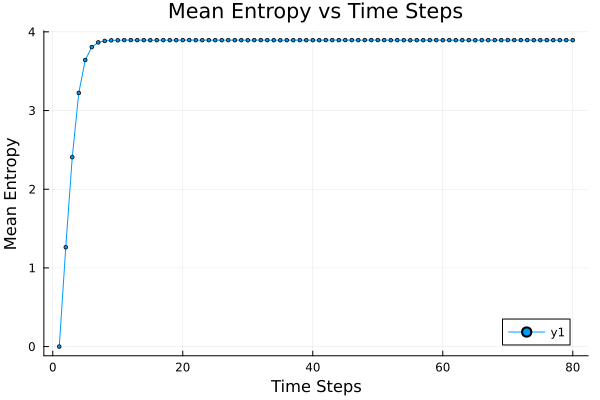

In [17]:
plot(file, xlabel="Time Steps", ylabel="Mean Entropy", title="Mean Entropy vs Time Steps", marker=:circle, markersize=2)

In [4]:
0.0:1.0:21

0.0:1.0:21.0

In [7]:
# --------------------------
# Example single run / sweep
# --------------------------
for L in [6, 8, 10]
    T = 10.0 * L
    for p in range(0.0, 1.0, length=21)
        for d in ["Q"]
            dt = 1.0
            average_data(L, T, dt, p, d, 10 * L)
        end
    end
end

Found 5000 matching shots.
Saved results to /Users/dirac/Projects-Data/z3-data/z3-haar-data-26Dec2025-mean
Found 5000 matching shots.
Saved results to /Users/dirac/Projects-Data/z3-data/z3-haar-data-26Dec2025-mean
Found 5000 matching shots.
Saved results to /Users/dirac/Projects-Data/z3-data/z3-haar-data-26Dec2025-mean
Found 5000 matching shots.
Saved results to /Users/dirac/Projects-Data/z3-data/z3-haar-data-26Dec2025-mean
Found 5000 matching shots.
Saved results to /Users/dirac/Projects-Data/z3-data/z3-haar-data-26Dec2025-mean
Found 5000 matching shots.
Saved results to /Users/dirac/Projects-Data/z3-data/z3-haar-data-26Dec2025-mean
Found 5000 matching shots.
Saved results to /Users/dirac/Projects-Data/z3-data/z3-haar-data-26Dec2025-mean
Found 5000 matching shots.
Saved results to /Users/dirac/Projects-Data/z3-data/z3-haar-data-26Dec2025-mean
Found 5000 matching shots.
Saved results to /Users/dirac/Projects-Data/z3-data/z3-haar-data-26Dec2025-mean
Found 5000 matching shots.
Saved resu

In [8]:
using Glob
using Printf

# Mean data root
mean_root = "/Users/dirac/Projects-Data/z3-data/z3-haar-data-26Dec2025-mean"

# Find all mean + variance files
files = Glob.glob("E*_L*,T*,dt*,p*_hc.npy", mean_root)

if isempty(files)
    println("No mean/variance files found.")
    return
end

for f in files
    fname = basename(f)

    # Extract L from filename
    # Example: Emean_L6,T60.0,dt1.0,p0.0_hc.npy
    m = match(r"L(\d+),", fname)
    if m === nothing
        @warn "Could not parse L from $fname"
        continue
    end

    L = m.captures[1]

    # Create folder for this L
    L_folder = joinpath(mean_root, "L$L")
    mkpath(L_folder)

    # Move file
    mv(f, joinpath(L_folder, fname); force=true)
end

println("Files organized by L successfully.")

Files organized by L successfully.


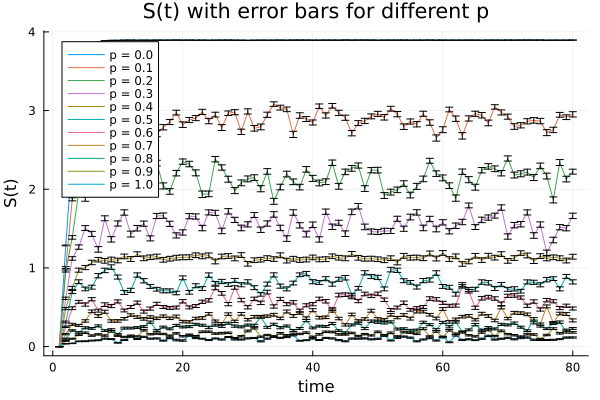

In [ ]:
using NPZ
using Glob
using Printf
using Plots       # uses GR backend by default

function plot_all_p(L, T, dt)

    base = "/Users/uditvarma/Project_Data"
    date_str = Dates.format(Dates.today(), "yyyy-mm-dd")
    folder = joinpath(base, "z3-haar_" * date_str * "_mean")

    # Search for all mean files
    pattern = @sprintf("Emean_L%d,T%.1f,dt%.1f,p*_hc.npy", L, T, dt)
    mean_files = Glob.glob(pattern, folder)

    if isempty(mean_files)
        println("No files found in $folder")
        return
    end

    # Arrays for sorting
    p_values = Float64[]
    mean_list = Vector{Vector{Float64}}()
    var_list  = Vector{Vector{Float64}}()

    # Load all mean + var files
    for mf in mean_files
        # Extract p from "p0.3_hc.npy"
        fname = basename(mf)
        p_str = split(split(fname, "p")[2], "_")[1]
        p = parse(Float64, p_str)

        push!(p_values, p)
        push!(mean_list, npzread(mf))

        var_file = replace(mf, "Emean" => "Evar")
        push!(var_list, npzread(var_file))
    end

    # Sort everything by p
    perm = sortperm(p_values)
    p_values = p_values[perm]
    mean_list = mean_list[perm]
    var_list = var_list[perm]

    # Time axis
    t = 1:length(mean_list[1])

    # ------------------------------------------
    # Plot all curves with error bars
    # ------------------------------------------
    plt = plot(title="S(t) with error bars for different p",
               xlabel="time", ylabel="S")

    for i in 1:length(p_values)
        errors = sqrt.(var_list[i])
        plot!(t, mean_list[i], yerr=errors/sqrt(1000),  # assuming 100 shots
              label = @sprintf("p = %.1f", p_values[i]))
    end

    display(plt)
end


# CALL THE FUNCTION
plot_all_p(8, 80.0, 1.0)


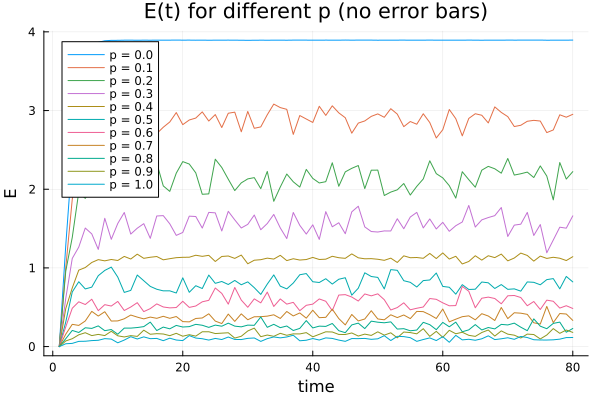

In [26]:
using NPZ
using Glob
using Printf
using Dates
using Plots

function plot_all_p_noerr(L, T, dt)

    base = "/Users/uditvarma/Project_Data"
    date_str = Dates.format(Dates.today(), "yyyy-mm-dd")
    folder = joinpath(base, "z3-haar_" * date_str * "_mean")

    # Locate all mean files
    pattern = @sprintf("Emean_L%d,T%.1f,dt%.1f,p*_hc.npy", L, T, dt)
    mean_files = Glob.glob(pattern, folder)

    if isempty(mean_files)
        println("No files found in $folder")
        return
    end

    p_values = Float64[]
    mean_list = Vector{Vector{Float64}}()

    # Read mean files
    for mf in mean_files
        fname = basename(mf)
        p_str = split(split(fname, "p")[2], "_")[1]
        p = parse(Float64, p_str)

        push!(p_values, p)
        push!(mean_list, npzread(mf))
    end

    # Sort by p
    perm = sortperm(p_values)
    p_values = p_values[perm]
    mean_list = mean_list[perm]

    # Time axis
    t = 1:length(mean_list[1])

    # Plot all curves (no error bars)
    plt = plot(title="E(t) for different p (no error bars)",
               xlabel="time", ylabel="E")

    for i in 1:length(p_values)
        plot!(t, mean_list[i], label=@sprintf("p = %.1f", p_values[i]))
    end

    display(plt)
end

# Run it
plot_all_p_noerr(8, 80.0, 1.0)


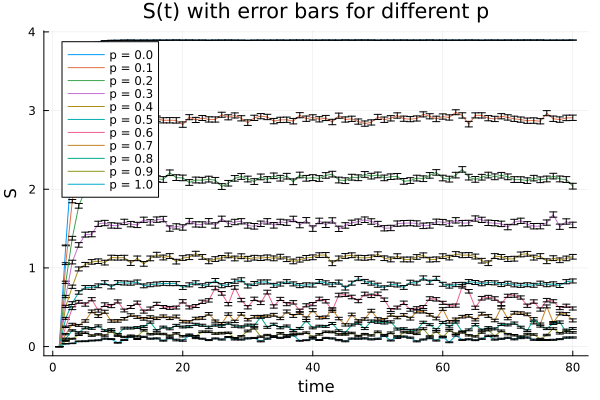

In [32]:
using NPZ
using Glob
using Printf
using Plots       # uses GR backend by default

function plot_all_p(L, T, dt)

    base = "/Users/uditvarma/Project_Data"
    date_str = Dates.format(Dates.today(), "yyyy-mm-dd")
    folder = joinpath(base, "z3-haar_" * date_str * "_mean")

    # Search for all mean files
    pattern = @sprintf("Emean_L%d,T%.1f,dt%.1f,p*_hc.npy", L, T, dt)
    mean_files = Glob.glob(pattern, folder)

    if isempty(mean_files)
        println("No files found in $folder")
        return
    end

    # Arrays for sorting
    p_values = Float64[]
    mean_list = Vector{Vector{Float64}}()
    var_list  = Vector{Vector{Float64}}()

    # Load all mean + var files
    for mf in mean_files
        # Extract p from "p0.3_hc.npy"
        fname = basename(mf)
        p_str = split(split(fname, "p")[2], "_")[1]
        p = parse(Float64, p_str)

        push!(p_values, p)
        push!(mean_list, npzread(mf))

        var_file = replace(mf, "Emean" => "Evar")
        push!(var_list, npzread(var_file))
    end

    # Sort everything by p
    perm = sortperm(p_values)
    p_values = p_values[perm]
    mean_list = mean_list[perm]
    var_list = var_list[perm]

    # Time axis
    t = 1:length(mean_list[1])

    # ------------------------------------------
    # Plot all curves with error bars
    # ------------------------------------------
    plt = plot(title="S(t) with error bars for different p",
               xlabel="time", ylabel="S")

    for i in 1:length(p_values)
        errors = sqrt.(var_list[i])
        plot!(t, mean_list[i], yerr=errors/sqrt(1000),  # assuming 100 shots
              label = @sprintf("p = %.1f", p_values[i]))
    end

    display(plt)
end


# CALL THE FUNCTION
plot_all_p(8, 80.0, 1.0)

plot_selected_p (generic function with 1 method)

In [36]:
using NPZ
using Glob
using Printf
using Plots

function plot_selected_p(L, T, dt, p_list_to_plot)

    base = "/Users/uditvarma/Project_Data"
    date_str = Dates.format(Dates.today(), "yyyy-mm-dd")
    folder = joinpath(base, "z3-haar_" * date_str * "_mean")

    # Search for all mean files
    pattern = @sprintf("Emean_L%d,T%.1f,dt%.1f,p*_hc.npy", L, T, dt)
    all_mean_files = Glob.glob(pattern, folder)

    if isempty(all_mean_files)
        println("No files found in $folder")
        return
    end

    # Storage
    selected_p = Float64[]
    mean_list = Vector{Vector{Float64}}()
    var_list  = Vector{Vector{Float64}}()

    for mf in all_mean_files
        fname = basename(mf)

        # Extract p value
        p_str = split(split(fname, "p")[2], "_")[1]
        p = parse(Float64, p_str)

        # Skip p values NOT requested
        if !(p in p_list_to_plot)
            continue
        end

        push!(selected_p, p)
        push!(mean_list, npzread(mf))

        var_file = replace(mf, "Emean" => "Evar")
        push!(var_list, npzread(var_file))
    end

    if isempty(selected_p)
        println("No requested p values found.")
        return
    end

    # Sort by p
    perm = sortperm(selected_p)
    selected_p = selected_p[perm]
    mean_list  = mean_list[perm]
    var_list   = var_list[perm]

    # Time axis
    t = 1:length(mean_list[1])

    # Plot
    plt = plot(title="S(t) vs t",
               xlabel="Time", ylabel="S")

    for i in 1:length(selected_p)
        errors = sqrt.(var_list[i]) ./ sqrt(1000)
        plot!(t, mean_list[i], yerr=errors,
              label=@sprintf("p = %.2f", selected_p[i]))
    end

    display(plt)
end

plot_selected_p (generic function with 1 method)

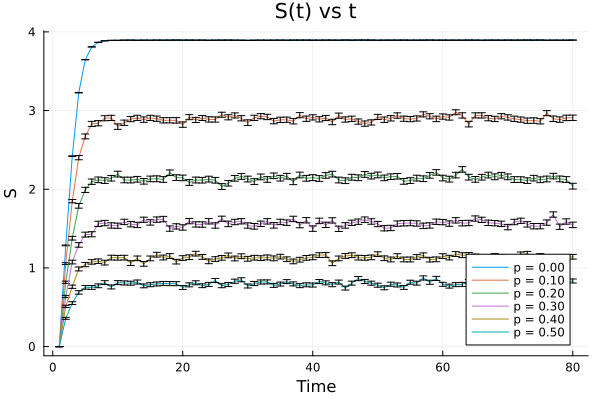

In [37]:
plot_selected_p(8, 80.0, 1.0, [0.0, 0.1, 0.2, 0.3, 0.4, 0.5])

In [2]:
using DataFrames
using CSV

# Base directory
base_dir = "/Users/dirac/Projects-Data/z3-data/z3-haar-data-26Dec2025"

# Regex:
# Example filename:
# L6,T60.0,dt1.0,p0.0,dirQ,s8_hc.npy
pattern = r"L(\d+),.*?,p([0-9.]+),.*?,s(\d+)_"

rows = DataFrame(
    L = Int[],
    p = Float64[],
    shot = Int[]
)

for (root, _, files) in walkdir(base_dir)
    for f in files
        m = match(pattern, f)
        if m !== nothing
            push!(rows, (
                L = parse(Int, m.captures[1]),
                p = parse(Float64, m.captures[2]),
                shot = parse(Int, m.captures[3])
            ))
        end
    end
end

# Group by (L, p) and count unique shots
ledger = combine(
    groupby(rows, [:L, :p]),
    :shot => (s -> length(unique(s))) => :nshots
)

# Sort for readability
sort!(ledger, [:L, :p])

println("\nLedger (number of shots inferred from sXX indices):")
println(ledger)


Ledger (number of shots inferred from sXX indices):
63×3 DataFrame
 Row │ L      p        nshots 
     │ Int64  Float64  Int64  
─────┼────────────────────────
   1 │     6     0.0     5000
   2 │     6     0.05    5000
   3 │     6     0.1     5000
   4 │     6     0.15    5000
   5 │     6     0.2     5000
   6 │     6     0.25    5000
   7 │     6     0.3     5000
   8 │     6     0.35    5000
   9 │     6     0.4     5000
  10 │     6     0.45    5000
  11 │     6     0.5     5000
  12 │     6     0.55    5000
  13 │     6     0.6     5000
  14 │     6     0.65    5000
  15 │     6     0.7     5000
  16 │     6     0.75    5000
  17 │     6     0.8     5000
  18 │     6     0.85    5000
  19 │     6     0.9     5000
  20 │     6     0.95    5000
  21 │     6     1.0     5000
  22 │     8     0.0     5000
  23 │     8     0.05    5000
  24 │     8     0.1     5000
  25 │     8     0.15    4980
  26 │     8     0.2     5000
  27 │     8     0.25    5000
  28 │     8     0.3     5000

In [1]:
using DataFrames
using CSV

# Base directory
base_dir = "/Users/dirac/Projects-Data/z3-data/z3-shannon-data-26Dec2025"

# Regex:
# Example filename:
# L6,T60.0,dt1.0,p0.0,dirQ,s8_hc.npy
pattern = r"L(\d+),.*?,p([0-9.]+),.*?,s(\d+)_"

rows = DataFrame(
    L = Int[],
    p = Float64[],
    shot = Int[]
)

for (root, _, files) in walkdir(base_dir)
    for f in files
        m = match(pattern, f)
        if m !== nothing
            push!(rows, (
                L = parse(Int, m.captures[1]),
                p = parse(Float64, m.captures[2]),
                shot = parse(Int, m.captures[3])
            ))
        end
    end
end

# Group by (L, p) and count unique shots
ledger = combine(
    groupby(rows, [:L, :p]),
    :shot => (s -> length(unique(s))) => :nshots
)

# Sort for readability
sort!(ledger, [:L, :p])

println("\nLedger (number of shots inferred from sXX indices):")
println(ledger)


Ledger (number of shots inferred from sXX indices):
63×3 DataFrame
 Row │ L      p        nshots 
     │ Int64  Float64  Int64  
─────┼────────────────────────
   1 │     6     0.0     5000
   2 │     6     0.05    5000
   3 │     6     0.1     5000
   4 │     6     0.15    5000
   5 │     6     0.2     5000
   6 │     6     0.25    5000
   7 │     6     0.3     5000
   8 │     6     0.35    5000
   9 │     6     0.4     5000
  10 │     6     0.45    5000
  11 │     6     0.5     5000
  12 │     6     0.55    5000
  13 │     6     0.6     5000
  14 │     6     0.65    5000
  15 │     6     0.7     5000
  16 │     6     0.75    5000
  17 │     6     0.8     4990
  18 │     6     0.85    5000
  19 │     6     0.9     5000
  20 │     6     0.95    5000
  21 │     6     1.0     5000
  22 │     8     0.0     5000
  23 │     8     0.05    5000
  24 │     8     0.1     5000
  25 │     8     0.15    5000
  26 │     8     0.2     5000
  27 │     8     0.25    5000
  28 │     8     0.3     5000

In [11]:
using NPZ
using Glob
using Printf
using Plots

function plot_by_L_svg(L_values, dt)

    base = "/Users/dirac/Projects-Data/z3-data"
    mean_root = joinpath(base, "z3-haar-data-26Dec2025-mean")

    for L in L_values
        T = 10.0 * L
        folder = joinpath(mean_root, "L$L")

        pattern = @sprintf("Emean_L%d,T%.1f,dt%.1f,p*_hc.npy", L, T, dt)
        mean_files = Glob.glob(pattern, folder)

        if isempty(mean_files)
            @warn "No files found for L=$L"
            continue
        end

        p_values  = Float64[]
        mean_list = Vector{Vector{Float64}}()
        var_list  = Vector{Vector{Float64}}()

        for mf in mean_files
            fname = basename(mf)
            p_str = split(split(fname, "p")[2], "_")[1]
            p = parse(Float64, p_str)

            push!(p_values, p)
            push!(mean_list, npzread(mf))

            var_file = replace(mf, "Emean" => "Evar")
            push!(var_list, npzread(var_file))
        end

        # Sort by p
        perm = sortperm(p_values)
        p_values  = p_values[perm]
        mean_list = mean_list[perm]
        var_list  = var_list[perm]

        t = 1:length(mean_list[1])

        plt = plot(
            title  = @sprintf("S(t) for L = %d", L),
            xlabel = "time",
            ylabel = "S",
            legend = :right
        )

        for i in eachindex(p_values)
            errors = sqrt.(var_list[i])
            plot!(
                t,
                mean_list[i],
                yerr = errors ./ sqrt(5000),
                label = @sprintf("p = %.2f", p_values[i])
            )
        end

        # -----------------------
        # SAVE AS SVG
        # -----------------------
        out_svg = joinpath(folder, @sprintf("S_vs_t_L%d.svg", L))
        savefig(plt, out_svg)

        println("Saved → $out_svg")
    end
end

# ----------------------
# CALL
# ----------------------
plot_by_L_svg([6, 8, 10], 1.0)


Saved → /Users/dirac/Projects-Data/z3-data/z3-haar-data-26Dec2025-mean/L6/S_vs_t_L6.svg
Saved → /Users/dirac/Projects-Data/z3-data/z3-haar-data-26Dec2025-mean/L8/S_vs_t_L8.svg
Saved → /Users/dirac/Projects-Data/z3-data/z3-haar-data-26Dec2025-mean/L10/S_vs_t_L10.svg


In [40]:
using NPZ
using Glob
using Printf
using Plots

function plot_final_variance_vs_p_svg(L_values, dt)

    base = "/Users/dirac/Projects-Data/z3-data"
    mean_root = joinpath(base, "z3-haar-data-26Dec2025-mean")

    plt = plot(
        xlabel = "p",
        ylabel = "δS(t)",
        title  = "Steady-state variance vs p",
        legend = :topright,
        marker = :circle
    )

    for L in L_values
        T = 10.0 * L
        folder = joinpath(mean_root, "L$L")

        pattern = @sprintf("Evar_L%d,T%.1f,dt%.1f,p*_hc.npy", L, T, dt)
        var_files = Glob.glob(pattern, folder)

        if isempty(var_files)
            @warn "No variance files found for L=$L"
            continue
        end

        p_values = Float64[]
        final_vars = Float64[]

        for vf in var_files
            fname = basename(vf)

            # extract p from filename
            p_str = split(split(fname, "p")[2], "_")[1]
            p = parse(Float64, p_str)

            var_data = npzread(vf)
            final_var = var_data[end]   # FINAL TIME VALUE

            push!(p_values, p)
            push!(final_vars, final_var)
        end

        # sort by p
        perm = sortperm(p_values)
        p_values   = p_values[perm]
        final_vars = final_vars[perm]

        plot!(
            p_values,
            final_vars,
            label = @sprintf("L = %d", L)
        )
    end

    # -----------------------
    # SAVE AS SVG
    # -----------------------
    out_svg = joinpath(mean_root, "final_variance_vs_p.svg")
    savefig(plt, out_svg)

    println("Saved → $out_svg")
end

# ----------------------
# CALL
# ----------------------
plot_final_variance_vs_p_svg([6, 8, 10], 1.0)


Saved → /Users/dirac/Projects-Data/z3-data/z3-haar-data-26Dec2025-mean/final_variance_vs_p.svg


In [12]:
npzread("/Users/dirac/Projects-Data/z3-data/z3-haar-data-26Dec2025-mean/L8/Emean_L8,T80.0,dt1.0,p1.0_hc.npy")

80-element Vector{Float64}:
 3.6415315207705074e-17
 0.040900373511640734
 0.05510347731805159
 0.0734323807387099
 0.084224322229018
 0.05406211386132771
 0.09283863172387151
 0.08826277903976977
 0.08548485956382391
 0.088564541275996
 0.07828718828234373
 0.0949872042023508
 0.09294522387652444
 ⋮
 0.08631777343676288
 0.09954668633263328
 0.09065140425807809
 0.10274122726200176
 0.10282802018011926
 0.09662265428260665
 0.0958155033064394
 0.10124594595652163
 0.09647232569666762
 0.09183558382496805
 0.09457815606317478
 0.10692030858965909

### Shannon entropy data

In [28]:
using NPZ
using Glob
using Statistics
using Printf
using Dates

function average_data(L, T, dt, p, d, time_slice)

   # Root directory
    base_root = "/Users/dirac/Projects-Data/z3-data"

    # Input folder (fixed, existing)
    data_folder = joinpath(base_root, "z3-shannon-data-26Dec2025")

    # Output folder (mean results)
    save_folder = joinpath(base_root, "z3-shannon-data-26Dec2025-mean")
    mkpath(save_folder)

    # -----------------------
    # Correct file name pattern
    # Example:
    #   L8,T80.0,dt1.0,p0.0,dirQ,s6_hc.npy
    # -----------------------
    pattern = @sprintf("L%d,T%.1f,dt%.1f,p%.1f,dir%c,s*_se.npy",
                       L, T, dt, p, d)

    # Find matching files inside the data folder
    shot_files = Glob.glob(pattern, data_folder)

    if isempty(shot_files)
        println("No matching files found in $data_folder")
        return
    end

    println("Found $(length(shot_files)) matching shots.")

    # Load every shot (each file is a vector)
    S_list = [npzread(f) for f in shot_files]

    # Convert list of vectors → matrix (shots × time)
    S_mat = reduce(vcat, [S' for S in S_list])

    # Compute mean and variance across shots
    S_mean = [mean(S_mat[:, i]) for i in 1:time_slice]
    S_var  = [var(S_mat[:, i])  for i in 1:time_slice]

    # Save results
    mean_file = @sprintf("Emean_L%d,T%.1f,dt%.1f,p%.1f_se.npy", L, T, dt, p)
    var_file  = @sprintf("Evar_L%d,T%.1f,dt%.1f,p%.1f_se.npy",  L, T, dt, p)

    npzwrite(joinpath(save_folder, mean_file), S_mean)
    npzwrite(joinpath(save_folder, var_file),  S_var)

    println("Saved results to $save_folder")
end

average_data (generic function with 1 method)

In [29]:
# --------------------------
# Example single run / sweep
# --------------------------
for L in [6, 8, 10]
    T = 10.0 * L
    for p in [
    0.0, 0.05, 0.1, 0.15, 0.2,
    0.25, 0.3, 0.35, 0.4, 0.45,
    0.5, 0.55, 0.6, 0.65, 0.7,
    0.75, 0.8, 0.85, 0.9, 0.95, 1.0
]
        for d in ["Q"]
            dt = 1.0
            average_data(L, T, dt, p, d, 10 * L)
        end
    end
end

Found 5000 matching shots.
Saved results to /Users/dirac/Projects-Data/z3-data/z3-shannon-data-26Dec2025-mean
Found 5000 matching shots.
Saved results to /Users/dirac/Projects-Data/z3-data/z3-shannon-data-26Dec2025-mean
Found 5000 matching shots.
Saved results to /Users/dirac/Projects-Data/z3-data/z3-shannon-data-26Dec2025-mean
Found 5000 matching shots.
Saved results to /Users/dirac/Projects-Data/z3-data/z3-shannon-data-26Dec2025-mean
Found 5000 matching shots.
Saved results to /Users/dirac/Projects-Data/z3-data/z3-shannon-data-26Dec2025-mean
Found 5000 matching shots.
Saved results to /Users/dirac/Projects-Data/z3-data/z3-shannon-data-26Dec2025-mean
Found 5000 matching shots.
Saved results to /Users/dirac/Projects-Data/z3-data/z3-shannon-data-26Dec2025-mean
Found 5000 matching shots.
Saved results to /Users/dirac/Projects-Data/z3-data/z3-shannon-data-26Dec2025-mean
Found 5000 matching shots.
Saved results to /Users/dirac/Projects-Data/z3-data/z3-shannon-data-26Dec2025-mean
Found 5000

In [31]:
using Glob
using Printf

# Mean data root
mean_root = "/Users/dirac/Projects-Data/z3-data/z3-shannon-data-26Dec2025-mean"

# Find all mean + variance files
files = Glob.glob("E*_L*,T*,dt*,p*_se.npy", mean_root)

if isempty(files)
    println("No mean/variance files found.")
    return
end

for f in files
    fname = basename(f)

    # Extract L from filename
    # Example: Emean_L6,T60.0,dt1.0,p0.0_hc.npy
    m = match(r"L(\d+),", fname)
    if m === nothing
        @warn "Could not parse L from $fname"
        continue
    end

    L = m.captures[1]

    # Create folder for this L
    L_folder = joinpath(mean_root, "L$L")
    mkpath(L_folder)

    # Move file
    mv(f, joinpath(L_folder, fname); force=true)
end

println("Files organized by L successfully.")

Files organized by L successfully.


In [42]:
using NPZ
using Glob
using Printf
using Plots

function plot_by_L_svg(L_values, dt)

    base = "/Users/dirac/Projects-Data/z3-data"
    mean_root = joinpath(base, "z3-shannon-data-26Dec2025-mean")

    for L in L_values
        T = 10.0 * L
        folder = joinpath(mean_root, "L$L")

        pattern = @sprintf("Emean_L%d,T%.1f,dt%.1f,p*_se.npy", L, T, dt)
        mean_files = Glob.glob(pattern, folder)

        if isempty(mean_files)
            @warn "No files found for L=$L"
            continue
        end

        p_values  = Float64[]
        mean_list = Vector{Vector{Float64}}()
        var_list  = Vector{Vector{Float64}}()

        for mf in mean_files
            fname = basename(mf)
            p_str = split(split(fname, "p")[2], "_")[1]
            p = parse(Float64, p_str)

            push!(p_values, p)
            push!(mean_list, npzread(mf))

            var_file = replace(mf, "Emean" => "Evar")
            push!(var_list, npzread(var_file))
        end

        # Sort by p
        perm = sortperm(p_values)
        p_values  = p_values[perm]
        mean_list = mean_list[perm]
        var_list  = var_list[perm]

        t = 1:length(mean_list[1])

        plt = plot(
            title  = @sprintf("S(t) for L = %d", L),
            xlabel = "time",
            ylabel = "S",
            legend = false
        )

        for i in eachindex(p_values)
            errors = sqrt.(var_list[i])
            plot!(
                t,
                mean_list[i],
                yerr = errors ./ sqrt(5000),
                label = @sprintf("p = %.2f", p_values[i])
            )
        end

        # -----------------------
        # SAVE AS SVG
        # -----------------------
        out_svg = joinpath(folder, @sprintf("S_vs_t_L%d.svg", L))
        savefig(plt, out_svg)

        println("Saved → $out_svg")
    end
end

# ----------------------
# CALL
# ----------------------
plot_by_L_svg([6, 8, 10], 1.0)

Saved → /Users/dirac/Projects-Data/z3-data/z3-shannon-data-26Dec2025-mean/L6/S_vs_t_L6.svg
Saved → /Users/dirac/Projects-Data/z3-data/z3-shannon-data-26Dec2025-mean/L8/S_vs_t_L8.svg
Saved → /Users/dirac/Projects-Data/z3-data/z3-shannon-data-26Dec2025-mean/L10/S_vs_t_L10.svg


In [35]:
using NPZ
using Glob
using Printf

# -------------------------------------------------
# Paths
# -------------------------------------------------
base_root = "/Users/dirac/Projects-Data/z3-data"
mean_root = joinpath(base_root, "z3-shannon-data-26Dec2025-mean")

# -------------------------------------------------
# Find all L folders
# -------------------------------------------------
L_folders = sort(Glob.glob("L*", mean_root))

for L_folder in L_folders
    Lname = basename(L_folder)

    # Extract L
    mL = match(r"L(\d+)", Lname)
    mL === nothing && continue
    L = parse(Int, mL.captures[1])

    println("\nProcessing L = $L")

    # -------------------------------------------------
    # Detect p values for this L
    # -------------------------------------------------
    mean_files = Glob.glob("Emean_L*,p*_se.npy", L_folder)

    p_vals = Float64[]
    for f in mean_files
        m = match(r"p([0-9]+\.[0-9]+)", basename(f))
        m !== nothing && push!(p_vals, parse(Float64, m.captures[1]))
    end
    p_vals = sort(unique(p_vals))

    np = length(p_vals)
    @assert np > 0 "No p values found for L=$L"

    # -------------------------------------------------
    # Allocate array: (p, mean, var)
    # -------------------------------------------------
    data = Array{Float64}(undef, np, 3)

    # -------------------------------------------------
    # Load final values
    # -------------------------------------------------
    for (ip, p) in enumerate(p_vals)

        mean_file = joinpath(
            L_folder,
            @sprintf("Emean_L%d,T%.1f,dt1.0,p%.2f_se.npy", L, 10.0*L, p)
        )
        var_file = joinpath(
            L_folder,
            @sprintf("Evar_L%d,T%.1f,dt1.0,p%.2f_se.npy", L, 10.0*L, p)
        )

        if !isfile(mean_file) || !isfile(var_file)
            @warn "Missing data for L=$L p=$p"
            data[ip, :] .= NaN
            continue
        end

        data[ip, 1] = p
        data[ip, 2] = npzread(mean_file)[end]  # final mean
        data[ip, 3] = npzread(var_file)[end]   # final variance
    end

    # -------------------------------------------------
    # Save single file per L
    # -------------------------------------------------
    out_file = joinpath(mean_root, @sprintf("E_final_L%d.npy", L))
    npzwrite(out_file, data)

    println("Saved → $out_file")
end


Processing L = 10
Saved → /Users/dirac/Projects-Data/z3-data/z3-shannon-data-26Dec2025-mean/E_final_L10.npy

Processing L = 6
Saved → /Users/dirac/Projects-Data/z3-data/z3-shannon-data-26Dec2025-mean/E_final_L6.npy

Processing L = 8
Saved → /Users/dirac/Projects-Data/z3-data/z3-shannon-data-26Dec2025-mean/E_final_L8.npy


┌ Warning: Missing data for L=10 p=0.0
└ @ Main In[35]:61
┌ Warning: Missing data for L=10 p=0.1
└ @ Main In[35]:61
┌ Warning: Missing data for L=10 p=0.2
└ @ Main In[35]:61
┌ Warning: Missing data for L=10 p=0.3
└ @ Main In[35]:61
┌ Warning: Missing data for L=10 p=0.4
└ @ Main In[35]:61
┌ Warning: Missing data for L=10 p=0.5
└ @ Main In[35]:61
┌ Warning: Missing data for L=10 p=0.6
└ @ Main In[35]:61
┌ Warning: Missing data for L=10 p=0.7
└ @ Main In[35]:61
┌ Warning: Missing data for L=10 p=0.8
└ @ Main In[35]:61
┌ Warning: Missing data for L=10 p=0.9
└ @ Main In[35]:61
┌ Warning: Missing data for L=10 p=1.0
└ @ Main In[35]:61
┌ Warning: Missing data for L=6 p=0.0
└ @ Main In[35]:61
┌ Warning: Missing data for L=6 p=0.1
└ @ Main In[35]:61
┌ Warning: Missing data for L=6 p=0.2
└ @ Main In[35]:61
┌ Warning: Missing data for L=6 p=0.3
└ @ Main In[35]:61
┌ Warning: Missing data for L=6 p=0.4
└ @ Main In[35]:61
┌ Warning: Missing data for L=6 p=0.5
└ @ Main In[35]:61
┌ Warning: Missing d

In [36]:
using NPZ
using Glob
using Printf

base_root = "/Users/dirac/Projects-Data/z3-data"
mean_root = joinpath(base_root, "z3-shannon-data-26Dec2025-mean")

# Find all L folders
L_folders = sort(Glob.glob("L*", mean_root))

for L_folder in L_folders
    Lname = basename(L_folder)

    # Extract L
    mL = match(r"L(\d+)", Lname)
    mL === nothing && continue
    L = parse(Int, mL.captures[1])

    println("\nProcessing L = $L")

    # -------------------------------------------------
    # Find all mean files for this L
    # -------------------------------------------------
    mean_files = sort(Glob.glob("Emean_L*,p*_se.npy", L_folder))
    nfiles = length(mean_files)

    @assert nfiles > 0 "No mean files found for L=$L"

    # -------------------------------------------------
    # Allocate array: (p, mean, var)
    # -------------------------------------------------
    data = Array{Float64}(undef, nfiles, 3)

    # -------------------------------------------------
    # Loop over files
    # -------------------------------------------------
    for (i, mf) in enumerate(mean_files)
        fname = basename(mf)

        # Extract p robustly
        mp = match(r"p([0-9]*\.?[0-9]+)", fname)
        mp === nothing && error("Could not parse p from $fname")
        p = parse(Float64, mp.captures[1])

        # Corresponding variance file
        vf = replace(mf, "Emean" => "Evar")
        @assert isfile(vf) "Missing variance file for $fname"

        # Load final values
        data[i, 1] = p
        data[i, 2] = npzread(mf)[end]
        data[i, 3] = npzread(vf)[end]
    end

    # -------------------------------------------------
    # Sort by p
    # -------------------------------------------------
    perm = sortperm(data[:, 1])
    data = data[perm, :]

    # -------------------------------------------------
    # Save single file per L
    # -------------------------------------------------
    out_file = joinpath(mean_root, @sprintf("E_final_L%d.npy", L))
    npzwrite(out_file, data)

    println("Saved → $out_file")
end



Processing L = 10
Saved → /Users/dirac/Projects-Data/z3-data/z3-shannon-data-26Dec2025-mean/E_final_L10.npy

Processing L = 6
Saved → /Users/dirac/Projects-Data/z3-data/z3-shannon-data-26Dec2025-mean/E_final_L6.npy

Processing L = 8
Saved → /Users/dirac/Projects-Data/z3-data/z3-shannon-data-26Dec2025-mean/E_final_L8.npy


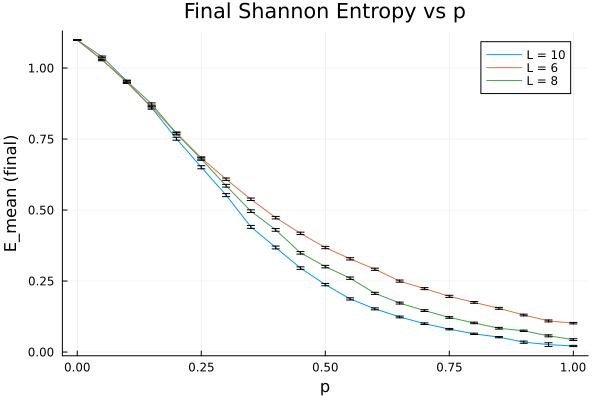

Saved plot → /Users/dirac/Projects-Data/z3-data/z3-shannon-data-26Dec2025-mean/Emean_vs_p_all_L_with_errors.svg


In [37]:
using NPZ
using Glob
using Plots
using Printf

# -------------------------------------------------
# Paths
# -------------------------------------------------
base_root = "/Users/dirac/Projects-Data/z3-data"
mean_root = joinpath(base_root, "z3-shannon-data-26Dec2025-mean")

# Number of shots (CHANGE if needed)
Nshots = 5000

# -------------------------------------------------
# Find all per-L summary files
# -------------------------------------------------
summary_files = sort(Glob.glob("E_final_L*.npy", mean_root))
@assert !isempty(summary_files) "No E_final_L*.npy files found"

# -------------------------------------------------
# Initialize plot
# -------------------------------------------------
plt = plot(
    xlabel = "p",
    ylabel = "E_mean (final)",
    title  = "Final Shannon Entropy vs p",
    legend = :best,
    lw = 2,
    marker = :circle
)

# -------------------------------------------------
# Plot each L with error bars
# -------------------------------------------------
for f in summary_files
    fname = basename(f)

    # Extract L
    m = match(r"L(\d+)", fname)
    m === nothing && continue
    L = parse(Int, m.captures[1])

    data = npzread(f)

    p     = data[:, 1]
    mean  = data[:, 2]
    var   = data[:, 3]

    # Error bars
    err = sqrt.(var ./ Nshots)   # ← remove "/ Nshots" if undesired

    plot!(
        plt,
        p,
        mean,
        yerr = err,
        label = "L = $L"
    )
end

# -------------------------------------------------
# Save SVG
# -------------------------------------------------
out_svg = joinpath(mean_root, "Emean_vs_p_all_L_with_errors.svg")
savefig(plt, out_svg)

display(plt)

println("Saved plot → $out_svg")


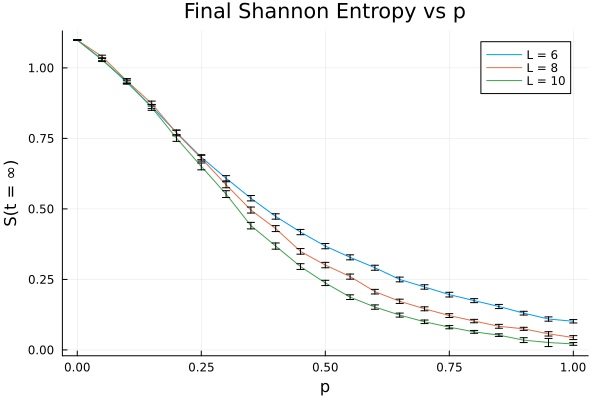

Saved plot → /Users/dirac/Projects-Data/z3-data/z3-shannon-data-26Dec2025-mean/Emean_vs_p_all_L_with_errors.svg


In [44]:
using NPZ
using Glob
using Plots
using Printf

# -------------------------------------------------
# Paths
# -------------------------------------------------
base_root = "/Users/dirac/Projects-Data/z3-data"
mean_root = joinpath(base_root, "z3-shannon-data-26Dec2025-mean")

# Number of shots
Nshots = 1000

# -------------------------------------------------
# Find summary files
# -------------------------------------------------
summary_files = Glob.glob("E_final_L*.npy", mean_root)
@assert !isempty(summary_files) "No E_final_L*.npy files found"

# -------------------------------------------------
# Sort by numeric L (smallest first)
# -------------------------------------------------
summary_files = sort(
    summary_files,
    by = f -> parse(Int, match(r"L(\d+)", basename(f)).captures[1])
)

# -------------------------------------------------
# Initialize plot
# -------------------------------------------------
plt = plot(
    xlabel = "p",
    ylabel = "S(t = ∞)",
    title  = "Final Shannon Entropy vs p",
    legend = :best,
    lw = 2,
    marker = :circle
)

# -------------------------------------------------
# Plot each L
# -------------------------------------------------
for f in summary_files
    L = parse(Int, match(r"L(\d+)", basename(f)).captures[1])

    data = npzread(f)

    p     = data[:, 1]
    mean  = data[:, 2]
    var   = data[:, 3]

    err = sqrt.(var ./ Nshots)

    plot!(
        plt,
        p,
        mean,
        yerr = err,
        label = "L = $L"
    )
end

# -------------------------------------------------
# Save SVG
# -------------------------------------------------
out_svg = joinpath(mean_root, "Emean_vs_p_all_L_with_errors.svg")
savefig(plt, out_svg)

display(plt)

println("Saved plot → $out_svg")


In [ ]:
xlims!(plt, 0.3, 0.7)


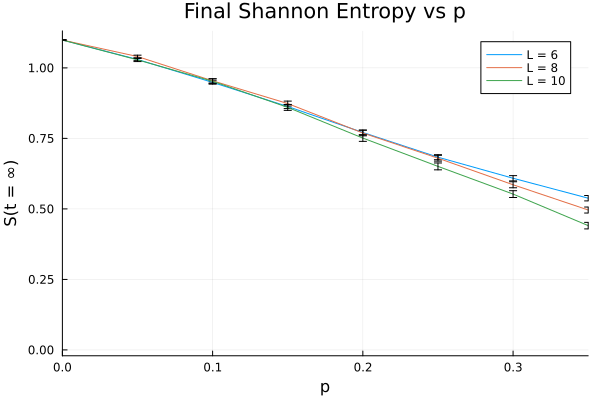

Saved plot → /Users/dirac/Projects-Data/z3-data/z3-shannon-data-26Dec2025-mean/Emean_vs_p_all_L_zoomed.svg


In [49]:
using NPZ
using Glob
using Plots
using Printf

# -------------------------------------------------
# Paths
# -------------------------------------------------
base_root = "/Users/dirac/Projects-Data/z3-data"
mean_root = joinpath(base_root, "z3-shannon-data-26Dec2025-mean")

# Number of shots
Nshots = 1000

# -------------------------------------------------
# Find summary files
# -------------------------------------------------
summary_files = Glob.glob("E_final_L*.npy", mean_root)
@assert !isempty(summary_files) "No E_final_L*.npy files found"

# -------------------------------------------------
# Sort by numeric L (smallest first)
# -------------------------------------------------
summary_files = sort(
    summary_files,
    by = f -> parse(Int, match(r"L(\d+)", basename(f)).captures[1])
)

# -------------------------------------------------
# Initialize plot
# -------------------------------------------------
plt = plot(
    xlabel = "p",
    ylabel = "S(t = ∞)",
    title  = "Final Shannon Entropy vs p",
    legend = :best,
    lw = 2,
    marker = :circle
)

# -------------------------------------------------
# Plot each L
# -------------------------------------------------
for f in summary_files
    L = parse(Int, match(r"L(\d+)", basename(f)).captures[1])

    data = npzread(f)

    p     = data[:, 1]
    mean  = data[:, 2]
    var   = data[:, 3]

    err = sqrt.(var ./ Nshots)

    plot!(
        plt,
        p,
        mean,
        yerr = err,
        label = "L = $L"
    )
end

# -------------------------------------------------
# Save SVG
# -------------------------------------------------
xlims!(plt, 0.0, 0.35)

out_svg = joinpath(mean_root, "Emean_vs_p_all_L_zoomed.svg")
savefig(plt, out_svg)

display(plt)

println("Saved plot → $out_svg")


### Optimized code

In [54]:
using DataFrames
using CSV

# Base directory
base_dir = "/Users/dirac/Projects-Data/z3-data/z3-opt-data-2Jan2026"

# Regex:
# Example filename:
# L6,T60.0,dt1.0,p0.0,dirQ,s8_hc.npy
pattern = r"L(\d+),.*?,p([0-9.]+),.*?,s(\d+)_hc"

rows = DataFrame(
    L = Int[],
    p = Float64[],
    shot = Int[]
)

for (root, _, files) in walkdir(base_dir)
    for f in files
        m = match(pattern, f)
        if m !== nothing
            push!(rows, (
                L = parse(Int, m.captures[1]),
                p = parse(Float64, m.captures[2]),
                shot = parse(Int, m.captures[3])
            ))
        end
    end
end

# Group by (L, p) and count unique shots
ledger = combine(
    groupby(rows, [:L, :p]),
    :shot => (s -> length(unique(s))) => :nshots
)

# Sort for readability
sort!(ledger, [:L, :p])

println("\nLedger (number of shots inferred from sXX indices):")
println(ledger)


Ledger (number of shots inferred from sXX indices):
22×3 DataFrame
 Row │ L      p        nshots 
     │ Int64  Float64  Int64  
─────┼────────────────────────
   1 │     8      0.0    4990
   2 │     8      0.1    5000
   3 │     8      0.2    4995
   4 │     8      0.3    5000
   5 │     8      0.4    4995
   6 │     8      0.5    4990
   7 │     8      0.6    5000
   8 │     8      0.7    5000
   9 │     8      0.8    5000
  10 │     8      0.9    5000
  11 │     8      1.0    5000
  12 │    12      0.0    5000
  13 │    12      0.1    5000
  14 │    12      0.2    5000
  15 │    12      0.3    4995
  16 │    12      0.4    5000
  17 │    12      0.5    5000
  18 │    12      0.6    5000
  19 │    12      0.7    5000
  20 │    12      0.8    5000
  21 │    12      0.9    5000
  22 │    12      1.0    5000


In [52]:
using DataFrames
using CSV

# Base directory
base_dir = "/Users/dirac/Projects-Data/z3-data/z3-opt-data-2Jan2026"

# Regex:
# Example filename:
# L6,T60.0,dt1.0,p0.0,dirQ,s8_hc.npy
pattern = r"L(\d+),.*?,p([0-9.]+),.*?,s(\d+)_se"

rows = DataFrame(
    L = Int[],
    p = Float64[],
    shot = Int[]
)

for (root, _, files) in walkdir(base_dir)
    for f in files
        m = match(pattern, f)
        if m !== nothing
            push!(rows, (
                L = parse(Int, m.captures[1]),
                p = parse(Float64, m.captures[2]),
                shot = parse(Int, m.captures[3])
            ))
        end
    end
end

# Group by (L, p) and count unique shots
ledger = combine(
    groupby(rows, [:L, :p]),
    :shot => (s -> length(unique(s))) => :nshots
)

# Sort for readability
sort!(ledger, [:L, :p])

println("\nLedger (number of shots inferred from sXX indices):")
println(ledger)


Ledger (number of shots inferred from sXX indices):
22×3 DataFrame
 Row │ L      p        nshots 
     │ Int64  Float64  Int64  
─────┼────────────────────────
   1 │     8      0.0    4990
   2 │     8      0.1    5000
   3 │     8      0.2    4995
   4 │     8      0.3    5000
   5 │     8      0.4    4995
   6 │     8      0.5    4990
   7 │     8      0.6    5000
   8 │     8      0.7    5000
   9 │     8      0.8    5000
  10 │     8      0.9    5000
  11 │     8      1.0    5000
  12 │    12      0.0    5000
  13 │    12      0.1    5000
  14 │    12      0.2    5000
  15 │    12      0.3    4995
  16 │    12      0.4    5000
  17 │    12      0.5    5000
  18 │    12      0.6    5000
  19 │    12      0.7    5000
  20 │    12      0.8    5000
  21 │    12      0.9    5000
  22 │    12      1.0    5000


In [60]:
using NPZ
using Glob
using Statistics
using Printf
using Dates

function average_data(L, T, dt, p, d, time_slice)

   # Root directory
    base_root = "/Users/dirac/Projects-Data/z3-data"

    # Input folder (fixed, existing)
    data_folder = joinpath(base_root, "z3-opt-data-2Jan2026")

    # Output folder (mean results)
    save_folder = joinpath(base_root, "z3-opt-data-2Jan2026-mean")
    mkpath(save_folder)

    # -----------------------
    # Correct file name pattern
    # Example:
    #   L8,T80.0,dt1.0,p0.0,dirQ,s6_hc.npy
    # -----------------------
    pattern = @sprintf("L%d,T%.1f,dt%.1f,p%.1f,dir%c,s*_se.npy",
                       L, T, dt, p, d)

    # Find matching files inside the data folder
    shot_files = Glob.glob(pattern, data_folder)

    if isempty(shot_files)
        println("No matching files found in $data_folder")
        return
    end

    println("Found $(length(shot_files)) matching shots.")

    # Load every shot (each file is a vector)
    S_list = [npzread(f) for f in shot_files]

    # Convert list of vectors → matrix (shots × time)
    S_mat = reduce(vcat, [S' for S in S_list])

    # Compute mean and variance across shots
    S_mean = [mean(S_mat[:, i]) for i in 1:time_slice]
    S_var  = [var(S_mat[:, i])  for i in 1:time_slice]

    # Save results
    mean_file = @sprintf("Emean_L%d,T%.1f,dt%.1f,p%.1f_se.npy", L, T, dt, p)
    var_file  = @sprintf("Evar_L%d,T%.1f,dt%.1f,p%.1f_se.npy",  L, T, dt, p)

    npzwrite(joinpath(save_folder, mean_file), S_mean)
    npzwrite(joinpath(save_folder, var_file),  S_var)

    println("Saved results to $save_folder")
end

average_data (generic function with 1 method)

In [61]:
# --------------------------
# Example single run / sweep
# --------------------------
for L in [8, 12]
    T = 10.0 * L
    for p in [
    0.0, 0.05, 0.1, 0.15, 0.2,
    0.25, 0.3, 0.35, 0.4, 0.45,
    0.5, 0.55, 0.6, 0.65, 0.7,
    0.75, 0.8, 0.85, 0.9, 0.95, 1.0
]
        for d in ["Q"]
            dt = 1.0
            average_data(L, T, dt, p, d, 10 * L)
        end
    end
end

Found 4990 matching shots.
Saved results to /Users/dirac/Projects-Data/z3-data/z3-opt-data-2Jan2026-mean
Found 5000 matching shots.
Saved results to /Users/dirac/Projects-Data/z3-data/z3-opt-data-2Jan2026-mean
Found 5000 matching shots.
Saved results to /Users/dirac/Projects-Data/z3-data/z3-opt-data-2Jan2026-mean
Found 5000 matching shots.
Saved results to /Users/dirac/Projects-Data/z3-data/z3-opt-data-2Jan2026-mean
Found 4995 matching shots.
Saved results to /Users/dirac/Projects-Data/z3-data/z3-opt-data-2Jan2026-mean
Found 4995 matching shots.
Saved results to /Users/dirac/Projects-Data/z3-data/z3-opt-data-2Jan2026-mean
Found 5000 matching shots.
Saved results to /Users/dirac/Projects-Data/z3-data/z3-opt-data-2Jan2026-mean
Found 5000 matching shots.
Saved results to /Users/dirac/Projects-Data/z3-data/z3-opt-data-2Jan2026-mean
Found 4995 matching shots.
Saved results to /Users/dirac/Projects-Data/z3-data/z3-opt-data-2Jan2026-mean
Found 4990 matching shots.
Saved results to /Users/dira

In [62]:
using Glob
using Printf

# Mean data root
mean_root = "/Users/dirac/Projects-Data/z3-data/z3-opt-data-2Jan2026-mean"

# Find all mean + variance files
files = Glob.glob("E*_L*,T*,dt*,p*_se.npy", mean_root)

if isempty(files)
    println("No mean/variance files found.")
    return
end

for f in files
    fname = basename(f)

    # Extract L from filename
    # Example: Emean_L6,T60.0,dt1.0,p0.0_hc.npy
    m = match(r"L(\d+),", fname)
    if m === nothing
        @warn "Could not parse L from $fname"
        continue
    end

    L = m.captures[1]

    # Create folder for this L
    L_folder = joinpath(mean_root, "Lq$L")
    mkpath(L_folder)

    # Move file
    mv(f, joinpath(L_folder, fname); force=true)
end

println("Files organized by L successfully.")

Files organized by L successfully.


In [63]:
using NPZ
using Glob
using Printf
using Plots

function plot_by_L_svg(L_values, dt)

    base = "/Users/dirac/Projects-Data/z3-data"
    mean_root = joinpath(base, "z3-opt-data-2Jan2026-mean")

    for L in L_values
        T = 10.0 * L
        folder = joinpath(mean_root, "Lq$L")

        pattern = @sprintf("Emean_L%d,T%.1f,dt%.1f,p*_se.npy", L, T, dt)
        mean_files = Glob.glob(pattern, folder)

        if isempty(mean_files)
            @warn "No files found for L=$L"
            continue
        end

        p_values  = Float64[]
        mean_list = Vector{Vector{Float64}}()
        var_list  = Vector{Vector{Float64}}()

        for mf in mean_files
            fname = basename(mf)
            p_str = split(split(fname, "p")[2], "_")[1]
            p = parse(Float64, p_str)

            push!(p_values, p)
            push!(mean_list, npzread(mf))

            var_file = replace(mf, "Emean" => "Evar")
            push!(var_list, npzread(var_file))
        end

        # Sort by p
        perm = sortperm(p_values)
        p_values  = p_values[perm]
        mean_list = mean_list[perm]
        var_list  = var_list[perm]

        t = 1:length(mean_list[1])

        plt = plot(
            title  = @sprintf("S(t) for L = %d", L),
            xlabel = "time",
            ylabel = "S",
            legend = :right
        )

        for i in eachindex(p_values)
            errors = sqrt.(var_list[i])
            plot!(
                t,
                mean_list[i],
                yerr = errors ./ sqrt(5000),
                label = @sprintf("p = %.2f", p_values[i])
            )
        end

        # -----------------------
        # SAVE AS SVG
        # -----------------------
        out_svg = joinpath(folder, @sprintf("Sq_vs_t_L%d.svg", L))
        savefig(plt, out_svg)

        println("Saved → $out_svg")
    end
end

# ----------------------
# CALL
# ----------------------
plot_by_L_svg([8, 12], 1.0)

Saved → /Users/dirac/Projects-Data/z3-data/z3-opt-data-2Jan2026-mean/Lq8/Sq_vs_t_L8.svg
Saved → /Users/dirac/Projects-Data/z3-data/z3-opt-data-2Jan2026-mean/Lq12/Sq_vs_t_L12.svg



Processing System Size L = 8 ...
........... Done.

Processing System Size L = 12 ...
........... Done.

Generating Summary Plot (Final TMI vs p)...


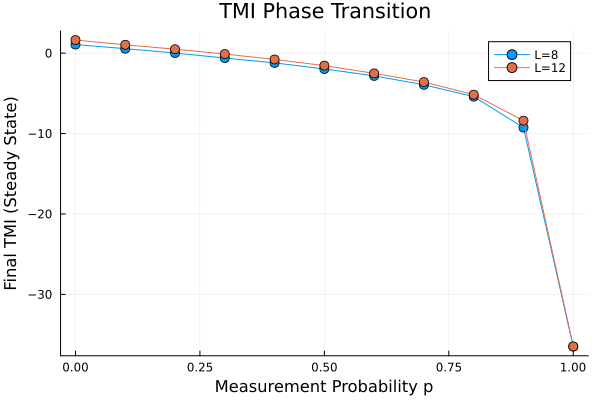

All plots saved.


In [13]:
using NPZ
using Statistics
using Plots
using Printf

# ==========================================
# CONFIGURATION
# ==========================================
# Path to your data
data_dir = "/Users/dirac/Projects-Data/z3-data/z3-haar-tmi-data-Feb3"

L_values = [8, 12]
num_shots = 5000
p_values = range(0.0, 1.0, length=11) # 0.0, 0.1, ... 1.0

# Storage for the final summary plot: Dict(L => (p_vals, final_tmi_vals))
summary_data = Dict{Int, Tuple{Vector{Float64}, Vector{Float64}}}()

# ==========================================
# ANALYSIS LOOP
# ==========================================

for L in L_values
    println("\nProcessing System Size L = $L ...")
    
    T = 10.0 * L
    dt = 1.0
    time_steps = Int(T / dt) + 1 # +1 because it includes t=0
    
    # Prepare Plot 1: TMI(t) vs t for this specific L
    plt_time = plot(
        title = "TMI Dynamics (L=$L)",
        xlabel = "Time (t)",
        ylabel = "Tripartite Mutual Info (I3)",
        legend = :outertopright,
        size = (800, 500),
        margin = 5Plots.mm
    )
    
    # Storage for this L to later plot Final TMI vs p
    final_values_for_L = Float64[]
    
    for p in p_values
        p_str = @sprintf("%.1f", p)
        
        # Accumulator for averaging
        # We assume the time series length is consistent (T/dt + 1)
        accumulated_tmi = zeros(Float64, time_steps)
        count_valid = 0
        
        # --- Load 5000 Shots ---
        for s in 1:num_shots
            # Filename format: L8,T80.0,p0.0,s11_tmi.npy
            fname = "L$(L),T$(T),p$(p_str),s$(s)_tmi.npy"
            fpath = joinpath(data_dir, fname)
            
            if isfile(fpath)
                try
                    traj = npzread(fpath)
                    
                    # Ensure trajectory length matches accumulator
                    if length(traj) == length(accumulated_tmi)
                        accumulated_tmi .+= traj
                        count_valid += 1
                    elseif length(traj) > length(accumulated_tmi)
                        # Handle case where file might be slightly longer/shorter
                        len = min(length(traj), length(accumulated_tmi))
                        accumulated_tmi[1:len] .+= traj[1:len]
                        count_valid += 1
                    end
                catch e
                    # Ignore corrupted files
                end
            end
        end
        
        if count_valid > 0
            avg_tmi = accumulated_tmi ./ count_valid
            
            # 1. Add to Time Series Plot (Plot lines for subset of p to avoid clutter)
            # Plotting all 11 lines might be messy, but we plot them all as requested
            plot!(plt_time, 0:dt:T, -avg_tmi, label="p=$(p_str)", lw=2, alpha=0.8)
            
            # 2. Extract Final Value (at t=T)
            # We take the mean of the last few steps to smooth out fluctuations if needed, 
            # or just the absolute last point. Here we take the last point.
            push!(final_values_for_L, avg_tmi[end])
            
            print(".") # Progress dot
        else
            println("  Warning: No data found for L=$L, p=$p_str")
            push!(final_values_for_L, NaN)
        end
    end
    
    println(" Done.")
    
    # Save the Time Series plot for this L
    savefig(plt_time, "TMI_TimeEvolution_L$(L).pdf")
    
    # Store data for the final phase transition plot
    summary_data[L] = (collect(p_values), final_values_for_L)
end

# ==========================================
# FINAL SUMMARY PLOT (TMI_final vs p)
# ==========================================

println("\nGenerating Summary Plot (Final TMI vs p)...")

plt_summary = plot(
    title = "TMI Phase Transition",
    xlabel = "Measurement Probability p",
    ylabel = "Final TMI (Steady State)",
    legend = :topright,
    marker = :circle,
    lw = 2
)

# Iterate over sorted L values to keep legend ordered
for L in sort(keys(summary_data) |> collect)
    (p_vals, finals) = summary_data[L]
    plot!(plt_summary, p_vals, log.(-finals), label="L=$L", marker=:circle, markersize=5)
end

display(plt_summary)
savefig(plt_summary, "TMI_PhaseTransition_Summary_log.pdf")
println("All plots saved.")


Processing System Size L = 8 ...
........... Done.

Processing System Size L = 12 ...
........... Done.

Generating Summary Plot (TMI at t=L vs p)...


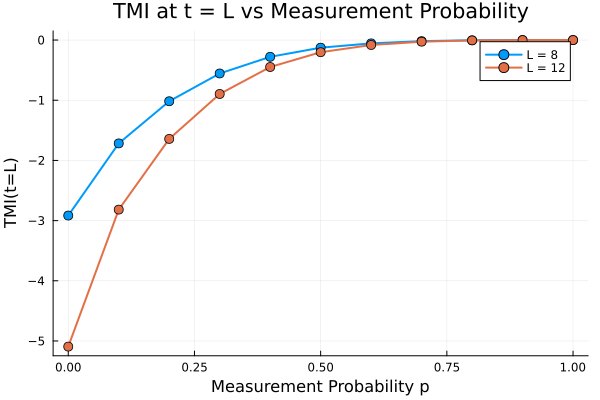

Plot saved as TMI_at_t_equals_L_Summary.png


In [ ]:
using NPZ
using Statistics
using Plots
using Printf

# ==========================================
# CONFIGURATION
# ==========================================
data_dir = "/Users/dirac/Projects-Data/z3-data/z3-haar-tmi-data-Feb3"

L_values = [8, 12]
num_shots = 5000
p_values = range(0.0, 1.0, length=11) # 0.0, 0.1, ... 1.0

# Storage for the summary plot: Dict(L => (p_vals, tmi_at_L_vals))
summary_data = Dict{Int, Tuple{Vector{Float64}, Vector{Float64}}}()

# ==========================================
# ANALYSIS LOOP
# ==========================================

for L in L_values
    println("\nProcessing System Size L = $L ...")
    
    T = 10.0 * L
    dt = 1.0
    
    # We expect data for t = 0, 1, ..., T
    expected_length = Int(T / dt) + 1 
    
    # We want to extract the value at time t = L
    # Since array index 1 corresponds to t=0, the index for t=L is L + 1
    target_index = L + 1
    
    # Storage for this specific L
    values_at_t_equals_L = Float64[]
    
    for p in p_values
        p_str = @sprintf("%.1f", p)
        
        # Accumulator for averaging
        accumulated_tmi = zeros(Float64, expected_length)
        count_valid = 0
        
        # --- Load 5000 Shots ---
        for s in 1:num_shots
            fname = "L$(L),T$(T),p$(p_str),s$(s)_tmi.npy"
            fpath = joinpath(data_dir, fname)
            
            if isfile(fpath)
                try
                    traj = npzread(fpath)
                    
                    # Handle slight length mismatches if file IO was weird
                    len = min(length(traj), length(accumulated_tmi))
                    accumulated_tmi[1:len] .+= traj[1:len]
                    count_valid += 1
                catch e
                    # Skip corrupted files
                end
            end
        end
        
        if count_valid > 0
            avg_traj = accumulated_tmi ./ count_valid
            
            # --- EXTRACT VALUE AT t = L ---
            if length(avg_traj) >= target_index
                val_at_L = avg_traj[target_index]
                push!(values_at_t_equals_L, val_at_L)
            else
                println("  Error: Trajectory too short to find t=L for p=$p_str")
                push!(values_at_t_equals_L, NaN)
            end
            
            print(".") 
        else
            println("  Warning: No data found for L=$L, p=$p_str")
            push!(values_at_t_equals_L, NaN)
        end
    end
    
    println(" Done.")
    
    # Store data for the summary plot
    summary_data[L] = (collect(p_values), values_at_t_equals_L)
end

# ==========================================
# SUMMARY PLOT (TMI(t=L) vs p)
# ==========================================

println("\nGenerating Summary Plot (TMI at t=L vs p)...")

plt_summary = plot(
    title = "TMI at t = L vs Measurement Probability",
    xlabel = "Measurement Probability p",
    ylabel = "TMI(t=L)",
    legend = :bottomright,
    grid = true,
    lw = 2
)

# Sort L values so the legend is clean (L=8, then L=12...)
for L in sort(collect(keys(summary_data)))
    (p_vals, tmi_vals) = summary_data[L]
    
    plot!(plt_summary, p_vals, tmi_vals, 
        label = "L = $L", 
        marker = :circle, 
        markersize = 5,
        lw = 2
    )
end

display(plt_summary)
savefig(plt_summary, "TMI_at_t_equals_L_Summary.svg")
println("Plot saved as TMI_at_t_equals_L_Summary.svg")


Processing System Size L = 8 ...
........... Done.

Processing System Size L = 12 ...
........... Done.

Processing System Size L = 16 ...
........... Done.

Generating Summary Plot (Shannon Entropy at t=L vs p)...


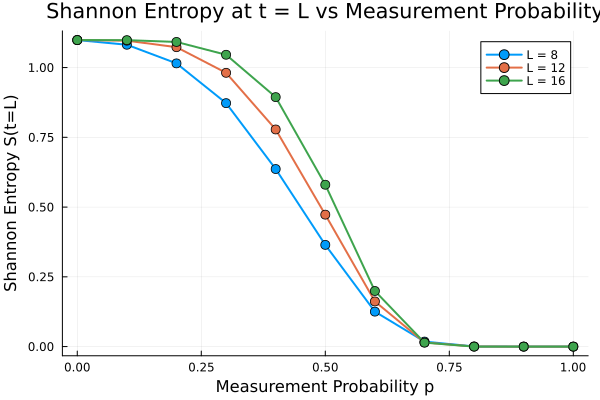

Plot saved as ShannonEntropy_at_t_equals_L_Summary.svg


In [ ]:
using NPZ
using Statistics
using Plots
using Printf

# ==========================================
# CONFIGURATION
# ==========================================
# Update this to the folder where your Shannon Entropy data is stored
data_dir = "/Users/dirac/Projects-Data/z3-data/z3-haar-shannon-data-Feb4" 

L_values = [8, 12, 16]
num_shots = 5000
p_values = range(0.0, 1.0, length=11) 

# Storage for the summary: Dict(L => (p_vals, se_at_L_vals))
summary_data = Dict{Int, Tuple{Vector{Float64}, Vector{Float64}}}()

# ==========================================
# ANALYSIS LOOP
# ==========================================

for L in L_values
    println("\nProcessing System Size L = $L ...")
    
    # BASED ON YOUR EXAMPLE FILE: "L12,T24.0..."
    # This implies T = 2 * L. 
    # (If your L=8 files used T=80.0, change this back to 10.0 * L)
    T = 2.0 * L  
    dt = 1.0
    
    # We expect data for t = 0, 1, ..., T
    expected_length = Int(T / dt) + 1 
    
    # We want to extract the value at time t = L
    # Since array index 1 corresponds to t=0, the index for t=L is L + 1
    target_index = L + 1
    
    # Storage for this specific L
    se_at_t_equals_L = Float64[]
    
    for p in p_values
        p_str = @sprintf("%.1f", p)
        
        # Accumulator for averaging
        accumulated_se = zeros(Float64, expected_length)
        count_valid = 0
        
        # --- Load 5000 Shots ---
        for s in 1:num_shots
            # UPDATED FILENAME FORMAT: _se.npy
            fname = "L$(L),T$(T),p$(p_str),s$(s)_se.npy"
            fpath = joinpath(data_dir, fname)
            
            if isfile(fpath)
                try
                    traj = npzread(fpath)
                    
                    # Handle slight length mismatches
                    len = min(length(traj), length(accumulated_se))
                    accumulated_se[1:len] .+= traj[1:len]
                    count_valid += 1
                catch e
                    # Skip corrupted files
                end
            end
        end
        
        if count_valid > 0
            avg_traj = accumulated_se ./ count_valid
            
            # --- EXTRACT VALUE AT t = L ---
            if length(avg_traj) >= target_index
                val_at_L = avg_traj[target_index]
                push!(se_at_t_equals_L, val_at_L)
            else
                println("  Error: Trajectory too short to find t=L for p=$p_str")
                push!(se_at_t_equals_L, NaN)
            end
            
            print(".") 
        else
            println("  Warning: No data found for L=$L, p=$p_str")
            push!(se_at_t_equals_L, NaN)
        end
    end
    
    println(" Done.")
    
    # Store data for the summary plot
    summary_data[L] = (collect(p_values), se_at_t_equals_L)
end

# ==========================================
# SUMMARY PLOT (Shannon Entropy(t=L) vs p)
# ==========================================

println("\nGenerating Summary Plot (Shannon Entropy at t=L vs p)...")

plt_summary = plot(
    title = "Shannon Entropy at t = L vs Measurement Probability",
    xlabel = "Measurement Probability p",
    ylabel = "Shannon Entropy S(t=L)",
    legend = :topright,
    grid = true,
    lw = 2
)

# Sort L values so the legend is clean
for L in sort(collect(keys(summary_data)))
    (p_vals, se_vals) = summary_data[L]
    
    plot!(plt_summary, p_vals, se_vals, 
        label = "L = $L", 
        marker = :circle, 
        markersize = 5,
        lw = 2
    )
end

display(plt_summary)
savefig(plt_summary, "ShannonEntropy_at_t_equals_L_Summary.svg")
println("Plot saved as ShannonEntropy_at_t_equals_L_Summary.svg")


Processing System Size L = 8 ...
........... Done.

Processing System Size L = 12 ...
........... Done.

Processing System Size L = 16 ...
........... Done.

Generating Summary Plot (Shannon Entropy at t=L vs p)...


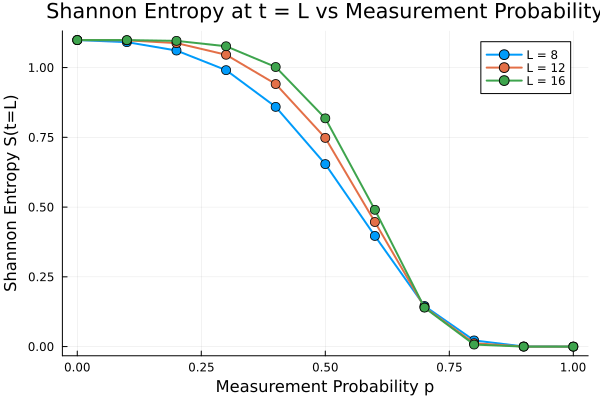

Plot saved as ShannonEntropy_at_t_equals_L_Summary.pdf


In [11]:
using NPZ
using Statistics
using Plots
using Printf

# ==========================================
# CONFIGURATION
# ==========================================
# Update this to the folder where your Shannon Entropy data is stored
data_dir = "/Users/dirac/Projects-Data/z3-data/z3-haar-shannon-data-Feb4" 

L_values = [8, 12, 16]
num_shots = 5000
p_values = range(0.0, 1.0, length=11) 

# Storage for the summary: Dict(L => (p_vals, se_at_L_vals))
summary_data = Dict{Int, Tuple{Vector{Float64}, Vector{Float64}}}()

# ==========================================
# ANALYSIS LOOP
# ==========================================

for L in L_values
    println("\nProcessing System Size L = $L ...")
    
    # BASED ON YOUR EXAMPLE FILE: "L12,T24.0..."
    # This implies T = 2 * L. 
    # (If your L=8 files used T=80.0, change this back to 10.0 * L)
    T = 2.0 * L  
    dt = 1.0
    
    # We expect data for t = 0, 1, ..., T
    expected_length = Int(T / dt) + 1 
    
    # We want to extract the value at time t = L
    # Since array index 1 corresponds to t=0, the index for t=L is L + 1
    target_index = L + 1
    
    # Storage for this specific L
    se_at_t_equals_L = Float64[]
    
    for p in p_values
        p_str = @sprintf("%.1f", p)
        
        # Accumulator for averaging
        accumulated_se = zeros(Float64, expected_length)
        count_valid = 0
        
        # --- Load 5000 Shots ---
        for s in 1:num_shots
            # UPDATED FILENAME FORMAT: _se.npy
            fname = "L$(L),T$(T),p$(p_str),s$(s)_se.npy"
            fpath = joinpath(data_dir, fname)
            
            if isfile(fpath)
                try
                    traj = npzread(fpath)
                    
                    # Handle slight length mismatches
                    len = min(length(traj), length(accumulated_se))
                    accumulated_se[1:len] .+= traj[1:len]
                    count_valid += 1
                catch e
                    # Skip corrupted files
                end
            end
        end
        
        if count_valid > 0
            avg_traj = accumulated_se ./ count_valid
            
            # --- EXTRACT VALUE AT t = L ---
            if length(avg_traj) >= target_index
                val_at_L = avg_traj[target_index]
                push!(se_at_t_equals_L, val_at_L)
            else
                println("  Error: Trajectory too short to find t=L for p=$p_str")
                push!(se_at_t_equals_L, NaN)
            end
            
            print(".") 
        else
            println("  Warning: No data found for L=$L, p=$p_str")
            push!(se_at_t_equals_L, NaN)
        end
    end
    
    println(" Done.")
    
    # Store data for the summary plot
    summary_data[L] = (collect(p_values), se_at_t_equals_L)
end

# ==========================================
# SUMMARY PLOT (Shannon Entropy(t=L) vs p)
# ==========================================

println("\nGenerating Summary Plot (Shannon Entropy at t=L vs p)...")

plt_summary = plot(
    title = "Shannon Entropy at t = L vs Measurement Probability",
    xlabel = "Measurement Probability p",
    ylabel = "Shannon Entropy S(t=L)",
    legend = :topright,
    grid = true,
    lw = 2
)

# Sort L values so the legend is clean
for L in sort(collect(keys(summary_data)))
    (p_vals, se_vals) = summary_data[L]
    
    plot!(plt_summary, p_vals, se_vals, 
        label = "L = $L", 
        marker = :circle, 
        markersize = 5,
        lw = 2
    )
end

display(plt_summary)
savefig(plt_summary, "ShannonEntropy_at_t_equals_L_Summary.pdf")
println("Plot saved as ShannonEntropy_at_t_equals_L_Summary.pdf")


Processing System Size L = 8 ...
...... Done.

Processing System Size L = 12 ...
...... Done.

Processing System Size L = 16 ...
...... Done.

Generating Summary Plot (Shannon Entropy at t=L vs p)...


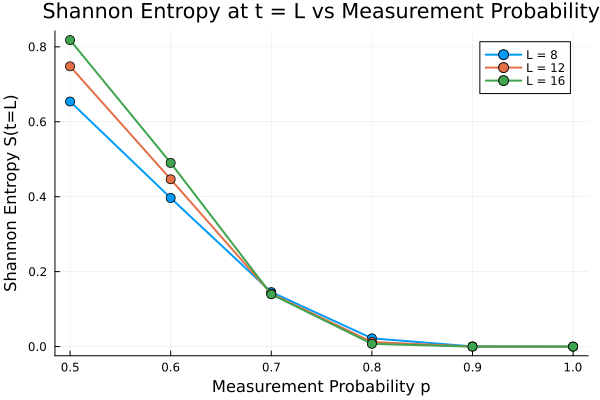

Plot saved as ShannonEntropy_at_t_equals_L_Summary_zoomed.pdf


In [6]:
using NPZ
using Statistics
using Plots
using Printf

# ==========================================
# CONFIGURATION
# ==========================================
# Update this to the folder where your Shannon Entropy data is stored
data_dir = "/Users/dirac/Projects-Data/z3-data/z3-haar-shannon-data-Feb4" 

L_values = [8, 12, 16]
num_shots = 5000
p_values = [0.5, 0.6, 0.7, 0.8, 0.9, 1.0]

# Storage for the summary: Dict(L => (p_vals, se_at_L_vals))
summary_data = Dict{Int, Tuple{Vector{Float64}, Vector{Float64}}}()

# ==========================================
# ANALYSIS LOOP
# ==========================================

for L in L_values
    println("\nProcessing System Size L = $L ...")
    
    # BASED ON YOUR EXAMPLE FILE: "L12,T24.0..."
    # This implies T = 2 * L. 
    # (If your L=8 files used T=80.0, change this back to 10.0 * L)
    T = 2.0 * L  
    dt = 1.0
    
    # We expect data for t = 0, 1, ..., T
    expected_length = Int(T / dt) + 1 
    
    # We want to extract the value at time t = L
    # Since array index 1 corresponds to t=0, the index for t=L is L + 1
    target_index = L + 1
    
    # Storage for this specific L
    se_at_t_equals_L = Float64[]
    
    for p in p_values
        p_str = @sprintf("%.1f", p)
        
        # Accumulator for averaging
        accumulated_se = zeros(Float64, expected_length)
        count_valid = 0
        
        # --- Load 5000 Shots ---
        for s in 1:num_shots
            # UPDATED FILENAME FORMAT: _se.npy
            fname = "L$(L),T$(T),p$(p_str),s$(s)_se.npy"
            fpath = joinpath(data_dir, fname)
            
            if isfile(fpath)
                try
                    traj = npzread(fpath)
                    
                    # Handle slight length mismatches
                    len = min(length(traj), length(accumulated_se))
                    accumulated_se[1:len] .+= traj[1:len]
                    count_valid += 1
                catch e
                    # Skip corrupted files
                end
            end
        end
        
        if count_valid > 0
            avg_traj = accumulated_se ./ count_valid
            
            # --- EXTRACT VALUE AT t = L ---
            if length(avg_traj) >= target_index
                val_at_L = avg_traj[target_index]
                push!(se_at_t_equals_L, val_at_L)
            else
                println("  Error: Trajectory too short to find t=L for p=$p_str")
                push!(se_at_t_equals_L, NaN)
            end
            
            print(".") 
        else
            println("  Warning: No data found for L=$L, p=$p_str")
            push!(se_at_t_equals_L, NaN)
        end
    end
    
    println(" Done.")
    
    # Store data for the summary plot
    summary_data[L] = (collect(p_values), se_at_t_equals_L)
end

# ==========================================
# SUMMARY PLOT (Shannon Entropy(t=L) vs p)
# ==========================================

println("\nGenerating Summary Plot (Shannon Entropy at t=L vs p)...")

plt_summary = plot(
    title = "Shannon Entropy at t = L vs Measurement Probability",
    xlabel = "Measurement Probability p",
    ylabel = "Shannon Entropy S(t=L)",
    legend = :topright,
    grid = true,
    lw = 2
)

# Sort L values so the legend is clean
for L in sort(collect(keys(summary_data)))
    (p_vals, se_vals) = summary_data[L]
    
    plot!(plt_summary, p_vals, se_vals, 
        label = "L = $L", 
        marker = :circle, 
        markersize = 5,
        lw = 2
    )
end

display(plt_summary)
savefig(plt_summary, "ShannonEntropy_at_t_equals_L_Summary_zoomed.pdf")
println("Plot saved as ShannonEntropy_at_t_equals_L_Summary_zoomed.pdf")

In [ ]:
/Users/dirac/Projects-Data/z3-data/z3-haar-shannon-data-Feb6


Processing System Size L = 8 ...
.  Warning: No data found for L=8, p=0.550
.  Warning: No data found for L=8, p=0.600
.  Warning: No data found for L=8, p=0.650
.  Warning: No data found for L=8, p=0.700
.  Warning: No data found for L=8, p=0.750
.  Warning: No data found for L=8, p=0.800
.  Warning: No data found for L=8, p=0.850
.  Warning: No data found for L=8, p=0.900
.  Warning: No data found for L=8, p=0.950
.  Warning: No data found for L=8, p=1.000
 Done.

Processing System Size L = 12 ...
.  Warning: No data found for L=12, p=0.550
.  Warning: No data found for L=12, p=0.600
.  Warning: No data found for L=12, p=0.650
.  Warning: No data found for L=12, p=0.700
.  Warning: No data found for L=12, p=0.750
.  Warning: No data found for L=12, p=0.800
.  Warning: No data found for L=12, p=0.850
.  Warning: No data found for L=12, p=0.900
.  Warning: No data found for L=12, p=0.950
.  Warning: No data found for L=12, p=1.000
 Done.

Processing System Size L = 16 ...
.  Warning: 

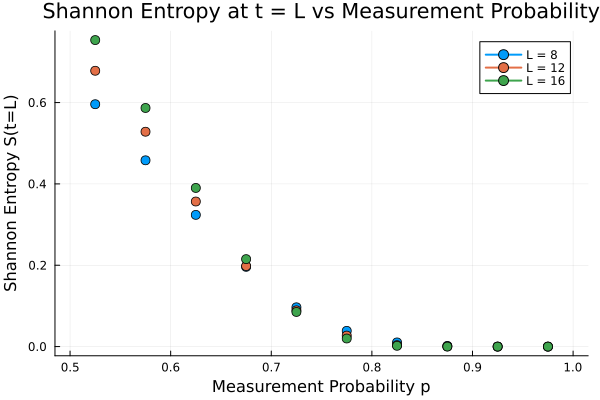

Plot saved as ShannonEntropy_at_t_equals_L_Summary_p#.pdf


In [9]:
using NPZ
using Statistics
using Plots
using Printf

# ==========================================
# CONFIGURATION
# ==========================================
# Update this to the folder where your Shannon Entropy data is stored
data_dir = "/Users/dirac/Projects-Data/z3-data/z3-haar-shannon-data-Feb6" 

L_values = [8, 12, 16]
num_shots = 5000
p_values = range(0.5, 1.0, length=21) 

# Storage for the summary: Dict(L => (p_vals, se_at_L_vals))
summary_data = Dict{Int, Tuple{Vector{Float64}, Vector{Float64}}}()

# ==========================================
# ANALYSIS LOOP
# ==========================================

for L in L_values
    println("\nProcessing System Size L = $L ...")
    
    # BASED ON YOUR EXAMPLE FILE: "L12,T24.0..."
    # This implies T = 2 * L. 
    # (If your L=8 files used T=80.0, change this back to 10.0 * L)
    T = 2.0 * L  
    dt = 1.0
    
    # We expect data for t = 0, 1, ..., T
    expected_length = Int(T / dt) + 1 
    
    # We want to extract the value at time t = L
    # Since array index 1 corresponds to t=0, the index for t=L is L + 1
    target_index = L + 1
    
    # Storage for this specific L
    se_at_t_equals_L = Float64[]
    
    for p in p_values
        p_str = @sprintf("%.3f", p)
        
        # Accumulator for averaging
        accumulated_se = zeros(Float64, expected_length)
        count_valid = 0
        
        # --- Load 5000 Shots ---
        for s in 1:num_shots
            # UPDATED FILENAME FORMAT: _se.npy
            fname = "L$(L),T$(T),p$(p_str),s$(s)_se.npy"
            fpath = joinpath(data_dir, fname)
            
            if isfile(fpath)
                try
                    traj = npzread(fpath)
                    
                    # Handle slight length mismatches
                    len = min(length(traj), length(accumulated_se))
                    accumulated_se[1:len] .+= traj[1:len]
                    count_valid += 1
                catch e
                    # Skip corrupted files
                end
            end
        end
        
        if count_valid > 0
            avg_traj = accumulated_se ./ count_valid
            
            # --- EXTRACT VALUE AT t = L ---
            if length(avg_traj) >= target_index
                val_at_L = avg_traj[target_index]
                push!(se_at_t_equals_L, val_at_L)
            else
                println("  Error: Trajectory too short to find t=L for p=$p_str")
                push!(se_at_t_equals_L, NaN)
            end
            
            print(".") 
        else
            println("  Warning: No data found for L=$L, p=$p_str")
            push!(se_at_t_equals_L, NaN)
        end
    end
    
    println(" Done.")
    
    # Store data for the summary plot
    summary_data[L] = (collect(p_values), se_at_t_equals_L)
end

# ==========================================
# SUMMARY PLOT (Shannon Entropy(t=L) vs p)
# ==========================================

println("\nGenerating Summary Plot (Shannon Entropy at t=L vs p)...")

plt_summary = plot(
    title = "Shannon Entropy at t = L vs Measurement Probability",
    xlabel = "Measurement Probability p",
    ylabel = "Shannon Entropy S(t=L)",
    legend = :topright,
    grid = true,
    lw = 2
)

# Sort L values so the legend is clean
for L in sort(collect(keys(summary_data)))
    (p_vals, se_vals) = summary_data[L]
    
    plot!(plt_summary, p_vals, se_vals, 
        label = "L = $L", 
        marker = :circle, 
        markersize = 5,
        lw = 2
    )
end

display(plt_summary)
savefig(plt_summary, "ShannonEntropy_at_t_equals_L_Summary_p#.pdf")
println("Plot saved as ShannonEntropy_at_t_equals_L_Summary_p#.pdf")

In [10]:
range(0.5, 1.0, length=21) 

0.5:0.025:1.0


Processing System Size L = 8 ...
..................... Done.

Processing System Size L = 12 ...
..................... Done.

Processing System Size L = 16 ...
..................... Done.

Generating Summary Plot...


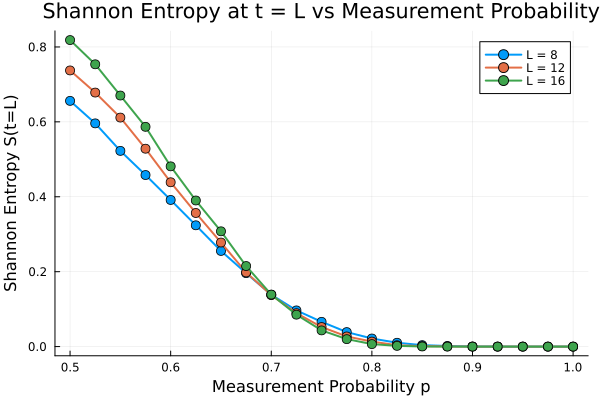

Plot saved as ShannonEntropy_at_t_equals_L_Summary_p#.pdf


In [11]:
using NPZ
using Statistics
using Plots
using Printf

# ==========================================
# CONFIGURATION
# ==========================================
data_dir = "/Users/dirac/Projects-Data/z3-data/z3-haar-shannon-data-Feb6" 

L_values = [8, 12, 16]
num_shots = 5000

# This range (0.5 to 1.0 with 21 steps) produces the step size 0.025
# Values: 0.5, 0.525, 0.55 ... 0.75 ... 1.0
p_values = range(0.5, 1.0, length=21) 

summary_data = Dict{Int, Tuple{Vector{Float64}, Vector{Float64}}}()

# ==========================================
# ANALYSIS LOOP
# ==========================================

for L in L_values
    println("\nProcessing System Size L = $L ...")
    
    # Filenames conform to T = 2.0 * L (e.g., L8->T16.0, L12->T24.0)
    T = 2.0 * L  
    dt = 1.0
    
    expected_length = Int(T / dt) + 1 
    target_index = L + 1
    
    se_at_t_equals_L = Float64[]
    
    for p in p_values
        # 1. Round to avoid machine epsilon errors (e.g. 0.6000000001)
        # 2. Convert to string to handle variable length (0.8 vs 0.625)
        #    string(0.8) -> "0.8"
        #    string(0.625) -> "0.625"
        #    string(1.0) -> "1.0"
        p_clean = round(p, digits=4)
        p_str = string(p_clean)
        
        accumulated_se = zeros(Float64, expected_length)
        count_valid = 0
        
        for s in 1:num_shots
            # Filename format: L12,T24.0,p0.8,s1554_se.npy
            fname = "L$(L),T$(T),p$(p_str),s$(s)_se.npy"
            fpath = joinpath(data_dir, fname)
            
            if isfile(fpath)
                try
                    traj = npzread(fpath)
                    
                    len = min(length(traj), length(accumulated_se))
                    accumulated_se[1:len] .+= traj[1:len]
                    count_valid += 1
                catch
                    # Skip corrupted
                end
            end
        end
        
        if count_valid > 0
            avg_traj = accumulated_se ./ count_valid
            
            if length(avg_traj) >= target_index
                val_at_L = avg_traj[target_index]
                push!(se_at_t_equals_L, val_at_L)
            else
                push!(se_at_t_equals_L, NaN)
            end
            print(".") 
        else
            # print("x") # Optional: mark missing data
            push!(se_at_t_equals_L, NaN)
        end
    end
    
    println(" Done.")
    summary_data[L] = (collect(p_values), se_at_t_equals_L)
end

# ==========================================
# SUMMARY PLOT
# ==========================================

println("\nGenerating Summary Plot...")

plt_summary = plot(
    title = "Shannon Entropy at t = L vs Measurement Probability",
    xlabel = "Measurement Probability p",
    ylabel = "Shannon Entropy S(t=L)",
    legend = :topright,
    grid = true,
    lw = 2
)

for L in sort(collect(keys(summary_data)))
    (p_vals, se_vals) = summary_data[L]
    
    # Filter out NaNs for cleaner plotting lines
    mask = .!isnan.(se_vals)
    
    plot!(plt_summary, p_vals[mask], se_vals[mask], 
        label = "L = $L", 
        marker = :circle, 
        markersize = 5,
        lw = 2
    )
end

display(plt_summary)
savefig(plt_summary, "ShannonEntropy_at_t_equals_L_Summary_p#.pdf")
println("Plot saved as ShannonEntropy_at_t_equals_L_Summary_p#.pdf")


Processing System Size L = 8 ...
..................... Done.

Processing System Size L = 12 ...
..................... Done.

Processing System Size L = 16 ...
..................... Done.

Generating Summary Plot...


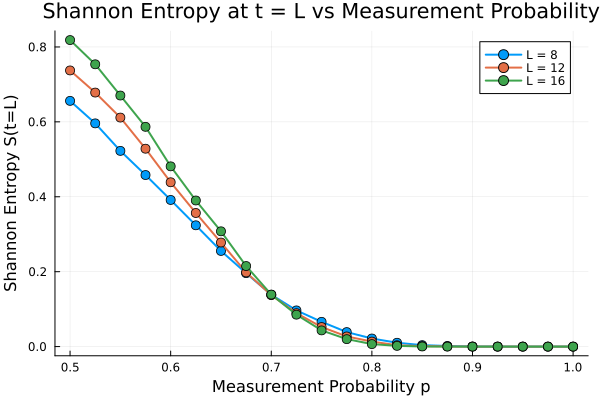

Plot saved as ShannonEntropy_at_t_equals_L_Summary_p#.svg


In [12]:
using NPZ
using Statistics
using Plots
using Printf

# ==========================================
# CONFIGURATION
# ==========================================
data_dir = "/Users/dirac/Projects-Data/z3-data/z3-haar-shannon-data-Feb6" 

L_values = [8, 12, 16]
num_shots = 5000

# This range (0.5 to 1.0 with 21 steps) produces the step size 0.025
# Values: 0.5, 0.525, 0.55 ... 0.75 ... 1.0
p_values = range(0.5, 1.0, length=21) 

summary_data = Dict{Int, Tuple{Vector{Float64}, Vector{Float64}}}()

# ==========================================
# ANALYSIS LOOP
# ==========================================

for L in L_values
    println("\nProcessing System Size L = $L ...")
    
    # Filenames conform to T = 2.0 * L (e.g., L8->T16.0, L12->T24.0)
    T = 2.0 * L  
    dt = 1.0
    
    expected_length = Int(T / dt) + 1 
    target_index = L + 1
    
    se_at_t_equals_L = Float64[]
    
    for p in p_values
        # 1. Round to avoid machine epsilon errors (e.g. 0.6000000001)
        # 2. Convert to string to handle variable length (0.8 vs 0.625)
        #    string(0.8) -> "0.8"
        #    string(0.625) -> "0.625"
        #    string(1.0) -> "1.0"
        p_clean = round(p, digits=4)
        p_str = string(p_clean)
        
        accumulated_se = zeros(Float64, expected_length)
        count_valid = 0
        
        for s in 1:num_shots
            # Filename format: L12,T24.0,p0.8,s1554_se.npy
            fname = "L$(L),T$(T),p$(p_str),s$(s)_se.npy"
            fpath = joinpath(data_dir, fname)
            
            if isfile(fpath)
                try
                    traj = npzread(fpath)
                    
                    len = min(length(traj), length(accumulated_se))
                    accumulated_se[1:len] .+= traj[1:len]
                    count_valid += 1
                catch
                    # Skip corrupted
                end
            end
        end
        
        if count_valid > 0
            avg_traj = accumulated_se ./ count_valid
            
            if length(avg_traj) >= target_index
                val_at_L = avg_traj[target_index]
                push!(se_at_t_equals_L, val_at_L)
            else
                push!(se_at_t_equals_L, NaN)
            end
            print(".") 
        else
            # print("x") # Optional: mark missing data
            push!(se_at_t_equals_L, NaN)
        end
    end
    
    println(" Done.")
    summary_data[L] = (collect(p_values), se_at_t_equals_L)
end

# ==========================================
# SUMMARY PLOT
# ==========================================

println("\nGenerating Summary Plot...")

plt_summary = plot(
    title = "Shannon Entropy at t = L vs Measurement Probability",
    xlabel = "Measurement Probability p",
    ylabel = "Shannon Entropy S(t=L)",
    legend = :topright,
    grid = true,
    lw = 2
)

for L in sort(collect(keys(summary_data)))
    (p_vals, se_vals) = summary_data[L]
    
    # Filter out NaNs for cleaner plotting lines
    mask = .!isnan.(se_vals)
    
    plot!(plt_summary, p_vals[mask], se_vals[mask], 
        label = "L = $L", 
        marker = :circle, 
        markersize = 5,
        lw = 2
    )
end

display(plt_summary)
savefig(plt_summary, "ShannonEntropy_at_t_equals_L_Summary_p#.svg")
println("Plot saved as ShannonEntropy_at_t_equals_L_Summary_p#.svg")

In [ ]:
using NPZ
using Statistics
using Plots
using Printf

# ==========================================
# CONFIGURATION
# ==========================================
data_dir = "/Users/dirac/Projects-Data/z3-data/z3-haar-shannon-data-Feb6" 

L_values = [8, 12, 16]
num_shots = 5000

# This range (0.5 to 1.0 with 21 steps) produces the step size 0.025
# Values: 0.5, 0.525, 0.55 ... 0.75 ... 1.0
p_values = range(0.5, 1.0, length=21) 

summary_data = Dict{Int, Tuple{Vector{Float64}, Vector{Float64}}}()

# ==========================================
# ANALYSIS LOOP
# ==========================================

for L in L_values
    println("\nProcessing System Size L = $L ...")
    
    # Filenames conform to T = 2.0 * L (e.g., L8->T16.0, L12->T24.0)
    T = 2.0 * L  
    dt = 1.0
    
    expected_length = Int(T / dt) + 1 
    target_index = L + 1
    
    se_at_t_equals_L = Float64[]
    
    for p in p_values
        # 1. Round to avoid machine epsilon errors (e.g. 0.6000000001)
        # 2. Convert to string to handle variable length (0.8 vs 0.625)
        #    string(0.8) -> "0.8"
        #    string(0.625) -> "0.625"
        #    string(1.0) -> "1.0"
        p_clean = round(p, digits=4)
        p_str = string(p_clean)
        
        accumulated_se = zeros(Float64, expected_length)
        count_valid = 0
        
        for s in 1:num_shots
            # Filename format: L12,T24.0,p0.8,s1554_se.npy
            fname = "L$(L),T$(T),p$(p_str),s$(s)_se.npy"
            fpath = joinpath(data_dir, fname)
            
            if isfile(fpath)
                try
                    traj = npzread(fpath)
                    
                    len = min(length(traj), length(accumulated_se))
                    accumulated_se[1:len] .+= traj[1:len]
                    count_valid += 1
                catch
                    # Skip corrupted
                end
            end
        end
        
        if count_valid > 0
            avg_traj = accumulated_se ./ count_valid
            
            if length(avg_traj) >= target_index
                val_at_L = avg_traj[target_index]
                push!(se_at_t_equals_L, val_at_L)
            else
                push!(se_at_t_equals_L, NaN)
            end
            print(".") 
        else
            # print("x") # Optional: mark missing data
            push!(se_at_t_equals_L, NaN)
        end
    end
    
    println(" Done.")
    summary_data[L] = (collect(p_values), se_at_t_equals_L)
end

# ==========================================
# SUMMARY PLOT
# ==========================================

println("\nGenerating Summary Plot...")

plt_summary = plot(
    title = "Shannon Entropy at t = L vs Measurement Probability",
    xlabel = "Measurement Probability p",
    ylabel = "Shannon Entropy S(t=L)",
    legend = :topright,
    grid = true,
    lw = 2
)

for L in sort(collect(keys(summary_data)))
    (p_vals, se_vals) = summary_data[L]
    
    # Filter out NaNs for cleaner plotting lines
    mask = .!isnan.(se_vals)
    
    plot!(plt_summary, p_vals[mask], se_vals[mask], 
        label = "L = $L", 
        marker = :circle, 
        markersize = 5,
        lw = 2
    )
end

display(plt_summary)
savefig(plt_summary, "ShannonEntropy_at_t_equals_L_Summary_p#.svg")
println("Plot saved as ShannonEntropy_at_t_equals_L_Summary_p#.svg")


Processing System Size L = 8 ...
..................... Done.

Processing System Size L = 12 ...
..................... Done.

Processing System Size L = 16 ...
..................... Done.

Generating Summary Plot...


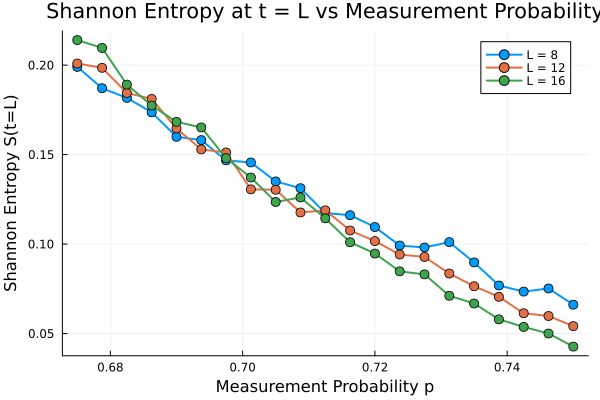

Plot saved as ShannonEntropy_at_t_equals_L_Summary_p#c.pdf


In [14]:
using NPZ
using Statistics
using Plots
using Printf

# ==========================================
# CONFIGURATION
# ==========================================
data_dir = "/Users/dirac/Projects-Data/z3-data/z3-haar-shannon-data-Feb7" 

L_values = [8, 12, 16]
num_shots = 5000

# This range (0.5 to 1.0 with 21 steps) produces the step size 0.025
# Values: 0.5, 0.525, 0.55 ... 0.75 ... 1.0
p_values = range(0.675, 0.75, length=21) 

summary_data = Dict{Int, Tuple{Vector{Float64}, Vector{Float64}}}()

# ==========================================
# ANALYSIS LOOP
# ==========================================

for L in L_values
    println("\nProcessing System Size L = $L ...")
    
    # Filenames conform to T = 2.0 * L (e.g., L8->T16.0, L12->T24.0)
    T = 2.0 * L  
    dt = 1.0
    
    expected_length = Int(T / dt) + 1 
    target_index = L + 1
    
    se_at_t_equals_L = Float64[]
    
    for p in p_values
        # 1. Round to avoid machine epsilon errors (e.g. 0.6000000001)
        # 2. Convert to string to handle variable length (0.8 vs 0.625)
        #    string(0.8) -> "0.8"
        #    string(0.625) -> "0.625"
        #    string(1.0) -> "1.0"
        p_clean = round(p, digits=5)
        p_str = string(p_clean)
        
        accumulated_se = zeros(Float64, expected_length)
        count_valid = 0
        
        for s in 1:num_shots
            # Filename format: L12,T24.0,p0.8,s1554_se.npy
            fname = "L$(L),T$(T),p$(p_str),s$(s)_se.npy"
            fpath = joinpath(data_dir, fname)
            
            if isfile(fpath)
                try
                    traj = npzread(fpath)
                    
                    len = min(length(traj), length(accumulated_se))
                    accumulated_se[1:len] .+= traj[1:len]
                    count_valid += 1
                catch
                    # Skip corrupted
                end
            end
        end
        
        if count_valid > 0
            avg_traj = accumulated_se ./ count_valid
            
            if length(avg_traj) >= target_index
                val_at_L = avg_traj[target_index]
                push!(se_at_t_equals_L, val_at_L)
            else
                push!(se_at_t_equals_L, NaN)
            end
            print(".") 
        else
            # print("x") # Optional: mark missing data
            push!(se_at_t_equals_L, NaN)
        end
    end
    
    println(" Done.")
    summary_data[L] = (collect(p_values), se_at_t_equals_L)
end

# ==========================================
# SUMMARY PLOT
# ==========================================

println("\nGenerating Summary Plot...")

plt_summary = plot(
    title = "Shannon Entropy at t = L vs Measurement Probability",
    xlabel = "Measurement Probability p",
    ylabel = "Shannon Entropy S(t=L)",
    legend = :topright,
    grid = true,
    lw = 2
)

for L in sort(collect(keys(summary_data)))
    (p_vals, se_vals) = summary_data[L]
    
    # Filter out NaNs for cleaner plotting lines
    mask = .!isnan.(se_vals)
    
    plot!(plt_summary, p_vals[mask], se_vals[mask], 
        label = "L = $L", 
        marker = :circle, 
        markersize = 5,
        lw = 2
    )
end

display(plt_summary)
savefig(plt_summary, "ShannonEntropy_at_t_equals_L_Summary_p#c.pdf")
println("Plot saved as ShannonEntropy_at_t_equals_L_Summary_p#c.pdf")


Processing System Size L = 8 ...
..................... Done.

Processing System Size L = 12 ...
..................... Done.

Processing System Size L = 16 ...
..................... Done.

Generating Summary Plot...


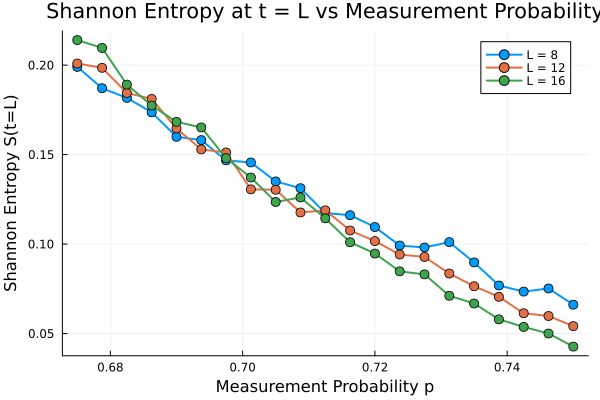

Plot saved as ShannonEntropy_at_t_equals_L_Summary_p#c.pdf


In [15]:
using NPZ
using Statistics
using Plots
using Printf

# ==========================================
# CONFIGURATION
# ==========================================
data_dir = "/Users/dirac/Projects-Data/z3-data/z3-haar-shannon-data-Feb7" 

L_values = [8, 12, 16]
num_shots = 5000

# This range (0.5 to 1.0 with 21 steps) produces the step size 0.025
# Values: 0.5, 0.525, 0.55 ... 0.75 ... 1.0
p_values = range(0.675, 0.75, length=21) 

summary_data = Dict{Int, Tuple{Vector{Float64}, Vector{Float64}}}()

# ==========================================
# ANALYSIS LOOP
# ==========================================

for L in L_values
    println("\nProcessing System Size L = $L ...")
    
    # Filenames conform to T = 2.0 * L (e.g., L8->T16.0, L12->T24.0)
    T = 2.0 * L  
    dt = 1.0
    
    expected_length = Int(T / dt) + 1 
    target_index = L + 1
    
    se_at_t_equals_L = Float64[]
    
    for p in p_values
        # 1. Round to avoid machine epsilon errors (e.g. 0.6000000001)
        # 2. Convert to string to handle variable length (0.8 vs 0.625)
        #    string(0.8) -> "0.8"
        #    string(0.625) -> "0.625"
        #    string(1.0) -> "1.0"
        p_clean = round(p, digits=6)
        p_str = string(p_clean)
        
        accumulated_se = zeros(Float64, expected_length)
        count_valid = 0
        
        for s in 1:num_shots
            # Filename format: L12,T24.0,p0.8,s1554_se.npy
            fname = "L$(L),T$(T),p$(p_str),s$(s)_se.npy"
            fpath = joinpath(data_dir, fname)
            
            if isfile(fpath)
                try
                    traj = npzread(fpath)
                    
                    len = min(length(traj), length(accumulated_se))
                    accumulated_se[1:len] .+= traj[1:len]
                    count_valid += 1
                catch
                    # Skip corrupted
                end
            end
        end
        
        if count_valid > 0
            avg_traj = accumulated_se ./ count_valid
            
            if length(avg_traj) >= target_index
                val_at_L = avg_traj[target_index]
                push!(se_at_t_equals_L, val_at_L)
            else
                push!(se_at_t_equals_L, NaN)
            end
            print(".") 
        else
            # print("x") # Optional: mark missing data
            push!(se_at_t_equals_L, NaN)
        end
    end
    
    println(" Done.")
    summary_data[L] = (collect(p_values), se_at_t_equals_L)
end

# ==========================================
# SUMMARY PLOT
# ==========================================

println("\nGenerating Summary Plot...")

plt_summary = plot(
    title = "Shannon Entropy at t = L vs Measurement Probability",
    xlabel = "Measurement Probability p",
    ylabel = "Shannon Entropy S(t=L)",
    legend = :topright,
    grid = true,
    lw = 2
)

for L in sort(collect(keys(summary_data)))
    (p_vals, se_vals) = summary_data[L]
    
    # Filter out NaNs for cleaner plotting lines
    mask = .!isnan.(se_vals)
    
    plot!(plt_summary, p_vals[mask], se_vals[mask], 
        label = "L = $L", 
        marker = :circle, 
        markersize = 5,
        lw = 2
    )
end

display(plt_summary)
savefig(plt_summary, "ShannonEntropy_at_t_equals_L_Summary_p#c.pdf")
println("Plot saved as ShannonEntropy_at_t_equals_L_Summary_p#c.pdf")

In [4]:
using NPZ
using Statistics
using Printf

# ==========================================
# CONFIGURATION
# ==========================================
data_dir = "/Users/dirac/Projects-Data/z3-data/z3-haar-shannon-data-Feb9" 

# Adjust these to match your actual data scope
L_values = [8, 12, 16]
num_shots = 5000

# p_values as per your previous loop range
p_values = range(0.6, 0.8, length=21) 

# We will store results in a matrix: Rows = L, Cols = p
# Initialize with zeros
results_matrix = zeros(Float64, length(L_values), length(p_values))

# ==========================================
# ANALYSIS LOOP
# ==========================================

# Use enumerate to get the row index 'i' for the matrix
for (i, L) in enumerate(L_values)
    println("\nProcessing System Size L = $L ...")
    
    T = 2.0 * L  
    dt = 1.0
    expected_length = Int(T / dt) + 1 
    target_index = L + 1
    
    # Use enumerate to get the column index 'j' for the matrix
    for (j, p) in enumerate(p_values)
        
        # Clean p string logic
        p_clean = round(p, digits=6)
        p_str = string(p_clean)
        
        accumulated_se = zeros(Float64, expected_length)
        count_valid = 0
        
        for s in 1:num_shots
            fname = "L$(L),T$(T),p$(p_str),s$(s)_se.npy"
            fpath = joinpath(data_dir, fname)
            
            if isfile(fpath)
                try
                    traj = npzread(fpath)
                    len = min(length(traj), length(accumulated_se))
                    accumulated_se[1:len] .+= traj[1:len]
                    count_valid += 1
                catch
                end
            end
        end
        
        if count_valid > 0
            avg_traj = accumulated_se ./ count_valid
            
            if length(avg_traj) >= target_index
                val_at_L = avg_traj[target_index]
                results_matrix[i, j] = val_at_L
            else
                results_matrix[i, j] = NaN
            end
            print(".") 
        else
            results_matrix[i, j] = NaN
        end
    end
    println(" Done.")
end

# ==========================================
# OUTPUT GENERATION (Copy-Paste Ready)
# ==========================================

println("\n" * "="^40)
println(" FINAL DATA ARRAYS ")
println("="^40 * "\n")

# Print I matrix (Formatted like Julia array of arrays or Matrix)
println("I = [")
for i in 1:size(results_matrix, 1)
    print("  [")
    for j in 1:size(results_matrix, 2)
        # Check for NaN and print 0.0 or actual value
        val = results_matrix[i, j]
        if isnan(val)
            print("NaN")
        else
            @printf("%.8f", val)
        end
        
        if j < size(results_matrix, 2)
            print(", ")
        end
    end
    if i < size(results_matrix, 1)
        println("],")
    else
        println("]")
    end
end
println("]")

# Print L_vals
print("\nL_vals = [")
for (i, L) in enumerate(L_values)
    print(L)
    if i < length(L_values) print(", ") end
end
println("]")

# Print p_vals
print("\np_vals = [")
for (i, p) in enumerate(p_values)
    @printf("%.4f", p)
    if i < length(p_values) print(", ") end
end
println("]")


Processing System Size L = 8 ...
..................... Done.

Processing System Size L = 12 ...
..................... Done.

Processing System Size L = 16 ...
..................... Done.

 FINAL DATA ARRAYS 

I = [
  [0.39727833, 0.35494803, 0.33376555, 0.30971645, 0.28376641, 0.25463785, 0.22599932, 0.20746392, 0.18816039, 0.15568492, 0.14104350, 0.12382293, 0.10472415, 0.09596702, 0.07350294, 0.06601059, 0.05393824, 0.04116271, 0.03627530, 0.02824620, 0.02376339],
  [0.43495591, 0.40283510, 0.36848296, 0.34785292, 0.30682680, 0.27271117, 0.24393800, 0.21863176, 0.18936838, 0.16484967, 0.14534488, 0.12278666, 0.10033754, 0.08441984, 0.06685594, 0.05518686, 0.04283644, 0.03080104, 0.02335733, 0.01700564, 0.01299823],
  [0.48409744, 0.46039369, 0.41551335, 0.37234773, 0.34335775, 0.29800154, 0.27414372, 0.22803540, 0.20049954, 0.16981194, 0.13862151, 0.11754960, 0.09472391, 0.07406619, 0.05526410, 0.04676487, 0.03237069, 0.02276139, 0.01718782, 0.01354879, 0.00667905]
]

L_vals = [8, 1

In [31]:
using NPZ
using Statistics
using Printf

# ==========================================
# CONFIGURATION
# ==========================================
data_dir = "/Users/dirac/Projects-Data/z3-data/z3-haar-shannon-data-Feb9" 

# Adjust these to match your actual data scope
L_values = [8, 12, 16]
num_shots = 5000

# p_values as per your previous loop range
p_values = range(0.6, 0.8, length=21) 

# We will store results in matrices: Rows = L, Cols = p
results_matrix = zeros(Float64, length(L_values), length(p_values))
errors_matrix  = zeros(Float64, length(L_values), length(p_values))

# ==========================================
# ANALYSIS LOOP
# ==========================================

# Use enumerate to get the row index 'i' for the matrix
for (i, L) in enumerate(L_values)
    println("\nProcessing System Size L = $L ...")
    
    T = 2.0 * L  
    dt = 1.0
    expected_length = Int(T / dt) + 1 
    target_index = L + 1
    
    # Use enumerate to get the column index 'j' for the matrix
    for (j, p) in enumerate(p_values)
        
        # Clean p string logic
        p_clean = round(p, digits=6)
        p_str = string(p_clean)
        
        # Array to collect the specific values at t=L across all valid shots
        target_values = Float64[]
        
        for s in 1:num_shots
            fname = "L$(L),T$(T),p$(p_str),s$(s)_se.npy"
            fpath = joinpath(data_dir, fname)
            
            if isfile(fpath)
                try
                    traj = npzread(fpath)
                    # Ensure the trajectory is long enough to have data at t=L
                    if length(traj) >= target_index
                        push!(target_values, traj[target_index])
                    end
                catch
                    # Silently skip corrupted/unreadable files
                end
            end
        end
        
        if length(target_values) > 1
            # Calculate mean and standard error of the mean (SEM)
            results_matrix[i, j] = mean(target_values)
            errors_matrix[i, j] = std(target_values) / sqrt(length(target_values))
            print(".") 
        elseif length(target_values) == 1
            # Fallback if only 1 shot exists (cannot compute standard deviation)
            results_matrix[i, j] = target_values[1]
            errors_matrix[i, j] = NaN 
            print(".")
        else
            results_matrix[i, j] = NaN
            errors_matrix[i, j] = NaN
            print("x") # Indicates missing data
        end
    end
    println(" Done.")
end

# ==========================================
# OUTPUT GENERATION (Copy-Paste Ready)
# ==========================================

println("\n" * "="^40)
println(" FINAL DATA ARRAYS ")
println("="^40 * "\n")

# Print I matrix (Means)
println("I = [")
for i in 1:size(results_matrix, 1)
    print("  [")
    for j in 1:size(results_matrix, 2)
        val = results_matrix[i, j]
        if isnan(val)
            print("NaN")
        else
            @printf("%.8f", val)
        end
        
        if j < size(results_matrix, 2)
            print(", ")
        end
    end
    if i < size(results_matrix, 1)
        println("],")
    else
        println("]")
    end
end
println("]\n")

# Print I_err matrix (Standard Errors)
println("I_err = [")
for i in 1:size(errors_matrix, 1)
    print("  [")
    for j in 1:size(errors_matrix, 2)
        val = errors_matrix[i, j]
        if isnan(val)
            print("NaN")
        else
            @printf("%.8f", val)
        end
        
        if j < size(errors_matrix, 2)
            print(", ")
        end
    end
    if i < size(errors_matrix, 1)
        println("],")
    else
        println("]")
    end
end
println("]")

# Print L_vals
print("\nL_vals = [")
for (i, L) in enumerate(L_values)
    print(L)
    if i < length(L_values) print(", ") end
end
println("]")

# Print p_vals
print("\np_vals = [")
for (i, p) in enumerate(p_values)
    @printf("%.4f", p)
    if i < length(p_values) print(", ") end
end
println("]")


Processing System Size L = 8 ...
..................... Done.

Processing System Size L = 12 ...
..................... Done.

Processing System Size L = 16 ...
..................... Done.

 FINAL DATA ARRAYS 

I = [
  [0.39727833, 0.35494803, 0.33376555, 0.30971645, 0.28376641, 0.25463785, 0.22599932, 0.20746392, 0.18816039, 0.15568492, 0.14104350, 0.12382293, 0.10472415, 0.09596702, 0.07350294, 0.06601059, 0.05393824, 0.04116271, 0.03627530, 0.02824620, 0.02376339],
  [0.43495591, 0.40283510, 0.36848296, 0.34785292, 0.30682680, 0.27271117, 0.24393800, 0.21863176, 0.18936838, 0.16484967, 0.14534488, 0.12278666, 0.10033754, 0.08441984, 0.06685594, 0.05518686, 0.04283644, 0.03080104, 0.02335733, 0.01700564, 0.01299823],
  [0.48409744, 0.46039369, 0.41551335, 0.37234773, 0.34335775, 0.29800154, 0.27414372, 0.22803540, 0.20049954, 0.16981194, 0.13862151, 0.11754960, 0.09472391, 0.07406619, 0.05526410, 0.04676487, 0.03237069, 0.02276139, 0.01718782, 0.01354879, 0.00667905]
]

I_err = [
  [0


Processing System Size L = 8 ...
..................... Done.

Processing System Size L = 12 ...
..................... Done.

Processing System Size L = 16 ...
..................... Done.

Generating Summary Plot...


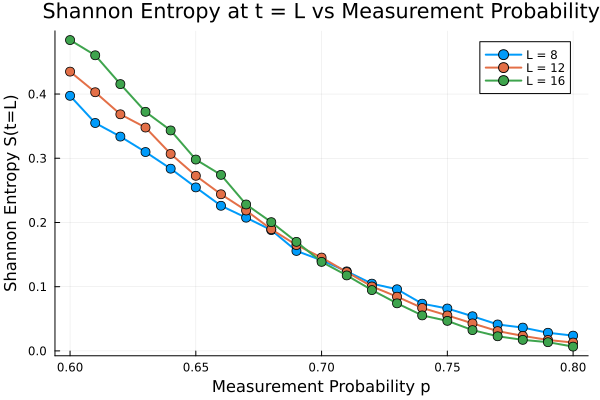

Plot saved as ShannonEntropy_at_t_equals_L_Summary_p#c.svg


In [3]:
using NPZ
using Statistics
using Plots
using Printf

# ==========================================
# CONFIGURATION
# ==========================================
data_dir = "/Users/dirac/Projects-Data/z3-data/z3-haar-shannon-data-Feb9" 

L_values = [8, 12, 16]
num_shots = 5000

# This range (0.5 to 1.0 with 21 steps) produces the step size 0.025
# Values: 0.5, 0.525, 0.55 ... 0.75 ... 1.0
p_values = range(0.6, 0.8, length=21) 

summary_data = Dict{Int, Tuple{Vector{Float64}, Vector{Float64}}}()

# ==========================================
# ANALYSIS LOOP
# ==========================================

for L in L_values
    println("\nProcessing System Size L = $L ...")
    
    # Filenames conform to T = 2.0 * L (e.g., L8->T16.0, L12->T24.0)
    T = 2.0 * L  
    dt = 1.0
    
    expected_length = Int(T / dt) + 1 
    target_index = L + 1
    
    se_at_t_equals_L = Float64[]
    
    for p in p_values
        # 1. Round to avoid machine epsilon errors (e.g. 0.6000000001)
        # 2. Convert to string to handle variable length (0.8 vs 0.625)
        #    string(0.8) -> "0.8"
        #    string(0.625) -> "0.625"
        #    string(1.0) -> "1.0"
        p_clean = round(p, digits=6)
        p_str = string(p_clean)
        
        accumulated_se = zeros(Float64, expected_length)
        count_valid = 0
        
        for s in 1:num_shots
            # Filename format: L12,T24.0,p0.8,s1554_se.npy
            fname = "L$(L),T$(T),p$(p_str),s$(s)_se.npy"
            fpath = joinpath(data_dir, fname)
            
            if isfile(fpath)
                try
                    traj = npzread(fpath)
                    
                    len = min(length(traj), length(accumulated_se))
                    accumulated_se[1:len] .+= traj[1:len]
                    count_valid += 1
                catch
                    # Skip corrupted
                end
            end
        end
        
        if count_valid > 0
            avg_traj = accumulated_se ./ count_valid
            
            if length(avg_traj) >= target_index
                val_at_L = avg_traj[target_index]
                push!(se_at_t_equals_L, val_at_L)
            else
                push!(se_at_t_equals_L, NaN)
            end
            print(".") 
        else
            # print("x") # Optional: mark missing data
            push!(se_at_t_equals_L, NaN)
        end
    end
    
    println(" Done.")
    summary_data[L] = (collect(p_values), se_at_t_equals_L)
end

# ==========================================
# SUMMARY PLOT
# ==========================================

println("\nGenerating Summary Plot...")

plt_summary = plot(
    title = "Shannon Entropy at t = L vs Measurement Probability",
    xlabel = "Measurement Probability p",
    ylabel = "Shannon Entropy S(t=L)",
    legend = :topright,
    grid = true,
    lw = 2
)

for L in sort(collect(keys(summary_data)))
    (p_vals, se_vals) = summary_data[L]
    
    # Filter out NaNs for cleaner plotting lines
    mask = .!isnan.(se_vals)
    
    plot!(plt_summary, p_vals[mask], se_vals[mask], 
        label = "L = $L", 
        marker = :circle, 
        markersize = 5,
        lw = 2
    )
end

display(plt_summary)
savefig(plt_summary, "ShannonEntropy_at_t_equals_L_Summary_p#c.svg")
println("Plot saved as ShannonEntropy_at_t_equals_L_Summary_p#c.svg")


Processing System Size L = 8 ...
.  Warning: No data found for L=8, p=0.910
.  Warning: No data found for L=8, p=0.920
.  Warning: No data found for L=8, p=0.930
.  Warning: No data found for L=8, p=0.940
.  Warning: No data found for L=8, p=0.950
.  Warning: No data found for L=8, p=0.960
.  Warning: No data found for L=8, p=0.970
.  Warning: No data found for L=8, p=0.980
.  Warning: No data found for L=8, p=0.990
.  Warning: No data found for L=8, p=1.000
 Done.

Processing System Size L = 12 ...
.  Warning: No data found for L=12, p=0.910
.  Warning: No data found for L=12, p=0.920
.  Warning: No data found for L=12, p=0.930
.  Warning: No data found for L=12, p=0.940
.  Warning: No data found for L=12, p=0.950
.  Warning: No data found for L=12, p=0.960
.  Warning: No data found for L=12, p=0.970
.  Warning: No data found for L=12, p=0.980
.  Warning: No data found for L=12, p=0.990
.  Warning: No data found for L=12, p=1.000
 Done.

Generating Summary Plot (Final TMI vs p)...


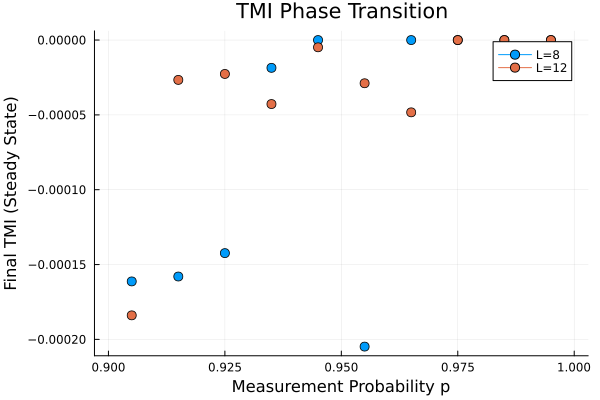

All plots saved.


In [2]:
using NPZ
using Statistics
using Plots
using Printf

# ==========================================
# CONFIGURATION
# ==========================================
# Path to your data
data_dir = "/Users/dirac/Projects-Data/z3-data/z3-haar-tmi-data-Feb17"

L_values = [8, 12]
num_shots = 5000
p_values = range(0.9, 1.0, length=21) # 0.0, 0.1, ... 1.0

# Storage for the final summary plot: Dict(L => (p_vals, final_tmi_vals))
summary_data = Dict{Int, Tuple{Vector{Float64}, Vector{Float64}}}()

# ==========================================
# ANALYSIS LOOP
# ==========================================

for L in L_values
    println("\nProcessing System Size L = $L ...")
    
    T = 10.0 * L
    dt = 1.0
    time_steps = Int(T / dt) + 1 # +1 because it includes t=0
    
    # Prepare Plot 1: TMI(t) vs t for this specific L
    plt_time = plot(
        title = "TMI Dynamics (L=$L)",
        xlabel = "Time (t)",
        ylabel = "Tripartite Mutual Info (I3)",
        legend = :outertopright,
        size = (800, 500),
        margin = 5Plots.mm
    )
    
    # Storage for this L to later plot Final TMI vs p
    final_values_for_L = Float64[]
    
    for p in p_values
        p_str = @sprintf("%.3f", p)
        
        # Accumulator for averaging
        # We assume the time series length is consistent (T/dt + 1)
        accumulated_tmi = zeros(Float64, time_steps)
        count_valid = 0
        
        # --- Load 5000 Shots ---
        for s in 1:num_shots
            # Filename format: L8,T80.0,p0.0,s11_tmi.npy
            fname = "L$(L),T$(T),p$(p_str),s$(s)_tmi.npy"
            fpath = joinpath(data_dir, fname)
            
            if isfile(fpath)
                try
                    traj = npzread(fpath)
                    
                    # Ensure trajectory length matches accumulator
                    if length(traj) == length(accumulated_tmi)
                        accumulated_tmi .+= traj
                        count_valid += 1
                    elseif length(traj) > length(accumulated_tmi)
                        # Handle case where file might be slightly longer/shorter
                        len = min(length(traj), length(accumulated_tmi))
                        accumulated_tmi[1:len] .+= traj[1:len]
                        count_valid += 1
                    end
                catch e
                    # Ignore corrupted files
                end
            end
        end
        
        if count_valid > 0
            avg_tmi = accumulated_tmi ./ count_valid
            
            # 1. Add to Time Series Plot (Plot lines for subset of p to avoid clutter)
            # Plotting all 11 lines might be messy, but we plot them all as requested
            plot!(plt_time, 0:dt:T, -avg_tmi, label="p=$(p_str)", lw=2, alpha=0.8)
            
            # 2. Extract Final Value (at t=T)
            # We take the mean of the last few steps to smooth out fluctuations if needed, 
            # or just the absolute last point. Here we take the last point.
            push!(final_values_for_L, avg_tmi[end])
            
            print(".") # Progress dot
        else
            println("  Warning: No data found for L=$L, p=$p_str")
            push!(final_values_for_L, NaN)
        end
    end
    
    println(" Done.")
    
    # Save the Time Series plot for this L
    savefig(plt_time, "TMI_TimeEvolution_L$(L)_pc.pdf")
    
    # Store data for the final phase transition plot
    summary_data[L] = (collect(p_values), final_values_for_L)
end

# ==========================================
# FINAL SUMMARY PLOT (TMI_final vs p)
# ==========================================

println("\nGenerating Summary Plot (Final TMI vs p)...")

plt_summary = plot(
    title = "TMI Phase Transition",
    xlabel = "Measurement Probability p",
    ylabel = "Final TMI (Steady State)",
    legend = :topright,
    marker = :circle,
    lw = 2
)

# Iterate over sorted L values to keep legend ordered
for L in sort(keys(summary_data) |> collect)
    (p_vals, finals) = summary_data[L]
    plot!(plt_summary, p_vals, finals, label="L=$L", marker=:circle, markersize=5)
end

display(plt_summary)
savefig(plt_summary, "TMI_PhaseTransition_Summary_pc.pdf")
println("All plots saved.")


Processing System Size L = 8 ...

.
.
.
.
.
.
.
.
.
.
 Done.

Processing System Size L = 12 ...

.
.
.
.
.
.
.
.
.
.
 Done.

Generating Summary Plot (Final TMI vs p)...


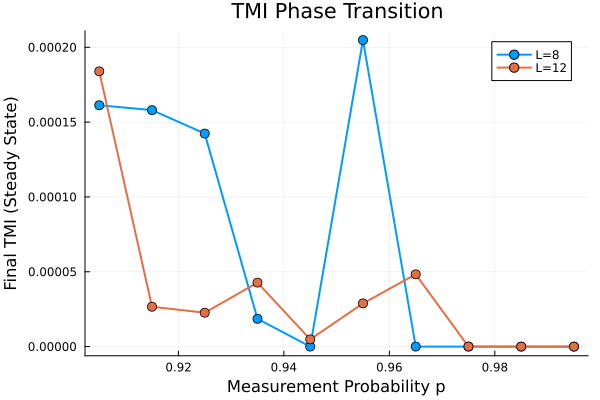

All plots saved.


In [3]:
using NPZ
using Statistics
using Plots
using Printf

# ==========================================
# CONFIGURATION
# ==========================================
data_dir = "/Users/dirac/Projects-Data/z3-data/z3-haar-tmi-data-Feb17"

L_values = [8, 12]
num_shots = 5000
# Convert range to array
p_values = collect(range(0.9, 1.0, length=21)) 

# Storage for the final summary plot: Dict(L => (clean_p_vals, final_tmi_vals))
summary_data = Dict{Int, Tuple{Vector{Float64}, Vector{Float64}}}()

# ==========================================
# ANALYSIS LOOP
# ==========================================

for L in L_values
    println("\nProcessing System Size L = $L ...")
    
    T = 10.0 * L
    dt = 1.0
    
    # Prepare Plot 1: TMI(t) vs t
    plt_time = plot(
        title = "TMI Dynamics (L=$L)",
        xlabel = "Time (t)",
        ylabel = "Tripartite Mutual Info (I3)",
        legend = :outertopright,
        size = (800, 500),
        margin = 5Plots.mm
    )
    
    final_values_for_L = Float64[]
    clean_p_vals_for_L = Float64[]
    
    for p in p_values
        # 1. Enforce strict %.3f string formatting for the filename
        p_str = @sprintf("%.3f", p)
        
        # 2. Parse back to a float to keep the plot's x-axis perfectly clean
        p_clean = parse(Float64, p_str)
        
        accumulated_tmi = Float64[]
        count_valid = 0
        
        # --- Load Shots ---
        for s in 1:num_shots
            # Expected filename: L8,T80.0,p0.905,s1_tmi.npy
            fname = "L$(L),T$(T),p$(p_str),s$(s)_tmi.npy"
            fpath = joinpath(data_dir, fname)
            
            if isfile(fpath)
                try
                    traj = npzread(fpath)
                    
                    # Dynamically initialize accumulator length based on first valid file
                    if isempty(accumulated_tmi)
                        accumulated_tmi = zeros(Float64, length(traj))
                    end
                    
                    if length(traj) == length(accumulated_tmi)
                        accumulated_tmi .+= traj
                        count_valid += 1
                    else
                        # Safely truncate if file length mismatch occurs
                        len = min(length(traj), length(accumulated_tmi))
                        accumulated_tmi[1:len] .+= traj[1:len]
                        count_valid += 1
                    end
                catch
                    # Ignore corrupted files silently
                end
            end
        end
        
        if count_valid > 0
            avg_tmi = accumulated_tmi ./ count_valid
            
            # Plot negated time evolution
            plot!(plt_time, 0:dt:(length(avg_tmi)-1)*dt, -avg_tmi, label="p=$(p_str)", lw=2, alpha=0.8)
            
            # Extract final value
            push!(final_values_for_L, avg_tmi[end])
            push!(clean_p_vals_for_L, p_clean)
            print(".") 
        else
            println("\n  Warning: No data found for L=$L, p=$p_str")
        end
    end
    
    println(" Done.")
    
    savefig(plt_time, "TMI_TimeEvolution_L$(L)_pc.pdf")
    
    # Store clean arrays for the summary plot
    summary_data[L] = (clean_p_vals_for_L, final_values_for_L)
end

# ==========================================
# FINAL SUMMARY PLOT
# ==========================================

println("\nGenerating Summary Plot (Final TMI vs p)...")

plt_summary = plot(
    title = "TMI Phase Transition",
    xlabel = "Measurement Probability p",
    ylabel = "Final TMI (Steady State)",
    legend = :topright,
    grid = true
)

for L in sort(collect(keys(summary_data)))
    (p_vals, finals) = summary_data[L]
    
    # NOTE: I negated 'finals' here to match your negated time-evolution plot.
    # Remove the negative sign if you want the raw signed values.
    plot!(plt_summary, p_vals, -finals, label="L=$L", marker=:circle, markersize=5, lw=2)
end

display(plt_summary)
savefig(plt_summary, "TMI_PhaseTransition_Summary_pc.pdf")
println("All plots saved.")


Processing System Size L = 8 ...
..................... Done.

Processing System Size L = 12 ...
..................... Done.

Generating Summary Plot (Final Entropy vs p)...


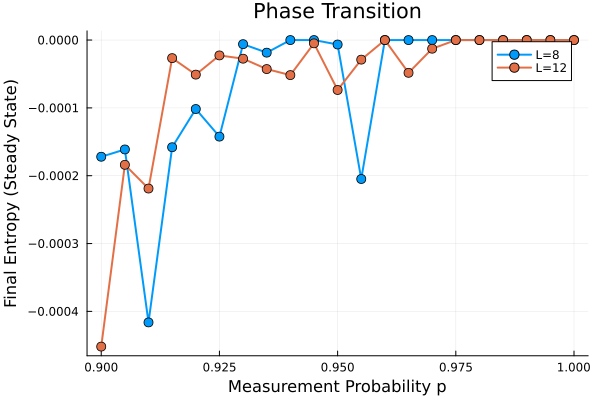

All plots saved.


In [5]:
using NPZ
using Statistics
using Plots
using Printf

# ==========================================
# CONFIGURATION
# ==========================================
data_dir = "/Users/dirac/Projects-Data/z3-data/z3-haar-tmi-data-Feb17"

L_values = [8, 12]
num_shots = 5000
p_values = collect(range(0.9, 1.0, length=21)) 

# Storage for the final summary plot: Dict(L => (clean_p_vals, final_vals))
summary_data = Dict{Int, Tuple{Vector{Float64}, Vector{Float64}}}()

# ==========================================
# ANALYSIS LOOP
# ==========================================

for L in L_values
    println("\nProcessing System Size L = $L ...")
    
    T = 10.0 * L
    dt = 1.0
    expected_length = Int(T / dt) + 1 # +1 to include t=0
    
    # Prepare Plot 1: Dynamics vs t
    plt_time = plot(
        title = "Entropy Dynamics (L=$L)",
        xlabel = "Time (t)",
        ylabel = "Entropy",
        legend = :outertopright,
        size = (800, 500),
        margin = 5Plots.mm
    )
    
    final_values_for_L = Float64[]
    clean_p_vals_for_L = Float64[]
    
    for p in p_values
        # 1. Round to avoid machine epsilon errors (e.g. 0.6000000001)
        # 2. Convert to string to handle variable length (0.8 vs 0.625)
        p_clean = round(p, digits=3)
        p_str = string(p_clean)
        
        accumulated_se = zeros(Float64, expected_length)
        count_valid = 0
        
        # --- Load Shots ---
        for s in 1:num_shots
            # Filename format: L12,T24.0,p0.8,s1554_se.npy
            fname = "L$(L),T$(T),p$(p_str),s$(s)_tmi.npy"
            fpath = joinpath(data_dir, fname)
            
            if isfile(fpath)
                try
                    traj = npzread(fpath)
                    
                    len = min(length(traj), length(accumulated_se))
                    accumulated_se[1:len] .+= traj[1:len]
                    count_valid += 1
                catch
                    # Skip corrupted
                end
            end
        end
        
        if count_valid > 0
            avg_se = accumulated_se ./ count_valid
            
            # Plot time evolution
            plot!(plt_time, 0:dt:(length(avg_se)-1)*dt, avg_se, label="p=$(p_str)", lw=2, alpha=0.8)
            
            # Extract final value
            push!(final_values_for_L, avg_se[end])
            push!(clean_p_vals_for_L, p_clean)
            print(".") 
        else
            println("\n  Warning: No data found for L=$L, p=$p_str")
        end
    end
    
    println(" Done.")
    
    savefig(plt_time, "Entropy_TimeEvolution_L$(L)_pc.pdf")
    
    # Store clean arrays for the summary plot
    summary_data[L] = (clean_p_vals_for_L, final_values_for_L)
end

# ==========================================
# FINAL SUMMARY PLOT
# ==========================================

println("\nGenerating Summary Plot (Final Entropy vs p)...")

plt_summary = plot(
    title = "Phase Transition",
    xlabel = "Measurement Probability p",
    ylabel = "Final Entropy (Steady State)",
    legend = :topright,
    grid = true
)

for L in sort(collect(keys(summary_data)))
    (p_vals, finals) = summary_data[L]
    
    plot!(plt_summary, p_vals, finals, label="L=$L", marker=:circle, markersize=5, lw=2)
end

display(plt_summary)
savefig(plt_summary, "PhaseTransition_Summary_pc.pdf")
println("All plots saved.")


Processing System Size L = 8 ...
..................... Done.

Processing System Size L = 12 ...
..................... Done.

Processing System Size L = 16 ...
..................... Done.

Generating Summary Plot (Ancilla Entropy at t=L vs p)...


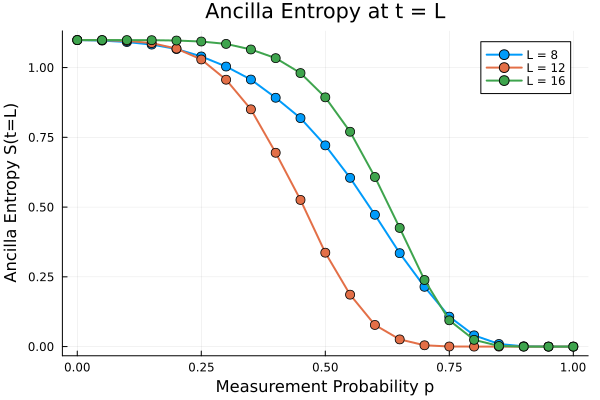

Plot saved as AncillaEntropy_at_t_equals_L_Summary.pdf


In [ ]:
using NPZ
using Statistics
using Plots
using Printf

# ==========================================
# CONFIGURATION
# ==========================================
# Update this to the folder where your Shannon Entropy data is stored
data_dir = "/Users/dirac/Projects-Data/z3-data/z3-haar-anc-data-Feb19" 


L_values = [8, 12, 16]
num_shots = 5000

# Explicitly step by 0.05 to hit 0.5, 0.55, 0.6, etc.
p_values = collect(0.0:0.05:1.0) 

# Storage for the summary: Dict(L => (clean_p_vals, se_at_L_vals))
summary_data = Dict{Int, Tuple{Vector{Float64}, Vector{Float64}}}()

# ==========================================
# ANALYSIS LOOP
# ==========================================

for L in L_values
    println("\nProcessing System Size L = $L ...")
    
    T = 1.0 * L  
    dt = 1.0
    
    # We expect data for t = 0, 1, ..., T
    expected_length = Int(2*T / dt) + 1 
    
    # We want to extract the value at time t = L
    target_index = 2L + 1
    
    # Storage for this specific L
    se_at_t_equals_L = Float64[]
    clean_p_vals_for_L = Float64[]
    
    for p in p_values
        # 1. Round to avoid machine epsilon errors (e.g., 0.5500000000001)
        # 2. string() naturally formats 0.5 as "0.5" and 0.55 as "0.55"
        p_clean = round(p, digits=6)
        p_str = string(p_clean)
        
        # Accumulator for averaging
        accumulated_se = zeros(Float64, expected_length)
        count_valid = 0
        
        # --- Load 5000 Shots ---
        for s in 1:num_shots
            # Expected filename format: L12,T12.0,p0.55,s1_a.npy
            fname = "L$(L),T$(T),p$(p_str),s$(s)_a.npy"
            fpath = joinpath(data_dir, fname)
            
            if isfile(fpath)
                try
                    traj = npzread(fpath)
                    
                    # Handle slight length mismatches
                    len = min(length(traj), length(accumulated_se))
                    accumulated_se[1:len] .+= traj[1:len]
                    count_valid += 1
                catch e
                    # Skip corrupted files
                end
            end
        end
        
        if count_valid > 0
            avg_traj = accumulated_se ./ count_valid
            
            # --- EXTRACT VALUE AT t = L ---
            if length(avg_traj) >= target_index
                val_at_L = avg_traj[target_index]
                push!(se_at_t_equals_L, val_at_L)
                push!(clean_p_vals_for_L, p_clean)
            else
                println("\n  Error: Trajectory too short to find t=L for p=$p_str")
            end
            
            print(".") 
        else
            println("\n  Warning: No data found for L=$L, p=$p_str")
        end
    end
    
    println(" Done.")
    
    # Store data for the summary plot
    summary_data[L] = (clean_p_vals_for_L, se_at_t_equals_L)
end

# ==========================================
# SUMMARY PLOT (Shannon Entropy(t=L) vs p)
# ==========================================

println("\nGenerating Summary Plot (Ancilla Entropy at t=L vs p)...")

plt_summary = plot(
    title = "Ancilla Entropy at t = L",
    xlabel = "Measurement Probability p",
    ylabel = "Ancilla Entropy S(t=L)",
    legend = :topright,
    grid = true
)

# Sort L values so the legend is clean
for L in sort(collect(keys(summary_data)))
    (p_vals, se_vals) = summary_data[L]
    
    plot!(plt_summary, p_vals, se_vals, 
        label = "L = $L", 
        marker = :circle, 
        markersize = 5,
        lw = 2
    )
end

display(plt_summary)
savefig(plt_summary, "AncillaEntropy_at_t_equals_L_Summary.pdf")
println("Plot saved as AncillaEntropy_at_t_equals_L_Summary.pdf")

In [11]:
using NPZ

In [12]:
npzread("/Users/dirac/Projects-Data/z3-data/z3-haar-anc-data-Feb19/L12,T12.0,p0.05,s3490_a.npy")

25-element Vector{Float64}:
 1.0986122886681096
 1.0986122886681098
 1.0986122886681096
 1.0986122886681098
 1.0986122886681098
 1.0986122886681096
 1.0986122886681098
 1.0986122886681098
 1.0986122886681096
 1.0986122886681098
 1.0986122886681098
 1.0986122886681098
 1.0986122886681098
 1.0985712863271364
 1.0985712863271364
 1.098462028442746
 1.0983085929669512
 1.098299706853089
 1.0982997068530889
 1.0982328081749428
 1.0980872940302706
 1.097952158371505
 1.097952158371505
 1.097952158371505
 1.097952158371505


Processing System Size L = 8 ...
..................... Done.

Processing System Size L = 10 ...
..................... Done.

Processing System Size L = 16 ...
..................... Done.

Generating Summary Plot (Ancilla Entropy at t=L vs p)...


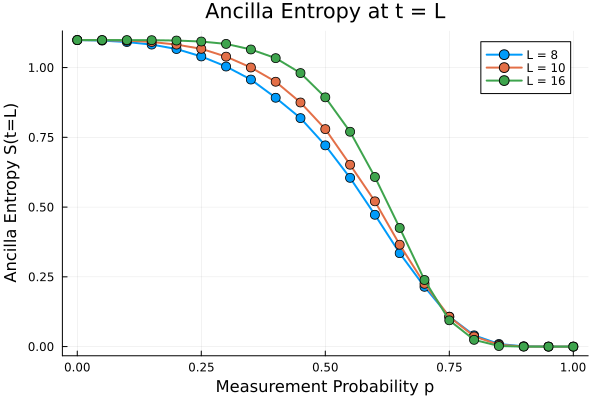

Plot saved as AncillaEntropy_at_t_equals_L10_Summary.pdf


In [16]:
using NPZ
using Statistics
using Plots
using Printf

# ==========================================
# CONFIGURATION
# ==========================================
# Update this to the folder where your Shannon Entropy data is stored
data_dir = "/Users/dirac/Projects-Data/z3-data/z3-haar-anc-data-Feb19" 


L_values = [8, 10, 16]
num_shots = 5000

# Explicitly step by 0.05 to hit 0.5, 0.55, 0.6, etc.
p_values = collect(0.0:0.05:1.0) 

# Storage for the summary: Dict(L => (clean_p_vals, se_at_L_vals))
summary_data = Dict{Int, Tuple{Vector{Float64}, Vector{Float64}}}()

# ==========================================
# ANALYSIS LOOP
# ==========================================

for L in L_values
    println("\nProcessing System Size L = $L ...")
    
    T = 1.0 * L  
    dt = 1.0
    
    # We expect data for t = 0, 1, ..., T
    expected_length = Int(2*T / dt) + 1 
    
    # We want to extract the value at time t = L
    target_index = 2L + 1
    
    # Storage for this specific L
    se_at_t_equals_L = Float64[]
    clean_p_vals_for_L = Float64[]
    
    for p in p_values
        # 1. Round to avoid machine epsilon errors (e.g., 0.5500000000001)
        # 2. string() naturally formats 0.5 as "0.5" and 0.55 as "0.55"
        p_clean = round(p, digits=6)
        p_str = string(p_clean)
        
        # Accumulator for averaging
        accumulated_se = zeros(Float64, expected_length)
        count_valid = 0
        
        # --- Load 5000 Shots ---
        for s in 1:num_shots
            # Expected filename format: L12,T12.0,p0.55,s1_a.npy
            fname = "L$(L),T$(T),p$(p_str),s$(s)_a.npy"
            fpath = joinpath(data_dir, fname)
            
            if isfile(fpath)
                try
                    traj = npzread(fpath)
                    
                    # Handle slight length mismatches
                    len = min(length(traj), length(accumulated_se))
                    accumulated_se[1:len] .+= traj[1:len]
                    count_valid += 1
                catch e
                    # Skip corrupted files
                end
            end
        end
        
        if count_valid > 0
            avg_traj = accumulated_se ./ count_valid
            
            # --- EXTRACT VALUE AT t = L ---
            if length(avg_traj) >= target_index
                val_at_L = avg_traj[target_index]
                push!(se_at_t_equals_L, val_at_L)
                push!(clean_p_vals_for_L, p_clean)
            else
                println("\n  Error: Trajectory too short to find t=L for p=$p_str")
            end
            
            print(".") 
        else
            println("\n  Warning: No data found for L=$L, p=$p_str")
        end
    end
    
    println(" Done.")
    
    # Store data for the summary plot
    summary_data[L] = (clean_p_vals_for_L, se_at_t_equals_L)
end

# ==========================================
# SUMMARY PLOT (Shannon Entropy(t=L) vs p)
# ==========================================

println("\nGenerating Summary Plot (Ancilla Entropy at t=L vs p)...")

plt_summary = plot(
    title = "Ancilla Entropy at t = L",
    xlabel = "Measurement Probability p",
    ylabel = "Ancilla Entropy S(t=L)",
    legend = :topright,
    grid = true
)

# Sort L values so the legend is clean
for L in sort(collect(keys(summary_data)))
    (p_vals, se_vals) = summary_data[L]
    
    plot!(plt_summary, p_vals, se_vals, 
        label = "L = $L", 
        marker = :circle, 
        markersize = 5,
        lw = 2
    )
end

display(plt_summary)
savefig(plt_summary, "AncillaEntropy_at_t_equals_L10_Summary.pdf")
println("Plot saved as AncillaEntropy_at_t_equals_L10_Summary.pdf")


Processing System Size L = 8 ...
..................... Done.

Processing System Size L = 10 ...
..................... Done.

Processing System Size L = 14 ...
..................... Done.

Processing System Size L = 16 ...
..................... Done.

Generating Summary Plot...


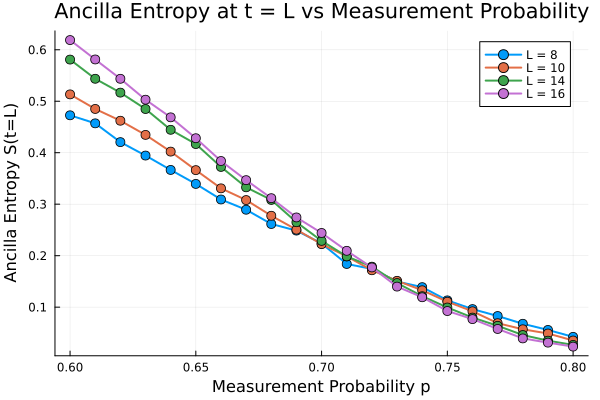

Plot saved as Ancilla_at_t_equals_L_Summary_p#c.pdf


In [21]:
using NPZ
using Statistics
using Plots
using Printf

# ==========================================
# CONFIGURATION
# ==========================================
data_dir = "/Users/dirac/Projects-Data/z3-data/z3-haar-anc-data-Feb22" 

L_values = [8, 10, 14, 16]
num_shots = 5000

# This range (0.5 to 1.0 with 21 steps) produces the step size 0.025
# Values: 0.5, 0.525, 0.55 ... 0.75 ... 1.0
p_values = range(0.6, 0.8, length=21) 

summary_data = Dict{Int, Tuple{Vector{Float64}, Vector{Float64}}}()

# ==========================================
# ANALYSIS LOOP
# ==========================================

for L in L_values
    println("\nProcessing System Size L = $L ...")
    
    # Filenames conform to T = 2.0 * L (e.g., L8->T16.0, L12->T24.0)
    T = 1.0 * L  
    dt = 1.0
    
    expected_length = Int(2 * T / dt) + 1 
    target_index = 2*L + 1
    
    se_at_t_equals_L = Float64[]
    
    for p in p_values
        # 1. Round to avoid machine epsilon errors (e.g. 0.6000000001)
        # 2. Convert to string to handle variable length (0.8 vs 0.625)
        #    string(0.8) -> "0.8"
        #    string(0.625) -> "0.625"
        #    string(1.0) -> "1.0"
        p_clean = round(p, digits=4)
        p_str = string(p_clean)
        
        accumulated_se = zeros(Float64, expected_length)
        count_valid = 0
        
        for s in 1:num_shots
            # Filename format: L12,T24.0,p0.8,s1554_se.npy
            fname = "L$(L),T$(T),p$(p_str),s$(s)_a.npy"
            fpath = joinpath(data_dir, fname)
            
            if isfile(fpath)
                try
                    traj = npzread(fpath)
                    
                    len = min(length(traj), length(accumulated_se))
                    accumulated_se[1:len] .+= traj[1:len]
                    count_valid += 1
                catch
                    # Skip corrupted
                end
            end
        end
        
        if count_valid > 0
            avg_traj = accumulated_se ./ count_valid
            
            if length(avg_traj) >= target_index
                val_at_L = avg_traj[target_index]
                push!(se_at_t_equals_L, val_at_L)
            else
                push!(se_at_t_equals_L, NaN)
            end
            print(".") 
        else
            # print("x") # Optional: mark missing data
            push!(se_at_t_equals_L, NaN)
        end
    end
    
    println(" Done.")
    summary_data[L] = (collect(p_values), se_at_t_equals_L)
end

# ==========================================
# SUMMARY PLOT
# ==========================================

println("\nGenerating Summary Plot...")

plt_summary = plot(
    title = "Ancilla Entropy at t = L vs Measurement Probability",
    xlabel = "Measurement Probability p",
    ylabel = "Ancilla Entropy S(t=L)",
    legend = :topright,
    grid = true,
    lw = 2
)

for L in sort(collect(keys(summary_data)))
    (p_vals, se_vals) = summary_data[L]
    
    # Filter out NaNs for cleaner plotting lines
    mask = .!isnan.(se_vals)
    
    plot!(plt_summary, p_vals[mask], se_vals[mask], 
        label = "L = $L", 
        marker = :circle, 
        markersize = 5,
        lw = 2
    )
end

display(plt_summary)
savefig(plt_summary, "Ancilla_at_t_equals_L_Summary_p#c.pdf")
println("Plot saved as Ancilla_at_t_equals_L_Summary_p#c.pdf")

In [23]:
using NPZ
using Statistics
using Printf

# ==========================================
# CONFIGURATION
# ==========================================
data_dir = "/Users/dirac/Projects-Data/z3-data/z3-haar-anc-data-Feb22" 

# Adjust these to match your actual data scope
L_values = [8, 10, 14, 16]
num_shots = 5000

# p_values as per your previous loop range
p_values = range(0.6, 0.8, length=21) 

# We will store results in a matrix: Rows = L, Cols = p
# Initialize with zeros
results_matrix = zeros(Float64, length(L_values), length(p_values))

# ==========================================
# ANALYSIS LOOP
# ==========================================

# Use enumerate to get the row index 'i' for the matrix
for (i, L) in enumerate(L_values)
    println("\nProcessing System Size L = $L ...")
    
    T = 1.0 * L  
    dt = 1.0
    expected_length = Int(2*T / dt) + 1 
    target_index = 2*L + 1
    
    # Use enumerate to get the column index 'j' for the matrix
    for (j, p) in enumerate(p_values)
        
        # Clean p string logic
        p_clean = round(p, digits=6)
        p_str = string(p_clean)
        
        accumulated_se = zeros(Float64, expected_length)
        count_valid = 0
        
        for s in 1:num_shots
            fname = "L$(L),T$(T),p$(p_str),s$(s)_a.npy"
            fpath = joinpath(data_dir, fname)
            
            if isfile(fpath)
                try
                    traj = npzread(fpath)
                    len = min(length(traj), length(accumulated_se))
                    accumulated_se[1:len] .+= traj[1:len]
                    count_valid += 1
                catch
                end
            end
        end
        
        if count_valid > 0
            avg_traj = accumulated_se ./ count_valid
            
            if length(avg_traj) >= target_index
                val_at_L = avg_traj[target_index]
                results_matrix[i, j] = val_at_L
            else
                results_matrix[i, j] = NaN
            end
            print(".") 
        else
            results_matrix[i, j] = NaN
        end
    end
    println(" Done.")
end

# ==========================================
# OUTPUT GENERATION (Copy-Paste Ready)
# ==========================================

println("\n" * "="^40)
println(" FINAL DATA ARRAYS ")
println("="^40 * "\n")

# Print I matrix (Formatted like Julia array of arrays or Matrix)
println("I = [")
for i in 1:size(results_matrix, 1)
    print("  [")
    for j in 1:size(results_matrix, 2)
        # Check for NaN and print 0.0 or actual value
        val = results_matrix[i, j]
        if isnan(val)
            print("NaN")
        else
            @printf("%.8f", val)
        end
        
        if j < size(results_matrix, 2)
            print(", ")
        end
    end
    if i < size(results_matrix, 1)
        println("],")
    else
        println("]")
    end
end
println("]")

# Print L_vals
print("\nL_vals = [")
for (i, L) in enumerate(L_values)
    print(L)
    if i < length(L_values) print(", ") end
end
println("]")

# Print p_vals
print("\np_vals = [")
for (i, p) in enumerate(p_values)
    @printf("%.4f", p)
    if i < length(p_values) print(", ") end
end
println("]")


Processing System Size L = 8 ...
..................... Done.

Processing System Size L = 10 ...
..................... Done.

Processing System Size L = 14 ...
..................... Done.

Processing System Size L = 16 ...
..................... Done.

 FINAL DATA ARRAYS 

I = [
  [0.47272052, 0.45709961, 0.42061836, 0.39449844, 0.36657171, 0.33941230, 0.30915257, 0.28926354, 0.26156947, 0.24872486, 0.22373216, 0.18392582, 0.17425364, 0.14975918, 0.13884135, 0.11313961, 0.09619301, 0.08271585, 0.06769134, 0.05566542, 0.04224949],
  [0.51335852, 0.48506632, 0.46218727, 0.43465974, 0.40218527, 0.36621345, 0.33080373, 0.30803733, 0.27753577, 0.25051298, 0.22242001, 0.19862573, 0.17165053, 0.15115141, 0.13276600, 0.11056451, 0.09190832, 0.06883347, 0.05698003, 0.04878565, 0.03517854],
  [0.58097621, 0.54369145, 0.51675602, 0.48496060, 0.44455601, 0.41692131, 0.37242618, 0.33280644, 0.30833698, 0.26500756, 0.22875532, 0.19856375, 0.17865096, 0.14685354, 0.12126342, 0.09930834, 0.07971391, 0.

In [ ]:
I = [
  [0.47272052, 0.45709961, 0.42061836, 0.39449844, 0.36657171, 0.33941230, 0.30915257, 0.28926354, 0.26156947, 0.24872486, 0.22373216, 0.18392582, 0.17425364, 0.14975918, 0.13884135, 0.11313961, 0.09619301, 0.08271585, 0.06769134, 0.05566542, 0.04224949],
  [0.51335852, 0.48506632, 0.46218727, 0.43465974, 0.40218527, 0.36621345, 0.33080373, 0.30803733, 0.27753577, 0.25051298, 0.22242001, 0.19862573, 0.17165053, 0.15115141, 0.13276600, 0.11056451, 0.09190832, 0.06883347, 0.05698003, 0.04878565, 0.03517854],
  [0.58097621, 0.54369145, 0.51675602, 0.48496060, 0.44455601, 0.41692131, 0.37242618, 0.33280644, 0.30833698, 0.26500756, 0.22875532, 0.19856375, 0.17865096, 0.14685354, 0.12126342, 0.09930834, 0.07971391, 0.06374015, 0.04580508, 0.03488379, 0.02658237],
  [0.61889009, 0.58121401, 0.54364810, 0.50301779, 0.46874761, 0.42817926, 0.38390499, 0.34673520, 0.31169629, 0.27427955, 0.24408551, 0.20941571, 0.17714256, 0.13992604, 0.11920161, 0.09246968, 0.07676980, 0.05761488, 0.03925387, 0.03105143, 0.02334297]
]

L_vals = [8, 10, 14, 16]

p_vals = [0.6000, 0.6100, 0.6200, 0.6300, 0.6400, 0.6500, 0.6600, 0.6700, 0.6800, 0.6900, 0.7000, 0.7100, 0.7200, 0.7300, 0.7400, 0.7500, 0.7600, 0.7700, 0.7800, 0.7900, 0.8000]


Processing System Size L = 8 ...
..................... Done.

Processing System Size L = 10 ...
..................... Done.

Processing System Size L = 12 ...
..................... Done.

Processing System Size L = 14 ...
..................... Done.

Processing System Size L = 16 ...
..................... Done.

Generating Summary Plot...


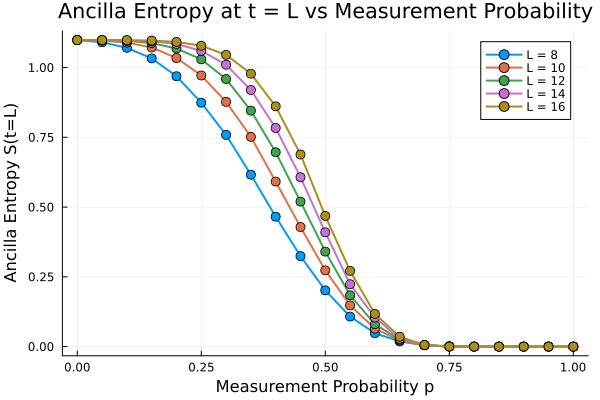

Plot saved as Ancilla_at_t_equals_L_Summary_pm.pdf


In [2]:
using NPZ
using Statistics
using Plots
using Printf

# ==========================================
# CONFIGURATION
# ==========================================
data_dir = "/Users/dirac/Projects-Data/z3-data/z3-haar-anc-data-Mar1" 

L_values = [8, 10, 12, 14, 16]
num_shots = 5000

# This range (0.5 to 1.0 with 21 steps) produces the step size 0.025
# Values: 0.5, 0.525, 0.55 ... 0.75 ... 1.0
p_values = range(0.0, 1.0, length=21) 

summary_data = Dict{Int, Tuple{Vector{Float64}, Vector{Float64}}}()

# ==========================================
# ANALYSIS LOOP
# ==========================================

for L in L_values
    println("\nProcessing System Size L = $L ...")
    
    # Filenames conform to T = 2.0 * L (e.g., L8->T16.0, L12->T24.0)
    T = 1.0 * L  
    dt = 1.0
    
    expected_length = Int(2 * T / dt) + 1 
    target_index = 2*L + 1
    
    se_at_t_equals_L = Float64[]
    
    for p in p_values
        # 1. Round to avoid machine epsilon errors (e.g. 0.6000000001)
        # 2. Convert to string to handle variable length (0.8 vs 0.625)
        #    string(0.8) -> "0.8"
        #    string(0.625) -> "0.625"
        #    string(1.0) -> "1.0"
        p_clean = round(p, digits=4)
        p_str = string(p_clean)
        
        accumulated_se = zeros(Float64, expected_length)
        count_valid = 0
        
        for s in 1:num_shots
            # Filename format: L12,T24.0,p0.8,s1554_se.npy
            fname = "L$(L),T$(T),p$(p_str),s$(s)_a.npy"
            fpath = joinpath(data_dir, fname)
            
            if isfile(fpath)
                try
                    traj = npzread(fpath)
                    
                    len = min(length(traj), length(accumulated_se))
                    accumulated_se[1:len] .+= traj[1:len]
                    count_valid += 1
                catch
                    # Skip corrupted
                end
            end
        end
        
        if count_valid > 0
            avg_traj = accumulated_se ./ count_valid
            
            if length(avg_traj) >= target_index
                val_at_L = avg_traj[target_index]
                push!(se_at_t_equals_L, val_at_L)
            else
                push!(se_at_t_equals_L, NaN)
            end
            print(".") 
        else
            # print("x") # Optional: mark missing data
            push!(se_at_t_equals_L, NaN)
        end
    end
    
    println(" Done.")
    summary_data[L] = (collect(p_values), se_at_t_equals_L)
end

# ==========================================
# SUMMARY PLOT
# ==========================================

println("\nGenerating Summary Plot...")

plt_summary = plot(
    title = "Ancilla Entropy at t = L vs Measurement Probability",
    xlabel = "Measurement Probability p",
    ylabel = "Ancilla Entropy S(t=L)",
    legend = :topright,
    grid = true,
    lw = 2
)

for L in sort(collect(keys(summary_data)))
    (p_vals, se_vals) = summary_data[L]
    
    # Filter out NaNs for cleaner plotting lines
    mask = .!isnan.(se_vals)
    
    plot!(plt_summary, p_vals[mask], se_vals[mask], 
        label = "L = $L", 
        marker = :circle, 
        markersize = 5,
        lw = 2
    )
end

display(plt_summary)
savefig(plt_summary, "Ancilla_at_t_equals_L_Summary_pm.pdf")
println("Plot saved as Ancilla_at_t_equals_L_Summary_pm.pdf")


Processing System Size L = 8 ...
............................... Done.

Processing System Size L = 10 ...
............................... Done.

Processing System Size L = 12 ...
............................... Done.

Processing System Size L = 14 ...
 Done.

Processing System Size L = 16 ...
............................... Done.

Generating Summary Plot...


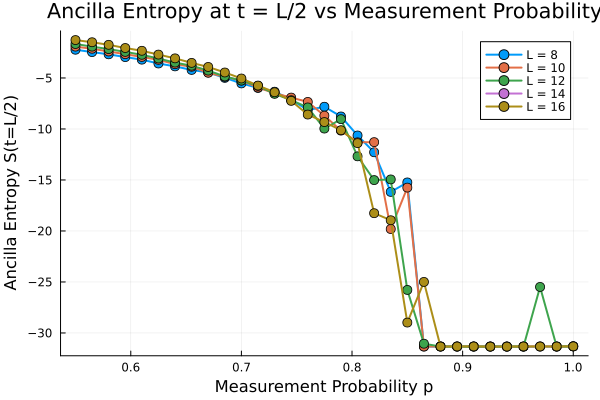

Plot saved as Ancilla_at_t_equals_L_Summary_pm_pc_log.pdf


In [5]:
using NPZ
using Statistics
using Plots
using Printf

# ==========================================
# CONFIGURATION
# ==========================================
data_dir = "/Users/dirac/Projects-Data/z3-data/z3-haar-anc-data-Mar9" 

L_values = [8, 10, 12, 14, 16]
num_shots = 5000

# This range (0.5 to 1.0 with 21 steps) produces the step size 0.025
# Values: 0.5, 0.525, 0.55 ... 0.75 ... 1.0
p_values = range(0.55, 1.0, length=31) 

summary_data = Dict{Int, Tuple{Vector{Float64}, Vector{Float64}}}()

# ==========================================
# ANALYSIS LOOP
# ==========================================

for L in L_values
    println("\nProcessing System Size L = $L ...")
    
    # Filenames conform to T = 2.0 * L (e.g., L8->T16.0, L12->T24.0)
    T = 1.0 * L  
    dt = 1.0
    
    expected_length = Int(2 * T / dt) + 1 
    target_index = 2*L + 1
    
    se_at_t_equals_L = Float64[]
    
    for p in p_values
        # 1. Round to avoid machine epsilon errors (e.g. 0.6000000001)
        # 2. Convert to string to handle variable length (0.8 vs 0.625)
        #    string(0.8) -> "0.8"
        #    string(0.625) -> "0.625"
        #    string(1.0) -> "1.0"
        p_clean = round(p, digits=4)
        p_str = string(p_clean)
        
        accumulated_se = zeros(Float64, expected_length)
        count_valid = 0
        
        for s in 1:num_shots
            # Filename format: L12,T24.0,p0.8,s1554_se.npy
            fname = "L$(L),T$(T),p$(p_str),s$(s)_a.npy"
            fpath = joinpath(data_dir, fname)
            
            if isfile(fpath)
                try
                    traj = npzread(fpath)
                    
                    len = min(length(traj), length(accumulated_se))
                    accumulated_se[1:len] .+= traj[1:len]
                    count_valid += 1
                catch
                    # Skip corrupted
                end
            end
        end
        
        if count_valid > 0
            avg_traj = accumulated_se ./ count_valid
            
            if length(avg_traj) >= target_index
                val_at_L = avg_traj[target_index]
                push!(se_at_t_equals_L, val_at_L)
            else
                push!(se_at_t_equals_L, NaN)
            end
            print(".") 
        else
            # print("x") # Optional: mark missing data
            push!(se_at_t_equals_L, NaN)
        end
    end
    
    println(" Done.")
    summary_data[L] = (collect(p_values), se_at_t_equals_L)
end

# ==========================================
# SUMMARY PLOT
# ==========================================

println("\nGenerating Summary Plot...")

plt_summary = plot(
    title = "Ancilla Entropy at t = L/2 vs Measurement Probability",
    xlabel = "Measurement Probability p",
    ylabel = "Ancilla Entropy S(t=L/2)",
    legend = :topright,
    grid = true,
    lw = 2
)

for L in sort(collect(keys(summary_data)))
    (p_vals, se_vals) = summary_data[L]
    
    # Filter out NaNs for cleaner plotting lines
    mask = .!isnan.(se_vals)

    # stop the y-axis at -10 to visually separate from the original plot    
    #ylims!(plt_summary, -10, maximum(se_vals[mask]) * 1.1)
    
    plot!(plt_summary, p_vals[mask], log.(se_vals[mask]) , 
        label = "L = $L", 
        marker = :circle, 
        markersize = 5,
        lw = 2
    )
end


display(plt_summary)
savefig(plt_summary, "Ancilla_at_t_equals_L_Summary_pm_pc_log.pdf")
println("Plot saved as Ancilla_at_t_equals_L_Summary_pm_pc_log.pdf")


Processing System Size L = 8 ...
............................... Done.

Processing System Size L = 10 ...
............................... Done.

Processing System Size L = 12 ...
............................... Done.

Processing System Size L = 14 ...
 Done.

Processing System Size L = 16 ...
............................... Done.

Generating Summary Plot...


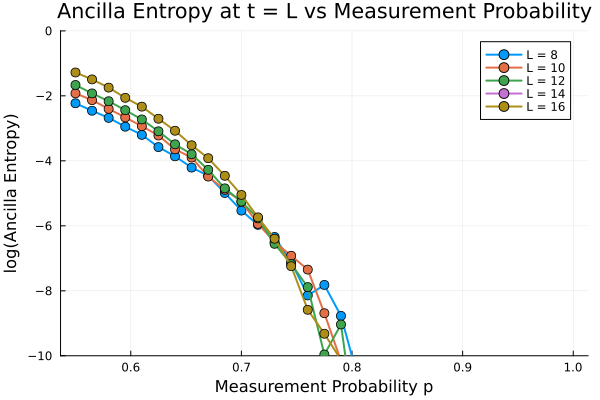

Plot saved as Ancilla_at_t_equals_L_Summary_pm_pc_log_-10.pdf


In [8]:
using NPZ
using Statistics
using Plots
using Printf

# ==========================================
# CONFIGURATION
# ==========================================
data_dir = "/Users/dirac/Projects-Data/z3-data/z3-haar-anc-data-Mar9" 

L_values = [8, 10, 12, 14, 16]
num_shots = 5000

# Range of measurement probabilities
p_values = range(0.55, 1.0, length=31) 

summary_data = Dict{Int, Tuple{Vector{Float64}, Vector{Float64}}}()

# ==========================================
# ANALYSIS LOOP
# ==========================================

for L in L_values
    println("\nProcessing System Size L = $L ...")
    
    # Filenames conform to T = 1.0 * L 
    T = 1.0 * L  
    dt = 1.0
    
    expected_length = Int(2 * T / dt) + 1 
    target_index = 2*L + 1
    
    se_at_t_equals_L = Float64[]
    
    for p in p_values
        # Round and convert to string for robust filename matching
        p_clean = round(p, digits=4)
        p_str = string(p_clean)
        
        accumulated_se = zeros(Float64, expected_length)
        count_valid = 0
        
        for s in 1:num_shots
            # Filename format: L12,T12.0,p0.8,s1554_a.npy
            fname = "L$(L),T$(T),p$(p_str),s$(s)_a.npy"
            fpath = joinpath(data_dir, fname)
            
            if isfile(fpath)
                try
                    traj = npzread(fpath)
                    
                    len = min(length(traj), length(accumulated_se))
                    accumulated_se[1:len] .+= traj[1:len]
                    count_valid += 1
                catch
                    # Skip corrupted files
                end
            end
        end
        
        if count_valid > 0
            avg_traj = accumulated_se ./ count_valid
            
            if length(avg_traj) >= target_index
                val_at_L = avg_traj[target_index]
                push!(se_at_t_equals_L, val_at_L)
            else
                push!(se_at_t_equals_L, NaN)
            end
            print(".") 
        else
            push!(se_at_t_equals_L, NaN)
        end
    end
    
    println(" Done.")
    summary_data[L] = (collect(p_values), se_at_t_equals_L)
end

# ==========================================
# SUMMARY PLOT
# ==========================================

println("\nGenerating Summary Plot...")

plt_summary = plot(
    title = "Ancilla Entropy at t = L vs Measurement Probability",
    xlabel = "Measurement Probability p",
    ylabel = "log(Ancilla Entropy)",
    legend = :topright,
    grid = true,
    lw = 2
)

# Constrain the y-axis from -10 to 0
ylims!(plt_summary, -10, 0)

for L in sort(collect(keys(summary_data)))
    (p_vals, se_vals) = summary_data[L]
    
    # Mask out NaNs and ensure values are positive before taking the log
    mask = .!isnan.(se_vals) .& (se_vals .> 0)
    
    plot!(plt_summary, p_vals[mask], log.(se_vals[mask]), 
        label = "L = $L", 
        marker = :circle, 
        markersize = 5,
        lw = 2
    )
end

display(plt_summary)
savefig(plt_summary, "Ancilla_at_t_equals_L_Summary_pm_pc_log_-10.pdf")
println("Plot saved as Ancilla_at_t_equals_L_Summary_pm_pc_log_-10.pdf")


Processing System Size L = 8 ...
.................. Done.

Processing System Size L = 10 ...
.................. Done.

Processing System Size L = 12 ...
.................. Done.

Processing System Size L = 16 ...
.................. Done.

Generating Summary Plot...


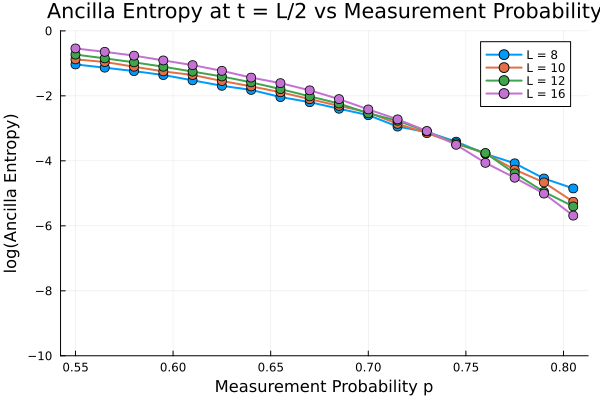

In [ ]:
using NPZ
using Statistics
using Plots
using Printf

# ==========================================
# CONFIGURATION
# ==========================================
data_dir = "/Users/dirac/Projects-Data/z3-data/z3-haar-anc-data-Mar9" 

L_values = [8, 10, 12, 16]
num_shots = 5000

# Range of measurement probabilities
p_valuess = range(0.55, 1.0, length=31) 
p_values = p_valuess[1:18]

summary_data = Dict{Int, Tuple{Vector{Float64}, Vector{Float64}}}()

# ==========================================
# ANALYSIS LOOP
# ==========================================

for L in L_values
    println("\nProcessing System Size L = $L ...")
    
    T = 1.0 * L  
    dt = 1.0
    
    # Ensure expected_length covers 1.5*L
    # If T = L, then 2T = 2L, which is plenty for 1.5L.
    expected_length = Int(2 * T / dt) + 1 
    
    # UPDATED: Target index for t = 3L/2
    # For t = 1.5 * L, the index is (1.5 * L / dt) + 1
    target_index = Int(1.5 * L) + 1
    
    se_at_target_t = Float64[]
    
    for p in p_values
        p_clean = round(p, digits=4)
        p_str = string(p_clean)
        
        accumulated_se = zeros(Float64, expected_length)
        count_valid = 0
        
        for s in 1:num_shots
            fname = "L$(L),T$(T),p$(p_str),s$(s)_a.npy"
            fpath = joinpath(data_dir, fname)
            
            if isfile(fpath)
                try
                    traj = npzread(fpath)
                    len = min(length(traj), length(accumulated_se))
                    accumulated_se[1:len] .+= traj[1:len]
                    count_valid += 1
                catch
                end
            end
        end
        
        if count_valid > 0
            avg_traj = accumulated_se ./ count_valid
            
            # Check if the trajectory is long enough for 1.5L
            if length(avg_traj) >= target_index
                val_at_t = avg_traj[target_index]
                push!(se_at_target_t, val_at_t)
            else
                push!(se_at_target_t, NaN)
            end
            print(".") 
        else
            push!(se_at_target_t, NaN)
        end
    end
    
    println(" Done.")
    summary_data[L] = (collect(p_values), se_at_target_t)
end

# ==========================================
# SUMMARY PLOT
# ==========================================

println("\nGenerating Summary Plot...")

plt_summary = plot(
    title = "Ancilla Entropy at t = L/2 vs Measurement Probability",
    xlabel = "Measurement Probability p",
    ylabel = "log(Ancilla Entropy)",
    legend = :topright,
    grid = true,
    lw = 2
)

ylims!(plt_summary, -10, 0)
#xlims!(plt_summary, 0.55, 0.8)

for L in sort(collect(keys(summary_data)))
    (p_vals, se_vals) = summary_data[L]
    
    mask = .!isnan.(se_vals) .& (se_vals .> 0)
    
    plot!(plt_summary, p_vals[mask], log.(se_vals[mask]), 
        label = "L = $L", 
        marker = :circle, 
        markersize = 5,
        lw = 2
    )
end

#print the data points as an array for copy-paste

display(plt_summary)
#savefig(plt_summary, "Ancilla_at_t_1.5L_Summary.pdf")
#println("Plot saved as Ancilla_at_t_1.5L_Summary.pdf")

In [13]:
using NPZ
using Statistics
using Printf

# ==========================================
# CONFIGURATION
# ==========================================
data_dir = "/Users/dirac/Projects-Data/z3-data/z3-haar-anc-data-Mar9" 

# Adjust these to match your actual data scope
L_values = [8, 10, 12, 16]
num_shots = 5000

# p_values as per your previous loop range
p_valuess = range(0.55, 1.0, length=31) 
p_values = p_valuess[9:18]

# We will store results in a matrix: Rows = L, Cols = p
# Initialize with zeros
results_matrix = zeros(Float64, length(L_values), length(p_values))

# ==========================================
# ANALYSIS LOOP
# ==========================================

# Use enumerate to get the row index 'i' for the matrix
for (i, L) in enumerate(L_values)
    println("\nProcessing System Size L = $L ...")
    
    T = 1.0 * L  
    dt = 1.0
    expected_length = Int(2*T / dt) + 1 
    target_index = Int(1.5 * L) + 1
    
    # Use enumerate to get the column index 'j' for the matrix
    for (j, p) in enumerate(p_values)
        
        # Clean p string logic
        p_clean = round(p, digits=6)
        p_str = string(p_clean)
        
        accumulated_se = zeros(Float64, expected_length)
        count_valid = 0
        
        for s in 1:num_shots
            fname = "L$(L),T$(T),p$(p_str),s$(s)_a.npy"
            fpath = joinpath(data_dir, fname)
            
            if isfile(fpath)
                try
                    traj = npzread(fpath)
                    len = min(length(traj), length(accumulated_se))
                    accumulated_se[1:len] .+= traj[1:len]
                    count_valid += 1
                catch
                end
            end
        end
        
        if count_valid > 0
            avg_traj = accumulated_se ./ count_valid
            
            if length(avg_traj) >= target_index
                val_at_L = avg_traj[target_index]
                results_matrix[i, j] = val_at_L
            else
                results_matrix[i, j] = NaN
            end
            print(".") 
        else
            results_matrix[i, j] = NaN
        end
    end
    println(" Done.")
end

# ==========================================
# OUTPUT GENERATION (Copy-Paste Ready)
# ==========================================

println("\n" * "="^40)
println(" FINAL DATA ARRAYS ")
println("="^40 * "\n")

# Print I matrix (Formatted like Julia array of arrays or Matrix)
println("I = [")
for i in 1:size(results_matrix, 1)
    print("  [")
    for j in 1:size(results_matrix, 2)
        # Check for NaN and print 0.0 or actual value
        val = results_matrix[i, j]
        if isnan(val)
            print("NaN")
        else
            @printf("%.8f", val)
        end
        
        if j < size(results_matrix, 2)
            print(", ")
        end
    end
    if i < size(results_matrix, 1)
        println("],")
    else
        println("]")
    end
end
println("]")

# Print L_vals
print("\nL_vals = [")
for (i, L) in enumerate(L_values)
    print(L)
    if i < length(L_values) print(", ") end
end
println("]")

# Print p_vals
print("\np_vals = [")
for (i, p) in enumerate(p_values)
    @printf("%.4f", p)
    if i < length(p_values) print(", ") end
end
println("]")


Processing System Size L = 8 ...
.......... Done.

Processing System Size L = 10 ...
.......... Done.

Processing System Size L = 12 ...
.......... Done.

Processing System Size L = 16 ...
.......... Done.

 FINAL DATA ARRAYS 

I = [
  [0.11144962, 0.09105889, 0.07470708, 0.05257670, 0.04439913, 0.03305288, 0.02267454, 0.01696959, 0.01063809, 0.00783101],
  [0.12224324, 0.09939305, 0.08135278, 0.05718967, 0.04303219, 0.03105910, 0.02296556, 0.01398207, 0.00942158, 0.00519375],
  [0.13318816, 0.10687529, 0.07905396, 0.06290993, 0.04524659, 0.03138528, 0.02332132, 0.01244171, 0.00705414, 0.00450254],
  [0.16041492, 0.12249505, 0.08908962, 0.06563581, 0.04588399, 0.03001178, 0.01721734, 0.01089536, 0.00668518, 0.00339574]
]

L_vals = [8, 10, 12, 16]

p_vals = [0.6700, 0.6850, 0.7000, 0.7150, 0.7300, 0.7450, 0.7600, 0.7750, 0.7900, 0.8050]


In [32]:
using NPZ
using Statistics
using Printf

# ==========================================
# CONFIGURATION
# ==========================================
data_dir = "/Users/dirac/Projects-Data/z3-data/z3-haar-anc-data-Mar9" 

# Adjust these to match your actual data scope
L_values = [8, 10, 12, 16]
num_shots = 5000

# p_values as per your previous loop range
p_valuess = range(0.55, 1.0, length=31) 
p_values = p_valuess[9:18]

# We will store results in matrices: Rows = L, Cols = p
results_matrix = zeros(Float64, length(L_values), length(p_values))
errors_matrix  = zeros(Float64, length(L_values), length(p_values))

# ==========================================
# ANALYSIS LOOP
# ==========================================

# Use enumerate to get the row index 'i' for the matrix
for (i, L) in enumerate(L_values)
    println("\nProcessing System Size L = $L ...")
    
    T = 1.0 * L  
    dt = 1.0
    target_index = Int(1.5 * L) + 1
    
    # Use enumerate to get the column index 'j' for the matrix
    for (j, p) in enumerate(p_values)
        
        # Clean p string logic
        p_clean = round(p, digits=6)
        p_str = string(p_clean)
        
        # Array to collect the specific values at the target index across all valid shots
        target_values = Float64[]
        
        for s in 1:num_shots
            fname = "L$(L),T$(T),p$(p_str),s$(s)_a.npy"
            fpath = joinpath(data_dir, fname)
            
            if isfile(fpath)
                try
                    traj = npzread(fpath)
                    # Ensure the trajectory is long enough to have data at our target
                    if length(traj) >= target_index
                        push!(target_values, traj[target_index])
                    end
                catch
                    # Silently skip corrupted files
                end
            end
        end
        
        if length(target_values) > 1
            # Calculate mean and standard error of the mean (SEM)
            results_matrix[i, j] = mean(target_values)
            errors_matrix[i, j] = std(target_values) / sqrt(length(target_values))
            print(".") 
        elseif length(target_values) == 1
            # Fallback if only 1 shot exists
            results_matrix[i, j] = target_values[1]
            errors_matrix[i, j] = NaN 
            print(".")
        else
            results_matrix[i, j] = NaN
            errors_matrix[i, j] = NaN
            print("x")
        end
    end
    println(" Done.")
end

# ==========================================
# OUTPUT GENERATION (Copy-Paste Ready)
# ==========================================

println("\n" * "="^40)
println(" FINAL DATA ARRAYS ")
println("="^40 * "\n")

# Print I matrix (Means)
println("I = [")
for i in 1:size(results_matrix, 1)
    print("  [")
    for j in 1:size(results_matrix, 2)
        val = results_matrix[i, j]
        if isnan(val)
            print("NaN")
        else
            @printf("%.8f", val)
        end
        
        if j < size(results_matrix, 2)
            print(", ")
        end
    end
    if i < size(results_matrix, 1)
        println("],")
    else
        println("]")
    end
end
println("]\n")

# Print I_err matrix (Standard Errors)
println("I_err = [")
for i in 1:size(errors_matrix, 1)
    print("  [")
    for j in 1:size(errors_matrix, 2)
        val = errors_matrix[i, j]
        if isnan(val)
            print("NaN")
        else
            @printf("%.8f", val)
        end
        
        if j < size(errors_matrix, 2)
            print(", ")
        end
    end
    if i < size(errors_matrix, 1)
        println("],")
    else
        println("]")
    end
end
println("]")

# Print L_vals
print("\nL_vals = [")
for (i, L) in enumerate(L_values)
    print(L)
    if i < length(L_values) print(", ") end
end
println("]")

# Print p_vals
print("\np_vals = [")
for (i, p) in enumerate(p_values)
    @printf("%.4f", p)
    if i < length(p_values) print(", ") end
end
println("]")


Processing System Size L = 8 ...
.......... Done.

Processing System Size L = 10 ...
.......... Done.

Processing System Size L = 12 ...
.......... Done.

Processing System Size L = 16 ...
.......... Done.

 FINAL DATA ARRAYS 

I = [
  [0.11144962, 0.09105889, 0.07470708, 0.05257670, 0.04439913, 0.03305288, 0.02267454, 0.01696959, 0.01063809, 0.00783101],
  [0.12224324, 0.09939305, 0.08135278, 0.05718967, 0.04303219, 0.03105910, 0.02296556, 0.01398207, 0.00942158, 0.00519375],
  [0.13318816, 0.10687529, 0.07905396, 0.06290993, 0.04524659, 0.03138528, 0.02332132, 0.01244171, 0.00705414, 0.00450254],
  [0.16041492, 0.12249505, 0.08908962, 0.06563581, 0.04588399, 0.03001178, 0.01721734, 0.01089536, 0.00668518, 0.00339574]
]

I_err = [
  [0.00281496, 0.00256759, 0.00236672, 0.00195654, 0.00180655, 0.00152662, 0.00128948, 0.00107463, 0.00083356, 0.00074041],
  [0.00281895, 0.00253148, 0.00229891, 0.00196109, 0.00164495, 0.00140799, 0.00118941, 0.00086086, 0.00071384, 0.00051862],
  [0.0028

In [12]:
p_values[9:18]

0.67:0.015:0.805

In [15]:
using NPZ
using Statistics
using Plots
using Printf

# ==========================================
# CONFIGURATION
# ==========================================
data_dir = "/Users/dirac/Projects-Data/z3-data/z3-haar-anc-data-Mar9" 

L_values = [8, 10, 12, 14, 16]
num_shots = 5000
# Full range of available p
p_values = range(0.55, 1.0, length=31) 

# Filtered range for plotting
p_min, p_max = 0.55, 1.0

# ==========================================
# ANALYSIS & TIME EVOLUTION PLOTTING
# ==========================================

for L in L_values
    println("\nProcessing System Size L = $L ...")
    
    T = 1.0 * L  
    dt = 1.0
    
    # Indices for the t = T to 2T window
    start_idx = Int(T / dt) + 1
    end_idx   = Int(2 * T / dt) + 1
    
    time_axis = T:dt:(2*T)
    plot_len = length(time_axis)

    plt_time_ev = plot(
        title = "Ancilla Entropy (L = $L, t: T → 2T)",
        xlabel = "Time t",
        ylabel = "Ancilla Entropy S(t)",
        legend = :outerright,
        grid = true,
        thickness_scaling = 1.1 # Makes labels slightly easier to read
    )
    
    # Only iterate over p in the specified range [0.6, 0.8]
    for p in p_values
        if p < p_min || p > p_max
            continue
        end

        p_clean = round(p, digits=4)
        p_str = string(p_clean)
        
        trajs_matrix = fill(NaN, plot_len, num_shots)
        count_valid = 0
        
        for s in 1:num_shots
            fname = "L$(L),T$(T),p$(p_str),s$(s)_a.npy"
            fpath = joinpath(data_dir, fname)
            
            if isfile(fpath)
                try
                    traj = npzread(fpath)
                    if length(traj) >= end_idx
                        trajs_matrix[:, s] = traj[start_idx:end_idx]
                        count_valid += 1
                    end
                catch
                    # Ignore corrupted files
                end
            end
        end
        
        if count_valid > 1
            avg_traj = Float64[]
            sem_traj = Float64[]
            
            for i in 1:plot_len
                row = filter(!isnan, trajs_matrix[i, :])
                if !isempty(row)
                    push!(avg_traj, mean(row))
                    push!(sem_traj, std(row) / sqrt(length(row)))
                end
            end
            
            plot!(plt_time_ev, time_axis[1:length(avg_traj)], log.(avg_traj), 
                  ribbon = sem_traj,
                  fillalpha = 0.25,
                  label = "p = $p_clean",
                  lw = 2.0)
            print(".") 
        end
    end
    
    output_name = "Ancilla_Evolution_L$(L)_p0.55-1.0_log.pdf"
    savefig(plt_time_ev, output_name)
    println("\nSaved: $output_name")
end

println("\nFiltering complete. Only p ∈ [$p_min, $p_max] plotted.")


Processing System Size L = 8 ...
...............................
Saved: Ancilla_Evolution_L8_p0.55-1.0_log.pdf

Processing System Size L = 10 ...
...............................
Saved: Ancilla_Evolution_L10_p0.55-1.0_log.pdf

Processing System Size L = 12 ...
...............................
Saved: Ancilla_Evolution_L12_p0.55-1.0_log.pdf

Processing System Size L = 14 ...

Saved: Ancilla_Evolution_L14_p0.55-1.0_log.pdf

Processing System Size L = 16 ...
...............................
Saved: Ancilla_Evolution_L16_p0.55-1.0_log.pdf

Filtering complete. Only p ∈ [0.55, 1.0] plotted.


In [14]:
using NPZ
using Statistics
using Plots
using Printf

# ==========================================
# CONFIGURATION
# ==========================================
data_dir = "/Users/dirac/Projects-Data/z3-data/z3-haar-anc-data-Feb22" 

L_values = [8, 10, 12, 14, 16]
num_shots = 5000
# Full range of available p
p_values = range(0.55, 1.0, length=31) 

# Filtered range for plotting
p_min, p_max = 0.6, 0.8

# ==========================================
# ANALYSIS & TIME EVOLUTION PLOTTING
# ==========================================

for L in L_values
    println("\nProcessing System Size L = $L ...")
    
    T = 1.0 * L  
    dt = 1.0
    
    # Indices for the t = T to 2T window
    start_idx = Int(T / dt) + 1
    end_idx   = Int(2 * T / dt) + 1
    
    time_axis = T:dt:(2*T)
    plot_len = length(time_axis)

    plt_time_ev = plot(
        title = "Ancilla Entropy (L = $L, t: T → 2T)",
        xlabel = "Time t",
        ylabel = "Ancilla Entropy S(t)",
        legend = :outerright,
        grid = true,
        thickness_scaling = 1.1 # Makes labels slightly easier to read
    )
    
    # Only iterate over p in the specified range [0.6, 0.8]
    for p in p_values
        if p < p_min || p > p_max
            continue
        end

        p_clean = round(p, digits=4)
        p_str = string(p_clean)
        
        trajs_matrix = fill(NaN, plot_len, num_shots)
        count_valid = 0
        
        for s in 1:num_shots
            fname = "L$(L),T$(T),p$(p_str),s$(s)_a.npy"
            fpath = joinpath(data_dir, fname)
            
            if isfile(fpath)
                try
                    traj = npzread(fpath)
                    if length(traj) >= end_idx
                        trajs_matrix[:, s] = traj[start_idx:end_idx]
                        count_valid += 1
                    end
                catch
                    # Ignore corrupted files
                end
            end
        end
        
        if count_valid > 1
            avg_traj = Float64[]
            sem_traj = Float64[]
            
            for i in 1:plot_len
                row = filter(!isnan, trajs_matrix[i, :])
                if !isempty(row)
                    push!(avg_traj, mean(row))
                    push!(sem_traj, std(row) / sqrt(length(row)))
                end
            end
            
            plot!(plt_time_ev, time_axis[1:length(avg_traj)], avg_traj, 
                  ribbon = sem_traj,
                  fillalpha = 0.25,
                  label = "p = $p_clean",
                  lw = 2.0)
            print(".") 
        end
    end
    
    output_name = "Ancilla_Evolution_L$(L)_p0.6-0.8_cs.pdf"
    savefig(plt_time_ev, output_name)
    println("\nSaved: $output_name")
end

println("\nFiltering complete. Only p ∈ [$p_min, $p_max] plotted.")


Processing System Size L = 8 ...
.......
Saved: Ancilla_Evolution_L8_p0.6-0.8_cs.pdf

Processing System Size L = 10 ...
.......
Saved: Ancilla_Evolution_L10_p0.6-0.8_cs.pdf

Processing System Size L = 12 ...

Saved: Ancilla_Evolution_L12_p0.6-0.8_cs.pdf

Processing System Size L = 14 ...
.......
Saved: Ancilla_Evolution_L14_p0.6-0.8_cs.pdf

Processing System Size L = 16 ...
.......
Saved: Ancilla_Evolution_L16_p0.6-0.8_cs.pdf

Filtering complete. Only p ∈ [0.6, 0.8] plotted.


In [10]:
using NPZ
using Statistics
using Plots
using Printf

# ==========================================
# CONFIGURATION
# ==========================================
data_dir = "/Users/dirac/Projects-Data/z3-data/z3-haar-anc-data-Mar9" 

L_values = [8, 10, 12, 14, 16]
num_shots = 5000
p_values = range(0.55, 1.0, length=31) 

# ==========================================
# ANALYSIS & TIME EVOLUTION PLOTTING
# ==========================================

for L in L_values
    println("\nProcessing System Size L = $L ...")
    
    T = 1.0 * L  
    dt = 1.0
    expected_length = Int(2 * T / dt) + 1 
    time_axis = 0:dt:(2*T)

    plt_time_ev = plot(
        title = "Ancilla Entropy Evolution (L = $L) with SEM",
        xlabel = "Time t",
        ylabel = "Ancilla Entropy S(t)",
        legend = :outerright,
        grid = true
    )
    
    for p in p_values
        p_clean = round(p, digits=4)
        p_str = string(p_clean)
        
        # Matrix to store all shots for this p: [time_step, shot_index]
        trajs_matrix = fill(NaN, expected_length, num_shots)
        count_valid = 0
        
        for s in 1:num_shots
            fname = "L$(L),T$(T),p$(p_str),s$(s)_a.npy"
            fpath = joinpath(data_dir, fname)
            
            if isfile(fpath)
                try
                    traj = npzread(fpath)
                    len = min(length(traj), expected_length)
                    trajs_matrix[1:len, s] = traj[1:len]
                    count_valid += 1
                catch
                end
            end
        end
        
        if count_valid > 1
            # Calculate Mean and SEM across shots (dimension 2)
            # We use nanmean/nanstd logic by filtering NaNs per row
            avg_traj = Float64[]
            sem_traj = Float64[]
            
            for t_idx in 1:expected_length
                row = filter(!isnan, trajs_matrix[t_idx, :])
                if !isempty(row)
                    push!(avg_traj, mean(row))
                    push!(sem_traj, std(row) / sqrt(length(row)))
                end
            end
            
            # Plot with shaded ribbon
            plot!(plt_time_ev, time_axis[1:length(avg_traj)], avg_traj, 
                  ribbon = sem_traj,
                  fillalpha = 0.3,
                  label = "p = $p_clean",
                  lw = 1.5)
            print(".") 
        end
    end
    
    output_name = "Ancilla_Evolution_L$(L)_with_ErrorBars.pdf"
    savefig(plt_time_ev, output_name)
    println("\nSaved: $output_name")
end


Processing System Size L = 8 ...
...............................
Saved: Ancilla_Evolution_L8_with_ErrorBars.pdf

Processing System Size L = 10 ...
...............................
Saved: Ancilla_Evolution_L10_with_ErrorBars.pdf

Processing System Size L = 12 ...
...............................
Saved: Ancilla_Evolution_L12_with_ErrorBars.pdf

Processing System Size L = 14 ...

Saved: Ancilla_Evolution_L14_with_ErrorBars.pdf

Processing System Size L = 16 ...
...............................
Saved: Ancilla_Evolution_L16_with_ErrorBars.pdf


### Time evolution of ancilla entropy (MIPT)

In [46]:
data = npzread("/Users/dirac/Projects-Data/z3-data/z3-haar-anc-data-mipt-Apr9/L8,T64.0,p0.5,s1_a.npy")

129-element Vector{Float64}:
 1.0986122886681096
 1.0986122886681096
 1.0986122886681096
 1.0986122886681098
 1.0986122886681096
 1.0986122886681096
 1.0986122886681096
 1.0986122886681096
 1.0986122886681098
 1.0986122886681098
 1.0986122886681098
 1.0986122886681096
 1.0986122886681096
 ⋮
 8.64826980268774e-14
 3.494508662476908e-14
 3.486402657743854e-14
 2.6133009143093653e-14
 2.6133009143093662e-14
 1.9336797365079928e-14
 2.4055690169970767e-14
 2.5002335794543184e-14
 2.5002335794543174e-14
 1.614332809682656e-14
 2.394466786750824e-14
 2.5002335794543184e-14

In [48]:
data[64]

1.0986122886681096

In [50]:
data[66]

1.0771880166960477

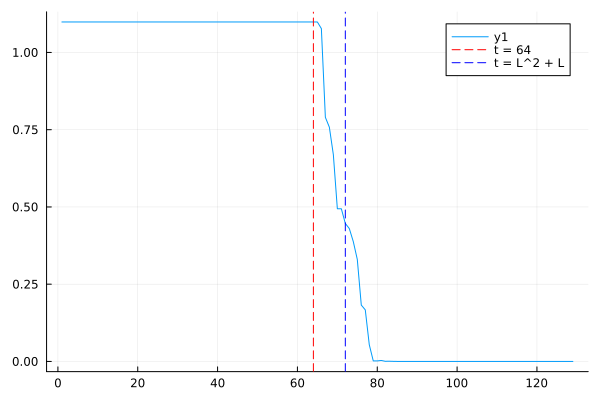

In [34]:
plot(data)
# plot a vertical line at x = 64
vline!([64], linestyle = :dash, color=:red, label="t = 64")
# plot a vertical line at x = L^2 + L
vline!([64 + 8], linestyle = :dash, color=:blue, label="t = L^2 + L")

In [40]:
using NPZ
using Statistics
using Plots
using Printf

# ==========================================
# CONFIGURATION
# ==========================================
data_dir = "/Users/dirac/Projects-Data/z3-data/z3-haar-anc-data-mipt-Apr9" 
output_dir = @__DIR__  # Saves to the directory where this script is running

L_values = [8, 10, 12, 14]
num_shots = 5000
p_values = range(0.5, stop=1.0, length=31) 

# ==========================================
# ANALYSIS & TIME EVOLUTION PLOTTING
# ==========================================

for L in L_values
    println("\nProcessing System Size L = $L ...")
    
    T = Float64(L^2)  
    dt = 1.0
    expected_length = Int(2 * T / dt) + 1 
    time_axis = 0:dt:(2*T)

    plt_time_ev = plot(
        title = "Ancilla Entropy Evolution (L = $L)",
        xlabel = "Time t",
        ylabel = "Ancilla Entropy S(t)",
        legend = :outerright,
        grid = true
    )
    
    for p in p_values
        # Raw string conversion for full Float64 precision (~17-18 decimals)
        p_str = string(p)
        
        # Matrix to store all shots for this p: [time_step, shot_index]
        trajs_matrix = fill(NaN, expected_length, num_shots)
        count_valid = 0
        
        for s in 1:num_shots
            fname = "L$(L),T$(T),p$(p_str),s$(s)_a.npy"
            fpath = joinpath(data_dir, fname)
            
            if isfile(fpath)
                try
                    traj = npzread(fpath)
                    len = min(length(traj), expected_length)
                    trajs_matrix[1:len, s] = traj[1:len]
                    count_valid += 1
                catch
                    # Silently skip corrupted/unreadable files
                end
            end
        end
        
        if count_valid > 1
            # Calculate Mean and SEM across shots
            avg_traj = Float64[]
            sem_traj = Float64[]
            
            for t_idx in 1:expected_length
                row = filter(!isnan, trajs_matrix[t_idx, :])
                if !isempty(row)
                    push!(avg_traj, mean(row))
                    push!(sem_traj, std(row) / sqrt(length(row)))
                end
            end
            
            # Clean label for the legend so it isn't massive
            legend_label = @sprintf("p = %.3f", p)
            
            # Plot with shaded ribbon for the standard error
            plot!(plt_time_ev, time_axis[1:length(avg_traj)], avg_traj, 
                  ribbon = sem_traj,
                  fillalpha = 0.3,
                  label = legend_label,
                  lw = 1.5)
            print(".") 
        else
             println("\n  [Warning] Insufficient data for p = $p_str")
        end
    end
    
    output_name = joinpath(output_dir, "Ancilla_Evolution_L$(L)_T$(T)_with_ErrorBars.pdf")
    savefig(plt_time_ev, output_name)
    println("\nSaved: $output_name")
end


Processing System Size L = 8 ...
...............................
Saved: /Users/dirac/Documents/z3-potts/src/Ancilla_Evolution_L8_T64.0_with_ErrorBars.pdf

Processing System Size L = 10 ...
...............................
Saved: /Users/dirac/Documents/z3-potts/src/Ancilla_Evolution_L10_T100.0_with_ErrorBars.pdf

Processing System Size L = 12 ...
...............................
Saved: /Users/dirac/Documents/z3-potts/src/Ancilla_Evolution_L12_T144.0_with_ErrorBars.pdf

Processing System Size L = 14 ...
...............................
Saved: /Users/dirac/Documents/z3-potts/src/Ancilla_Evolution_L14_T196.0_with_ErrorBars.pdf


In [54]:
using NPZ
using Statistics
using Plots
using Printf

# ==========================================
# CONFIGURATION
# ==========================================
data_dir = "/Users/dirac/Projects-Data/z3-data/z3-haar-anc-data-mipt-Apr9" 
output_dir = @__DIR__

L_values = [8, 10, 12, 14]
num_shots = 5000
#p_values = [0.5, 0.6, 0.7, 0.8, 0.9, 1.0] 
p_values = range(0.5, stop=1.0, length=31)

# ==========================================
# ANALYSIS & TIME EVOLUTION PLOTTING
# ==========================================

for p in p_values
    println("\nGenerating plot for p = $p ...")
    
    # Raw string conversion for full Float64 precision
    p_str = string(p)
    
    plt_scaled = plot(
        title = "Scaled Log Entropy Evolution (p = $(@sprintf("%.6f", p)))",
        xlabel = "Scaled Time: t/L",
        ylabel = "log(S_A)",
        legend = :bottomright,
        ylims = (-10, 0),
        grid = true,
    )
    
    for L in L_values
        print("  Processing L = $L... ")
        
        T = Float64(L^2)  
        dt = 1.0
        expected_length = Int(2 * T / dt) + 1 
        
        # Matrix to store all shots for this p: [time_step, shot_index]
        trajs_matrix = fill(NaN, expected_length, num_shots)
        count_valid = 0
        
        for s in 1:num_shots
            fname = "L$(L),T$(T),p$(p_str),s$(s)_a.npy"
            fpath = joinpath(data_dir, fname)
            
            if isfile(fpath)
                try
                    traj = npzread(fpath)
                    len = min(length(traj), expected_length)
                    trajs_matrix[1:len, s] = traj[1:len]
                    count_valid += 1
                catch
                    # Silently skip corrupted/unreadable files
                end
            end
        end
        
        if count_valid > 1
            # Calculate Mean and SEM across shots
            avg_traj = Float64[]
            sem_traj = Float64[]
            
            for t_idx in 1:expected_length
                row = filter(!isnan, trajs_matrix[t_idx, :])
                if !isempty(row)
                    push!(avg_traj, mean(row))
                    push!(sem_traj, std(row) / sqrt(length(row)))
                end
            end
            
            # --- TIME ISOLATION & RESCALING LOGIC ---
            # t=0 corresponds to index 1.
            start_idx = Int(L^2) + 1
            end_idx = Int(L^2 + L) + 1
            
            if length(avg_traj) >= end_idx
                # Slice the data
                sliced_avg = avg_traj[start_idx:end_idx]
                sliced_sem = sem_traj[start_idx:end_idx]
                
                # Apply natural log. We use max(..., 1e-12) to avoid DomainError if entropy hits exactly 0.
                log_avg = log.(max.(sliced_avg, 1e-12))
                
                # Error propagation for log space: Δ(log(S)) ≈ ΔS / S
                log_sem = sliced_sem ./ max.(sliced_avg, 1e-12)
                
                # Create rescaled x-axis from 0 to 1
                scaled_time = (0:L) ./ Float64(L)
                
                # Plot for this L
                plot!(plt_scaled, scaled_time, log_avg, 
                      ribbon = log_sem,
                      fillalpha = 0.2,
                      label = "L = $L",
                      lw = 1.5)
                println("Done. Valid shots: $count_valid")
            else
                println("Skipped (trajectory shorter than required time window L² to L²+L).")
            end
        else
            println("Skipped (insufficient data).")
        end
    end
    
    output_name = joinpath(output_dir, "Scaled_LogEntropy_p$(@sprintf("%.6f", p)).pdf")
    savefig(plt_scaled, output_name)
    println("Saved: $output_name")
end


Generating plot for p = 0.5 ...
  Processing L = 8... Done. Valid shots: 5000
  Processing L = 10... Done. Valid shots: 5000
  Processing L = 12... Done. Valid shots: 5000
  Processing L = 14... Done. Valid shots: 2500
Saved: /Users/dirac/Documents/z3-potts/src/Scaled_LogEntropy_p0.500000.pdf

Generating plot for p = 0.5166666666666667 ...
  Processing L = 8... Done. Valid shots: 5000
  Processing L = 10... Done. Valid shots: 5000
  Processing L = 12... Done. Valid shots: 5000
  Processing L = 14... Done. Valid shots: 2500
Saved: /Users/dirac/Documents/z3-potts/src/Scaled_LogEntropy_p0.516667.pdf

Generating plot for p = 0.5333333333333333 ...
  Processing L = 8... Done. Valid shots: 5000
  Processing L = 10... Done. Valid shots: 5000
  Processing L = 12... Done. Valid shots: 5000
  Processing L = 14... Done. Valid shots: 2500
Saved: /Users/dirac/Documents/z3-potts/src/Scaled_LogEntropy_p0.533333.pdf

Generating plot for p = 0.55 ...
  Processing L = 8... Done. Valid shots: 5000
  Pro

In [56]:
using NPZ
using Statistics
using Plots
using Printf

# ==========================================
# CONFIGURATION
# ==========================================
data_dir = "/Users/dirac/Projects-Data/z3-data/z3-haar-anc-data-mipt-Apr9" 
output_dir = @__DIR__

L_values = [8, 10, 12, 14]
num_shots = 5000
p_values = range(0.5, stop=1.0, length=31)

# ==========================================
# ANALYSIS & TIME EVOLUTION PLOTTING
# ==========================================

for p in p_values
    println("\nGenerating plot for p = $p ...")
    
    # Raw string conversion for full Float64 precision
    p_str = string(p)
    
    plt_scaled = plot(
        title = "Scaled Log Entropy Evolution (p = $(@sprintf("%.6f", p)))",
        xlabel = "Scaled Time: t/L²",
        ylabel = "log(S_A)",
        legend = :bottomright,
        #ylims = (-10, 0),
        grid = true,
    )
    
    for L in L_values
        print("  Processing L = $L... ")
        
        T = Float64(L^2)  
        dt = 1.0
        expected_length = Int(2 * T / dt) + 1 
        
        # Matrix to store all shots for this p: [time_step, shot_index]
        trajs_matrix = fill(NaN, expected_length, num_shots)
        count_valid = 0
        
        for s in 1:num_shots
            fname = "L$(L),T$(T),p$(p_str),s$(s)_a.npy"
            fpath = joinpath(data_dir, fname)
            
            if isfile(fpath)
                try
                    traj = npzread(fpath)
                    len = min(length(traj), expected_length)
                    trajs_matrix[1:len, s] = traj[1:len]
                    count_valid += 1
                catch
                    # Silently skip corrupted/unreadable files
                end
            end
        end
        
        if count_valid > 1
            # Calculate Mean and SEM across shots
            avg_traj = Float64[]
            sem_traj = Float64[]
            
            for t_idx in 1:expected_length
                row = filter(!isnan, trajs_matrix[t_idx, :])
                if !isempty(row)
                    push!(avg_traj, mean(row))
                    push!(sem_traj, std(row) / sqrt(length(row)))
                end
            end
            
            # --- TIME ISOLATION & RESCALING LOGIC ---
            # t=0 corresponds to index 1.
            start_idx = Int(L^2) + 1
            end_idx = Int(2 * L^2) + 1
            
            if length(avg_traj) >= end_idx
                # Slice the data
                sliced_avg = avg_traj[start_idx:end_idx]
                sliced_sem = sem_traj[start_idx:end_idx]
                
                # Apply natural log. We use max(..., 1e-12) to avoid DomainError if entropy hits exactly 0.
                log_avg = log.(max.(sliced_avg, 1e-12))
                
                # Error propagation for log space: Δ(log(S)) ≈ ΔS / S
                log_sem = sliced_sem ./ max.(sliced_avg, 1e-12)
                
                # Create rescaled x-axis from 0 to 1 using L^2
                scaled_time = (0:L^2) ./ Float64(L^2)
                
                # Plot for this L
                plot!(plt_scaled, scaled_time, log_avg, 
                      ribbon = log_sem,
                      fillalpha = 0.2,
                      label = "L = $L",
                      lw = 1.5)
                println("Done. Valid shots: $count_valid")
            else
                println("Skipped (trajectory shorter than required time window L² to 2L²).")
            end
        else
            println("Skipped (insufficient data).")
        end
    end
    
    output_name = joinpath(output_dir, "Scaled_LogEntropy_L2_p$(@sprintf("%.6f", p)).pdf")
    savefig(plt_scaled, output_name)
    println("Saved: $output_name")
end


Generating plot for p = 0.5 ...
  Processing L = 8... Done. Valid shots: 5000
  Processing L = 10... Done. Valid shots: 5000
  Processing L = 12... Done. Valid shots: 5000
  Processing L = 14... Done. Valid shots: 2500
Saved: /Users/dirac/Documents/z3-potts/src/Scaled_LogEntropy_L2_p0.500000.pdf

Generating plot for p = 0.5166666666666667 ...
  Processing L = 8... Done. Valid shots: 5000
  Processing L = 10... Done. Valid shots: 5000
  Processing L = 12... Done. Valid shots: 5000
  Processing L = 14... Done. Valid shots: 2500
Saved: /Users/dirac/Documents/z3-potts/src/Scaled_LogEntropy_L2_p0.516667.pdf

Generating plot for p = 0.5333333333333333 ...
  Processing L = 8... Done. Valid shots: 5000
  Processing L = 10... Done. Valid shots: 5000
  Processing L = 12... Done. Valid shots: 5000
  Processing L = 14... Done. Valid shots: 2500
Saved: /Users/dirac/Documents/z3-potts/src/Scaled_LogEntropy_L2_p0.533333.pdf

Generating plot for p = 0.55 ...
  Processing L = 8... Done. Valid shots: 5

## Redoing Charge-Shapening with ancilla


Processing System Size L = 8 ...
  Found 31 unique p-values.
............................... Done.

Processing System Size L = 10 ...
  Found 31 unique p-values.
............................... Done.

Processing System Size L = 12 ...
  Found 31 unique p-values.
............................... Done.

Generating Summary Plot (Ancilla Entropy at t = L^2 + L vs p)...


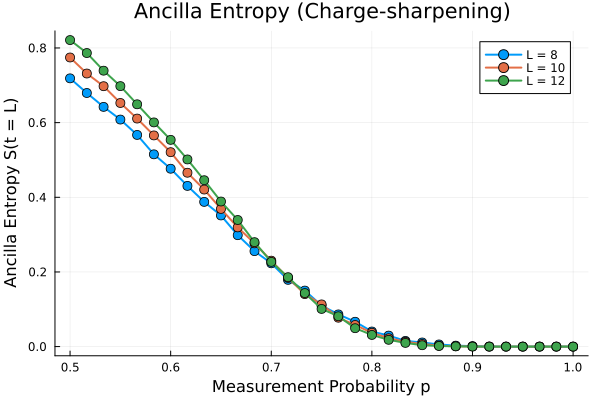

Plot saved as AncillaEntropy_steady_state_Summary.pdf


In [27]:
using NPZ
using Statistics
using Plots
using Printf

# ==========================================
# CONFIGURATION
# ==========================================
# Update this to the folder where your Shannon Entropy data is stored
data_dir = "/Users/dirac/Projects-Data/z3-data/z3-haar-anc-cs-data-Apr21" 

L_values = [8, 10, 12]
num_shots = 5000

# Storage for the summary: Dict(L => (clean_p_vals, se_at_target_vals))
summary_data = Dict{Int, Tuple{Vector{Float64}, Vector{Float64}}}()

# ==========================================
# ANALYSIS LOOP
# ==========================================

for L in L_values
    println("\nProcessing System Size L = $L ...")
    
    # Set T to the new steady state target time L^2
    T = 1.0 * L^2
    dt = 1.0
    
    # Expected length assuming data records t = 0, 1, ..., T
    expected_length = 2 * Int(T / dt) + 1 
    
    # Extract the value at time t = L^2 + L (index is t + 1 if array starts at t=0)
    target_index = L^2 + L + 1
    
    # --- DYNAMICALLY FIND ALL 'p' VALUES FOR THIS 'L' ---
    p_str_set = Set{String}()
    T_str = string(T)
    
    # Regex to match: L<val>,T<val>,p<CAPTURE_P>,s<val>_a.npy
    file_regex = Regex("^L$(L),T$(T_str),p([0-9.]+),s\\d+_a\\.npy\$")
    
    if isdir(data_dir)
        for fname in readdir(data_dir)
            m = match(file_regex, fname)
            if m !== nothing
                # m.captures[1] is the exact string of the p-value
                push!(p_str_set, m.captures[1])
            end
        end
    else
        println("Directory not found: $data_dir")
        continue
    end
    
    if isempty(p_str_set)
        println("  Warning: No data files found for L=$L, T=$T_str")
        continue
    end
    
    # Convert strings to floats so we can sort them numerically for a clean plot
    # Store as tuples: (numeric_value, string_value)
    p_pairs = [(parse(Float64, p_str), p_str) for p_str in p_str_set]
    sort!(p_pairs, by = x -> x[1])
    
    println("  Found $(length(p_pairs)) unique p-values.")
    
    # Storage for this specific L
    se_at_target = Float64[]
    clean_p_vals_for_L = Float64[]
    
    for (p_num, p_str) in p_pairs
        
        # Accumulator for averaging
        accumulated_se = zeros(Float64, expected_length)
        count_valid = 0
        
        # --- Load 5000 Shots ---
        for s in 1:num_shots
            # Reconstruct the filename using the exact string we parsed
            fname = "L$(L),T$(T_str),p$(p_str),s$(s)_a.npy"
            fpath = joinpath(data_dir, fname)
            
            if isfile(fpath)
                try
                    traj = npzread(fpath)
                    
                    # Handle slight length mismatches
                    len = min(length(traj), length(accumulated_se))
                    accumulated_se[1:len] .+= traj[1:len]
                    count_valid += 1
                catch e
                    # Skip corrupted files
                end
            end
        end
        
        if count_valid > 0
            avg_traj = accumulated_se ./ count_valid
            
            # --- EXTRACT VALUE AT t = L^2 + L ---
            if length(avg_traj) >= target_index
                val_at_target = avg_traj[target_index]
                push!(se_at_target, val_at_target)
                push!(clean_p_vals_for_L, p_num)
            else
                println("\n  Error: Trajectory too short to find t=$(L^2 + L) for p=$p_str")
            end
            
            print(".") 
        else
            println("\n  Warning: No valid data loaded for L=$L, p=$p_str")
        end
    end
    
    println(" Done.")
    
    # Store data for the summary plot
    summary_data[L] = (clean_p_vals_for_L, se_at_target)
end

# ==========================================
# SUMMARY PLOT (Shannon Entropy(t=L^2+L) vs p)
# ==========================================

println("\nGenerating Summary Plot (Ancilla Entropy at t = L^2 + L vs p)...")

plt_summary = plot(
    title = "Ancilla Entropy (Charge-sharpening)",
    xlabel = "Measurement Probability p",
    ylabel = "Ancilla Entropy S(t = L)",
    legend = :topright,
    grid = true
)

# Sort L values so the legend is clean
for L in sort(collect(keys(summary_data)))
    (p_vals, se_vals) = summary_data[L]
    
    plot!(plt_summary, p_vals, se_vals, 
        label = "L = $L", 
        marker = :circle, 
        markersize = 5,
        lw = 2
    )
end

display(plt_summary)
savefig(plt_summary, "AncillaEntropy_steady_state_Summary.pdf")
println("Plot saved as AncillaEntropy_steady_state_Summary.pdf")


Processing System Size L = 8 ...
  Found 13 unique p-values between 0.6 and 0.8.
............. Done.

Processing System Size L = 10 ...
  Found 13 unique p-values between 0.6 and 0.8.
............. Done.

Processing System Size L = 12 ...
  Found 13 unique p-values between 0.6 and 0.8.
............. Done.

Generating Summary Plot (Ancilla Entropy at t = L^2 + L vs p)...


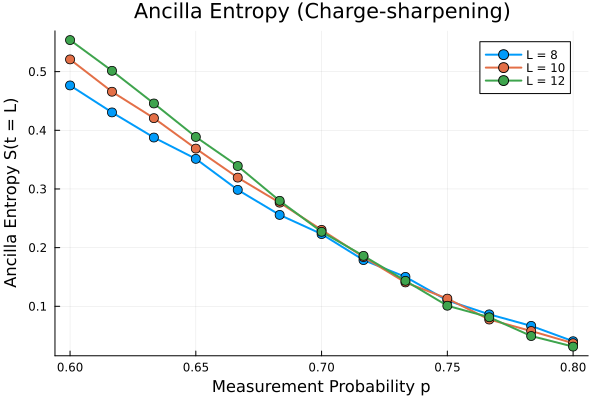

Plot saved as AncillaEntropy_steady_state_Summary.pdf


In [29]:
using NPZ
using Statistics
using Plots
using Printf

# ==========================================
# CONFIGURATION
# ==========================================
# Update this to the folder where your Shannon Entropy data is stored
data_dir = "/Users/dirac/Projects-Data/z3-data/z3-haar-anc-cs-data-Apr21" 

L_values = [8, 10, 12]
num_shots = 5000

# Specify the range of p-values you want to plot
p_min = 0.6
p_max = 0.8

# Storage for the summary: Dict(L => (clean_p_vals, se_at_target_vals))
summary_data = Dict{Int, Tuple{Vector{Float64}, Vector{Float64}}}()

# ==========================================
# ANALYSIS LOOP
# ==========================================

for L in L_values
    println("\nProcessing System Size L = $L ...")
    
    # Set T to the new steady state target time L^2
    T = 1.0 * L^2
    dt = 1.0
    
    # Expected length assuming data records t = 0, 1, ..., T
    expected_length = 2 * Int(T / dt) + 1 
    
    # Extract the value at time t = L^2 + L (index is t + 1 if array starts at t=0)
    target_index = L^2 + L + 1
    
    # --- DYNAMICALLY FIND ALL 'p' VALUES FOR THIS 'L' ---
    p_str_set = Set{String}()
    T_str = string(T)
    
    # Regex to match: L<val>,T<val>,p<CAPTURE_P>,s<val>_a.npy
    file_regex = Regex("^L$(L),T$(T_str),p([0-9.]+),s\\d+_a\\.npy\$")
    
    if isdir(data_dir)
        for fname in readdir(data_dir)
            m = match(file_regex, fname)
            if m !== nothing
                # m.captures[1] is the exact string of the p-value
                push!(p_str_set, m.captures[1])
            end
        end
    else
        println("Directory not found: $data_dir")
        continue
    end
    
    if isempty(p_str_set)
        println("  Warning: No data files found for L=$L, T=$T_str")
        continue
    end
    
    # Convert strings to floats so we can sort and filter them
    # Store as tuples: (numeric_value, string_value)
    p_pairs = [(parse(Float64, p_str), p_str) for p_str in p_str_set]
    
    # --- FILTER: Keep only values within the specified [p_min, p_max] bounds ---
    filter!(x -> p_min <= x[1] <= p_max, p_pairs)
    
    # Sort them numerically for a clean plot line
    sort!(p_pairs, by = x -> x[1])
    
    println("  Found $(length(p_pairs)) unique p-values between $p_min and $p_max.")
    
    # Storage for this specific L
    se_at_target = Float64[]
    clean_p_vals_for_L = Float64[]
    
    for (p_num, p_str) in p_pairs
        
        # Accumulator for averaging
        accumulated_se = zeros(Float64, expected_length)
        count_valid = 0
        
        # --- Load 5000 Shots ---
        for s in 1:num_shots
            # Reconstruct the filename using the exact string we parsed
            fname = "L$(L),T$(T_str),p$(p_str),s$(s)_a.npy"
            fpath = joinpath(data_dir, fname)
            
            if isfile(fpath)
                try
                    traj = npzread(fpath)
                    
                    # Handle slight length mismatches
                    len = min(length(traj), length(accumulated_se))
                    accumulated_se[1:len] .+= traj[1:len]
                    count_valid += 1
                catch e
                    # Skip corrupted files
                end
            end
        end
        
        if count_valid > 0
            avg_traj = accumulated_se ./ count_valid
            
            # --- EXTRACT VALUE AT t = L^2 + L ---
            if length(avg_traj) >= target_index
                val_at_target = avg_traj[target_index]
                push!(se_at_target, val_at_target)
                push!(clean_p_vals_for_L, p_num)
            else
                println("\n  Error: Trajectory too short to find t=$(L^2 + L) for p=$p_str")
            end
            
            print(".") 
        else
            println("\n  Warning: No valid data loaded for L=$L, p=$p_str")
        end
    end
    
    println(" Done.")
    
    # Store data for the summary plot
    summary_data[L] = (clean_p_vals_for_L, se_at_target)
end

# ==========================================
# SUMMARY PLOT (Shannon Entropy(t=L^2+L) vs p)
# ==========================================

println("\nGenerating Summary Plot (Ancilla Entropy at t = L^2 + L vs p)...")

plt_summary = plot(
    title = "Ancilla Entropy (Charge-sharpening)",
    xlabel = "Measurement Probability p",
    ylabel = "Ancilla Entropy S(t = L)",
    legend = :topright,
    grid = true
)

# Sort L values so the legend is clean
for L in sort(collect(keys(summary_data)))
    (p_vals, se_vals) = summary_data[L]
    
    plot!(plt_summary, p_vals, se_vals, 
        label = "L = $L", 
        marker = :circle, 
        markersize = 5,
        lw = 2
    )
end

display(plt_summary)
savefig(plt_summary, "AncillaEntropy_steady_state_Summary.pdf")
println("Plot saved as AncillaEntropy_steady_state_Summary.pdf")


Processing System Size L = 8 ...
  Found 13 unique p-values between 0.6 and 0.8.
............. Done.

Processing System Size L = 10 ...
  Found 13 unique p-values between 0.6 and 0.8.
............. Done.

Processing System Size L = 12 ...
  Found 13 unique p-values between 0.6 and 0.8.
............. Done.

Processing System Size L = 16 ...

Generating Summary Plot (Ancilla Entropy at t = L^2 + L vs p)...


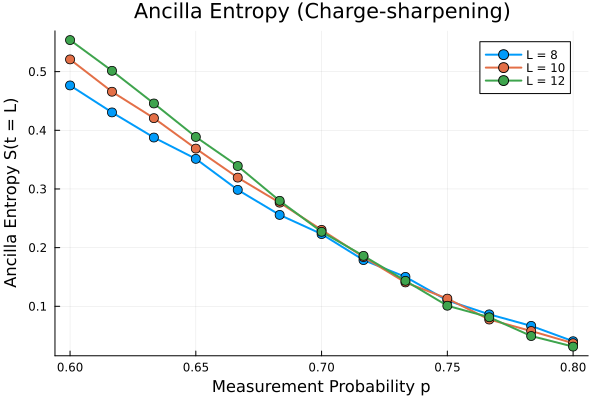

Plot saved as AncillaEntropy_steady_state_Summary.pdf

# ==========================================
# NumPy Formatted Output
# ==========================================

I = np.array([
  [0.47644331, 0.43046253, 0.38763747, 0.35129163, 0.29845067, 0.25574550, 0.22312163, 0.17880340, 0.15008058, 0.10986318, 0.08624477, 0.06655843, 0.04042085],
  [0.52081916, 0.46570083, 0.42069285, 0.36877776, 0.31931660, 0.27661029, 0.23020334, 0.18396175, 0.14066684, 0.11303855, 0.07738990, 0.05780026, 0.03703268],
  [0.55377521, 0.50135404, 0.44569625, 0.38862972, 0.33913063, 0.27975547, 0.22693189, 0.18594732, 0.14341064, 0.10094625, 0.08126728, 0.04929892, 0.03127363]
])

L_vals = np.array([8, 10, 12])

p_vals = np.array([0.6000, 0.6167, 0.6333, 0.6500, 0.6667, 0.6833, 0.7000, 0.7167, 0.7333, 0.7500, 0.7667, 0.7833, 0.8000])



In [30]:
using NPZ
using Statistics
using Plots
using Printf

# ==========================================
# CONFIGURATION
# ==========================================
# Update this to the folder where your Shannon Entropy data is stored
data_dir = "/Users/dirac/Projects-Data/z3-data/z3-haar-anc-cs-data-Apr21" 

L_values = [8, 10, 12, 16] # Ensure 16 is here if you want it in the output!
num_shots = 5000

# Specify the range of p-values you want to plot/print
p_min = 0.6
p_max = 0.8

# Storage for the summary: Dict(L => (clean_p_vals, se_at_target_vals))
summary_data = Dict{Int, Tuple{Vector{Float64}, Vector{Float64}}}()

# ==========================================
# ANALYSIS LOOP
# ==========================================

for L in L_values
    println("\nProcessing System Size L = $L ...")
    
    # Set T to the new steady state target time L^2
    T = 1.0 * L^2
    dt = 1.0
    
    # Expected length assuming data records t = 0, 1, ..., T
    expected_length = 2 * Int(T / dt) + 1 
    
    # Extract the value at time t = L^2 + L (index is t + 1 if array starts at t=0)
    target_index = L^2 + L + 1
    
    # --- DYNAMICALLY FIND ALL 'p' VALUES FOR THIS 'L' ---
    p_str_set = Set{String}()
    T_str = string(T)
    
    # Regex to match: L<val>,T<val>,p<CAPTURE_P>,s<val>_a.npy
    file_regex = Regex("^L$(L),T$(T_str),p([0-9.]+),s\\d+_a\\.npy\$")
    
    if isdir(data_dir)
        for fname in readdir(data_dir)
            m = match(file_regex, fname)
            if m !== nothing
                # m.captures[1] is the exact string of the p-value
                push!(p_str_set, m.captures[1])
            end
        end
    else
        println("Directory not found: $data_dir")
        continue
    end
    
    if isempty(p_str_set)
        println("  Warning: No data files found for L=$L, T=$T_str")
        continue
    end
    
    # Convert strings to floats so we can sort and filter them
    # Store as tuples: (numeric_value, string_value)
    p_pairs = [(parse(Float64, p_str), p_str) for p_str in p_str_set]
    
    # --- FILTER: Keep only values within the specified [p_min, p_max] bounds ---
    filter!(x -> p_min <= x[1] <= p_max, p_pairs)
    
    # Sort them numerically for a clean plot line
    sort!(p_pairs, by = x -> x[1])
    
    println("  Found $(length(p_pairs)) unique p-values between $p_min and $p_max.")
    
    # Storage for this specific L
    se_at_target = Float64[]
    clean_p_vals_for_L = Float64[]
    
    for (p_num, p_str) in p_pairs
        
        # Accumulator for averaging
        accumulated_se = zeros(Float64, expected_length)
        count_valid = 0
        
        # --- Load 5000 Shots ---
        for s in 1:num_shots
            # Reconstruct the filename using the exact string we parsed
            fname = "L$(L),T$(T_str),p$(p_str),s$(s)_a.npy"
            fpath = joinpath(data_dir, fname)
            
            if isfile(fpath)
                try
                    traj = npzread(fpath)
                    
                    # Handle slight length mismatches
                    len = min(length(traj), length(accumulated_se))
                    accumulated_se[1:len] .+= traj[1:len]
                    count_valid += 1
                catch e
                    # Skip corrupted files
                end
            end
        end
        
        if count_valid > 0
            avg_traj = accumulated_se ./ count_valid
            
            # --- EXTRACT VALUE AT t = L^2 + L ---
            if length(avg_traj) >= target_index
                val_at_target = avg_traj[target_index]
                push!(se_at_target, val_at_target)
                push!(clean_p_vals_for_L, p_num)
            else
                println("\n  Error: Trajectory too short to find t=$(L^2 + L) for p=$p_str")
            end
            
            print(".") 
        else
            println("\n  Warning: No valid data loaded for L=$L, p=$p_str")
        end
    end
    
    println(" Done.")
    
    # Store data for the summary plot
    summary_data[L] = (clean_p_vals_for_L, se_at_target)
end

# ==========================================
# SUMMARY PLOT (Shannon Entropy(t=L^2+L) vs p)
# ==========================================

println("\nGenerating Summary Plot (Ancilla Entropy at t = L^2 + L vs p)...")

plt_summary = plot(
    title = "Ancilla Entropy (Charge-sharpening)",
    xlabel = "Measurement Probability p",
    ylabel = "Ancilla Entropy S(t = L)",
    legend = :topright,
    grid = true
)

sorted_Ls = sort(collect(keys(summary_data)))

# Sort L values so the legend is clean
for L in sorted_Ls
    (p_vals, se_vals) = summary_data[L]
    
    plot!(plt_summary, p_vals, se_vals, 
        label = "L = $L", 
        marker = :circle, 
        markersize = 5,
        lw = 2
    )
end

display(plt_summary)
savefig(plt_summary, "AncillaEntropy_steady_state_Summary.pdf")
println("Plot saved as AncillaEntropy_steady_state_Summary.pdf")

# ==========================================
# CONSOLE OUTPUT (NUMPY FORMAT)
# ==========================================

println("\n# ==========================================")
println("# NumPy Formatted Output")
println("# ==========================================\n")

# Make sure we have data to print
if !isempty(sorted_Ls)
    println("I = np.array([")
    for (i, L) in enumerate(sorted_Ls)
        _, se_vals = summary_data[L]
        
        # Format the entropy values to 8 decimal places
        se_str = join([@sprintf("%.8f", val) for val in se_vals], ", ")
        
        # Add comma at the end of the row unless it's the last one
        if i < length(sorted_Ls)
            println("  [$se_str],")
        else
            println("  [$se_str]")
        end
    end
    println("])\n")

    # Format L_vals
    L_str = join(sorted_Ls, ", ")
    println("L_vals = np.array([$L_str])\n")

    # Format p_vals (using the p_vals from the first L as reference)
    ref_p_vals, _ = summary_data[sorted_Ls[1]]
    p_str = join([@sprintf("%.4f", p) for p in ref_p_vals], ", ")
    println("p_vals = np.array([$p_str])\n")
end